# Arquitectura agéntica para el tutor de matemáticas

### Sesión 10 · Módulo 3 — RAG + ReAct + Tool use, medido con el harness (3/4)

**Proyecto:** Tutor inteligente de matemáticas · Comparación de arquitecturas
mediante fine-tuning
**Curso:** SI4006 · Tópicos Especiales y Aplicaciones en IA · Universidad EAFIT
**Notebook base:** `S04_Lab_Fine_tuning_Qwen.ipynb`

---

## 1 · Introducción

### La pregunta del experimento

> **¿Una arquitectura agéntica basada en RAG + ReAct + herramientas mejora de verdad
> al tutor frente al sistema actual?**

No se trata de añadir complejidad. La regla de S10 es explícita: *empiecen con el
RAG de una pasada y agreguen un agente solo si el harness mejora de verdad*.

### La escalera: una sola cosa nueva en cada paso

| Config. | Añade | Qué pone a prueba |
|---|---|---|
| **C0** | Qwen2.5-1.5B base | Referencia (baseline de M2) |
| **C1** | + LoRA de M1 | El sistema actual sin RAG |
| **C2** | + RAG de S08 (contexto siempre) | El mejor RAG de una pasada |
| **C3** | + herramientas de cálculo, **una ronda** de tool calling | ¿Delegar las cuentas mejora? |
| **C4** | + **ReAct**: pensamiento → acción → observación, en varios pasos | ¿Encadenar pasos mejora? |
| **C5** | + retrieval **como herramienta**, planificación, verificador, normalizador | ¿La arquitectura agéntica completa mejora? |
| **C5-FT** | C5 con el adaptador entrenado (notebook 2) | ¿Entrenar supera al few-shot? |

### Predicciones escritas antes de ejecutar

| Bloque | Predicción | Razonamiento |
|---|---|---|
| M2 · cálculo | C3–C5 ≈ C1 (10/12) | Los dos fallos de C1 son de **planteamiento**; una calculadora no los arregla |
| M2 · conocimiento | C2 ≈ C5 > C1 | Solo mejora si hay documentos, fijos o buscados |
| M3 · aritmética | **C3–C5 ≫ C1** | Aquí sí hay cuentas donde un 1.5B se equivoca |
| M3 · compuesto | **C5 > C2–C4** | Hace falta buscar **y** calcular |
| M3 · mal escrito | C5 ≥ resto | Es la única configuración con normalizador |
| Coste | C5 ≈ 10× los tokens de entrada de C2 | Cada paso reenvía ~2.700 tokens de esquemas + few-shot (medido en local: ~7.500 vs ~550) |

Si C5 no supera a C2 en lo que importa, la conclusión correcta es que **el agente no
se justifica** para este tutor, y se reportará así.

## 2 · Objetivos

1. Integrar el núcleo agéntico (probado en `scripts/agente/`) con el RAG de S08 y el
   generador de M1.
2. **Decidir con datos** qué adaptador usan las configuraciones con herramientas.
3. Pasar **siete configuraciones** por el mismo harness sobre 53 casos (M2 + M3),
   guardando la traza completa.
4. Reportar exactitud, uso y selección de herramientas, pasos, errores, calidad de la
   explicación, robustez, consistencia y coste.
5. Dejar `respuestas_s10.jsonl` listo para RAGAS (notebook 4).

## 0 · Preparación del entorno

> **Activen la GPU (T4).** Se cargan el generador (con uno o dos adaptadores), el
> juez, el modelo de embeddings y el cross-encoder. La corrida completa es larga y
> **se puede retomar**: cada respuesta se guarda al generarse (sección 11).

In [1]:
%pip install -q "transformers>=4.44" "peft>=0.12" "accelerate>=0.33" \
    sentence-transformers chromadb rank_bm25 "scikit-learn>=1.3" sympy pandas
%pip uninstall -y -q torchao
print("Librerías instaladas. Si Colab pide reiniciar la sesión, reinícienla y sigan desde aquí.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not current

In [2]:
import os, random, re, time
import numpy as np
import torch
import transformers

SEMILLA = 42
random.seed(SEMILLA); np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
transformers.set_seed(SEMILLA)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"transformers {transformers.__version__} | torch {torch.__version__} | {DEVICE}")

transformers 5.16.1 | torch 2.11.0+cu128 | cuda


### Persistencia entre notebooks

Los notebooks 3 y 5 **leen carpetas que producen los notebooks 1, 2 y 4**:

```
1 · Qwen    -> adaptadores/qwen-lora/      ─┐
2 · BERT    -> modelos/bert-clasificador/  ─┤-> el notebook 3 las lee
4 · FLAN-T5 -> adaptadores/flan-t5-lora/    │
1,2,3,4     -> resultados/*.json           ─┴-> el notebook 5 los lee
```

En Colab, `/content` se borra al desconectar el runtime, así que ese trabajo se
perdería entre sesiones. Montando Google Drive y trabajando desde una carpeta
suya, los artefactos sobreviven y cada notebook se puede ejecutar el día que se
pueda.

Con `USAR_DRIVE = False` todo queda en `/content`, lo cual es válido si
ejecutan los notebooks 1, 2 y 3 seguidos sin desconectar.

Fuera de Colab la celda no hace nada: el directorio de trabajo se queda como
está.

> **Los checkpoints intermedios nunca van a Drive.** El `Trainer` guarda en
> `output_dir` el modelo *más el estado del optimizador* en cada época. Para el
> notebook 2, que hace fine-tuning completo de BETO, eso son varios GB que
> además se escribirían por red. Como son desechables —lo que importa es el
> modelo final—, se mandan siempre al disco local del runtime mediante
> `DIR_CHECKPOINTS`.

In [3]:
import os
from pathlib import Path

USAR_DRIVE    = True
CARPETA_DRIVE = "/content/drive/MyDrive/ProyectoIA"

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB and USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    Path(CARPETA_DRIVE).mkdir(parents=True, exist_ok=True)
    os.chdir(CARPETA_DRIVE)

# Checkpoints del Trainer: grandes y desechables -> siempre en disco local.
DIR_CHECKPOINTS = "/content/salidas" if EN_COLAB else "salidas"

print(f"En Colab           : {EN_COLAB}")
print(f"Directorio de trabajo: {Path.cwd()}")
print(f"Checkpoints en     : {DIR_CHECKPOINTS}")

Mounted at /content/drive
En Colab           : True
Directorio de trabajo: /content/drive/MyDrive/ProyectoIA
Checkpoints en     : /content/salidas


---
## 3 · Los eval sets

## 3.1 · El eval set

El eval set **no es el corpus de entrenamiento**. Es un conjunto nuevo, escrito
a mano, que cumple los cuatro criterios de S05:

| Criterio | Cómo se cumple aquí |
|---|---|
| **Representativo** | Problemas que un estudiante real plantearía, con enunciados en lenguaje natural. |
| **Con salida esperada** | Cada caso trae la respuesta correcta y un `criterio` explícito de qué la hace correcta. |
| **Cubre casos difíciles** | Es el eje del diseño: multipaso, distractores, porcentajes encadenados, proporcionalidad inversa, redondeo contextual. |
| **No contaminado** | Ningún caso proviene de `math_tutor_dataset.jsonl`. El generador lo verifica automáticamente y falla si hay solapamiento. |

**Por qué hizo falta uno nuevo.** En M1 el modelo *sin entrenar* ya resolvía el
90.91% del conjunto de validación. Un eval set con ese nivel de dificultad no
puede discriminar entre sistemas: todo se ve bien. Este está construido para
que el modelo falle, porque un eval set que no reta al sistema no informa nada.

### Los tres bloques

- **A · CÁLCULO (12 casos)** — mide **habilidad**. Cada uno tiene un modo de
  fallo documentado en su `criterio` (por ejemplo, sumar descuentos sucesivos
  en lugar de encadenarlos).
- **B · CONOCIMIENTO (4 casos)** — mide **conocimiento institucional** que
  ningún modelo puede tener en sus pesos. El baseline debería abstenerse aquí;
  si en cambio inventa una cifra con seguridad, es una alucinación y el
  scorecard la registra. **Este bloque es el que motiva el RAG de M3.**
- **C · ADVERSARIAL (5 casos)** — mide **robustez**, siguiendo el red-teaming
  de S06: premisa falsa, indefinición matemática, datos insuficientes, fuera de
  dominio y mantenimiento del rol.

Supera de largo el mínimo de M2 (≥10 gold + ≥2 adversariales): 16 gold y 5
adversariales.

In [4]:
import base64, gzip, hashlib, json
from pathlib import Path

RUTA_EVAL = Path("data/eval_set_m2.jsonl")
SHA_EVAL  = "ba9c4f3b2d80d687b4a56e1d93e260a964e0b375e61de1d27d10c41a43e1f96c"

_BLOB_EVAL = (
    "H4sIAAAAAAAC/61aTW8cyZG9L+D/kCBggIJbrf4k2b0YLLgSZRPQkBpyxoDhNYjsrmQrtdWVPVVdBOmBf8Ue9qyjDjoM5mBg"
    "Lgbcf8zvRWZ9dTU1zbGAGYidlR+RES8jXkTmDwc2Opiqg8jePu/1DzrqYBa773PDtrmO53ns2Jjls7VdObYu8xh/6szdmGSu"
    "I5PoSLrYZJWv2eG7RK11HJtUzd1ylWo1VHP9XmcqMmrt0sTGscuUVv2Tca+nVibDL0ykVZ5o9aAGKnXSA93nehYbdB2Mjsdb"
    "XV1XvdULjTUS1cdExVRd9c9/vMw3H5K1U5FNTOoUpojMXW7iO5P8F0U12cqkFBvSvsVOVH+q3ugsiDnPTbbWCcTe/H8Q8is1"
    "HuPf7v8k0n2A7pAkyFn0H7C/l/QrNZrU+g+n6izG3qEWZTI/l/qd74O+/R7lLzqPKAsFdnE+t5ufEg4JO3we+nKBMOYKmxEB"
    "1K1NdDz1H7wuuNd5atcmtbLXl7leQx+Ou59bl2Di0oY6m0KryqSpS5VNMGZpIuvw552OLVRuYpWaDMaH4rqiRXzIZR7M/cNB"
    "gY8kX2K9uWACPVzKRhHq4G9/+81//FAH3GAfwNnk1qVLWegmstkasgNGuoG5s4TCZzqmvt7pBzUcQG3rPLIaW8HW+icqA1KW"
    "+XuDXQBm/ZE0vHPLGRq6NFAYvrYmMWqkgBaYVWeCSeg4XWv0u7YegdXsKjFzk9m1AD2HNtPEZR3AcO5hmFWtKqt6Q9eJx8Sj"
    "mIRMkQaOUxND2VyKFotVsvl5SWB7REWmudXhoIbTr+W0xnaul1h+BdvGDYHkkPkDxZGE8BDomhztgtbkqBq5jS3IapI8mVvs"
    "AaCZx/mDEekzZdNyA5k6LNTaKXTawTm9s5lAnQJm5t49E4MsXWRiHGMzM8ouEhg9hfRPBt/kqI284T7Ig2+5M2lG4OUJzkBk"
    "sranSzBFwAwd2FyvIBb6UrWD7lgtDc4cVL75eQbBiCA9Q29oiQP7/nvxWZnvcwvB6fT6PMex5egOMMjesH1Y8EE8n192UutX"
    "Q51vUrc6JthWGp4YXjmhDh9F3EvZ8doSLHF9MzpMN5U90TF6NzQYl4vXUHdF1Mgcfpc1aad+yHORGr7vaLcXY3uYt4W0e7sw"
    "ah4kTVVhGuUBBrWLg0u7XgwAyia17gJ2pWdZnv4KR0a52mga7YOm1EQuiYy7oSrM/TrX8Raa4FUQME2mPeTh6ZIMJ4J76ENr"
    "Pj511UseWBxoOTExTxYjrVPLzYd7WA6+ruxaxsJMBojLr/ugR4HwCkcyIgymfunN32Xar9RRdzJSepU6LAU5ljjNpmb5C0D4"
    "Hk7aH4Zb+Gofw8TPiMQdpbPNJ4FF0Igg5R0MoJVOUzvT06afPC5l34WU6usOlxRUjZg3iy3Ygi7XTNUfTl+en6rTq6vz/z4V"
    "rKz4IVVHyvldQldwZA7eCwHnyUg5bsNkvA9MvDNkrDNzqHgbIzhSa/IZdYxz+L82dotU9CcKvt18pOqAIj3XjC8zF2eeefW6"
    "w+PGgIJyVSBBx9Afc7iZHNc9ECJeyXObZJ2KkxK141i6Mr7IxFMRGlASYR6NUno5C7FKnIx4LrhFHoOgE4a5Y7oRzMVtwQ/t"
    "9CKDXtjRNjRelRHHy5wnxdTwxwg03jdPG6SHePj69E+XV4UrpqUievJO4ecykExxTbd5Etn0yZgZ7PAtR/uABsqaM66+N4+z"
    "ci1RCrZwt0A0glPvtzQPPCcYLOnyQweUaOYtCDcEkem4UzODL+EmoaQ+xujIcjdQFU200gtHpJlbnBJ754QhVRO41C5oCypv"
    "0Ktoei1SEW0rUnn0Ers9CrnTEiKygIUGK/GnxfwITr3uSRFcGqydJM8s8kSAWWwby2uZ+HO7n4bJ/OwTmX00eoSC+y+7Ofgb"
    "OathbZy0nF7uDn9dXFKSLF/qpO6N+iNZ9rAgBmSBEsGGMMXm5wQQehZooefu83jzIUPr00ObSN0G4PE+APSeXrxWfIMjs26i"
    "7xToi83D5ic1eDEm6rCB2M5AfCB3nCeekr8Y8lM4S/g/0jPJO5Y6XZusQJYf56nPkGrefCDEapCCBysaw6rlJJ/j2l4OP+AQ"
    "cj4TNuxpyqBap4anbyhj6hLp9Vx6fSVxcruvzwC9CGGFsFtDf4shUxlHf8YguxNWR9W8LVTpAOx6zK2AjZN1dXb97WVHJY4/"
    "xF03UEaIBYmwlyaiCnU9GVFHO9B0spc7Sx09mngZkrsbK0S8mfMBDQjVOLFCr12CzBA5hySCyzwVp9QfqGjzSTd5sbSAR6cw"
    "Hf5M1KScBYyLx53+gZHAZmBT0PLSfQ42fpCr8vsj4ccD2PE4rP/cL1BDDoh2te6UHWH6CYac+BG77B8+bdv+7Zay1PnFH8+u"
    "rk+nJIRZsUZHAlvYfTe40hT+bRFrqcwwLUbMghfX5MhImB/+TQZ00rb+ZB/rL4xjUmT1DQtIooJW2gVkYjtKxE0WeYytLC0z"
    "rl6RcAl/GIRfSCcTYaQmgx/Fv6wRACjvgYLNp0TSWpqWmhgVM9AXSRvPCE8OAxVOvCnQhghfZ9hFphfmyrwLA7OwPGZ2Btri"
    "yUw5/HOw2nxIjS5T/LjcsgTSEmGDUa+1bjPg+Xk4Q7FZzDDiBCMJkY8OH1Z53FTWec7eWHIw2sm1BqPWVNtQfW0Xuew/mHXK"
    "ZIHJnOCA/A6jRWDGg1TSt1g/PeOHLC3s9XtPJFLe5zTj2FnJDXwMg0PffOI0SudMheDXyZLGv4X4+p3jXr2SJoOdFcq5w0cE"
    "uSJ1jcM8jzsceL374J2DJBwL/aYdclmXgE+gB/HR7ZMZy8o1SLzirO+9Ve+L75Lf+f4nvUdYzUnvUVLzttRacD6XUzlhjOPC"
    "km0qocdblLJDRfX4c3wyYAQKsgiBG38hWiNit9HQ3zMOSRX0xou5zamDT1lqKkJLZc1XviG4cDWKP/Q0G142wVmmU8WW7pk4"
    "e8Xy93EP2vguqRcVkX/ld06NugOpExbTPqghUig/s5+lgJOEniz3q/wSj3apTyLrIk9lMVH+UHhMd3BUw005qFh4KqJI/2Mp"
    "BXVH45rvuAaT9fUDzKN+J5/Ra9g97u9CF9t3RDZfhH57efHq7Or0VSAwDMmbj2uioYahITCjDguTqcwuV7F59m/GMBGrBZ7B"
    "nuCZ6Zn1BCazCWgxEvNY/7WdmLFaU9XzxkxaNe8X3osfHCr91zwWAowEAZl9In5SOnUEgRG1ufnoi1/gIx2peckdAnwYseez"
    "Jd0AizRXMnIwDyzSbykBYBmR4DNXJjvHV6txEplDbj1enNTQ9CctIrLWxX0UoXIUNs36Rlkfr1WM4ornMoq9OK4BrlFEmKpD"
    "LCgM/hDdnkmJ4MWY8Wv8or8zgLF9G4HX5xeqNJuUA6r8MXFLyzQ7ZQFqZnUdi4Pxi6OROuTlVDn8C5FqEbOOSCzSvrpziZvb"
    "pWVEaEW42OLo6Jvaog1abRZIK2WrrOMtNY5PtrbrPCT9zFnCSF/YY7knNgvryLK/BwxVFUTrno89V1QstCcl7i1H2MLZ2Zaj"
    "LAaNmh61Nm+H5nmC9N1WXYjXLY0RzDohANN1idAzw9rxGuc0zcx/yvXj1env/QckFCLcg5rbEOciN/cBfR8737gbP3dhlOr+"
    "rNc2+WB/k8eaifmNBrFq2Pqf/0AIE5MthP2C4NoEFC7KYT9FH2TmeXFVCNWFmkvRuVA15+fngmpKRETyQZhldYS0THy9e47O"
    "L69dFxT/+WaHbODOfWmrgmWlYeq6aRsSf868hWO/0TF8h25ZeR7rO5Oh558P/Cps9BuSbPlEGk667uAvLRAM9wYBz8oNPJZd"
    "bmOgHhDkRC2RJaCblPln0B3JTc2KVEJRZ2HquS5vYCLW9Oe5v18urmKlSujPZ8v+bz6zIuYbdnuhKDfGXw8yHUPfL6xaW7GN"
    "BSZ2/lqyDgi5CpdYmjEcpUVw6Eqm3jjhvjxdAAGdPYy+EAKwZbYMO/KPZOWrXFIFZPE7ADDa3wukbu1gQrBZxNqFW4TIUkPC"
    "N3QFhlfsaxiaakCq5ovGkm+ECRpgwCFlPMwb7DWUwD3B3FXu3OXsq/lr64aSTCpnEsveyu2/WpbBnkVnHwN8OlTWDtWhlIEf"
    "VJybhZOq7bPCyEi6fNmDaOJjlozZE3ou5JJByrD+qryKZVkLS2eVpkSlm58WrLYVPl9HuulnTHmlzdwSHdLNBwVIOPqSPGOF"
    "YMv3VM6m0M0XgplXIxsbmmRDqRL+2FYq26hW/++kCUgd3bWYCNpYucOBjlt4NEub6ZtbHW9V9s7ufdlyJRcxgOSEzgAIKx4+"
    "MBYETdQgNFG+PLLdcaqktMUbHz4n8jc+ww6n575YdZO3PkPJwRpD6Q3cruF94GrzMdQIO/7+ddDhrGPl1HELKm+vzr4+vz5V"
    "r0/fXJ/61yaBn4idX15eXZ39/vzKk2fRi6Q6bmYQfkwaM3G81bNUinZE8Psc3usWPysisx8qtoDgVSab5ZdKg3mlheaHun4E"
    "L9uaFf8lCpW/7kMDrTmspipSsoO/CMzcOzuzYsc/H0wekWHymAiTxh4y2/yJ3KH83cbrYF+8WvgzEFG5/LoRhqNJcHYEU7pr"
    "ebQld527gl60df9I5+7Ru4ZL8OtEeipN/jo9sYlQpWLvRG51dOGAqd6einBa+uOueisphiOeXBUYk+LepPmSqw7Uc2Tar88v"
    "zl+eb/7voqteVQyIK7ZERA8BZCnXYa8DATrwcOyw9lkPvuOUP8l57YKpkH2/bomjujChMfz0hqn9KJUZfpTl3FCiCs1bGmq0"
    "ZjCXjWoHYuU89GtTMK/N5PGe97rVb5hgB9oDTOCFxKtuXzn7RtCVRY78RUO5u3qhtQ3t4b7QFkJ0A0KUw6NYCVatinuK+Hhn"
    "WajQatLjS4LNT7VSO4ud9com9LVcOX/NIqEVbIHkiSUqEIK1Tdps8DWfKsldPAm7lMrTIqWehgI8LMrQwOht+eySr0beaUKD"
    "2Zaf2JO2epeOPFLwImWG1z614d52IibP4qTXJo2n315eq/OL6+9e42CcXXx7dh2OBuK+9YkeReYRkfdW4ryLIO9LNMVyv/4M"
    "yMwVdr0mCszbeQ3WVOpcokNoq12oSYt/WyM4fqfnQWjvzIOYbaC28TXaF18gQKlmBhqxZmLbtNNuPpI/QucznBL1EkpQevOj"
    "v4TB4QHziNqUMZNgCU2tdfAEspBkoBbEao6dmCnGy13POidx3MpO4SnhApzSD3nE21mhX0xCYrh3Wb2qNsKqSJQWZsYCW7ik"
    "IpK8a4o2nzJ2aoHn9XdnV6fq1Zl6dfk1HOtlQA45Lri6EfTEm09L60uyOB9B8gYjLQ+C5xpa6AOp9oJJKzLaz8DqURbYVImE"
    "Mzn4O1XFD4V+C1jVdCdcstR66CBB3gsukCCbkkHSu7loY6090DfeF32pi2/4onmRMmFsMs1sDXDwzZ28Sg15jC86GclooAPn"
    "CziIdEsTCGHd+/LK8Jh052To667G01dfuujuSHQanns46fU7TFcdQXvLJ7Th0bcUYyEb0qBw3wO4RCG5m5aL8jG4/1MelR8X"
    "b3iHx0ds6I/6/IFV+GLeV26ZkTn4wsSExzRFVdOnBaHjYCp5kH/HSQLFcstasgO4Ei0V6XYdf9Jr1fGvLt90+TJQqG6MDcAp"
    "8nEClRnym0AfuGJDB0GXaWv/UgyH61qttb9mAvGpJ+6whDym9FqMjNyFmyQzmx/Nr3fBzIt8WlQTRWYTOfmXt5j40kLLj6D5"
    "X0r8Q9R8MQAA"
)

if not RUTA_EVAL.exists():
    RUTA_EVAL.parent.mkdir(parents=True, exist_ok=True)
    RUTA_EVAL.write_bytes(gzip.decompress(base64.b64decode(_BLOB_EVAL)))
    print(f"Eval set escrito en {RUTA_EVAL} (copia embebida).")
else:
    print(f"Se usará el eval set existente en {RUTA_EVAL}.")

eval_set = [json.loads(l) for l in RUTA_EVAL.read_text(encoding="utf-8").splitlines()]

sha_real = hashlib.sha256(RUTA_EVAL.read_bytes()).hexdigest()
print("SHA-256:", sha_real[:16], "… coincide:", sha_real == SHA_EVAL)
print()

from collections import Counter
print(f"Casos: {len(eval_set)}  ->  {dict(Counter(c['bloque'] for c in eval_set))}")
print()
for c in eval_set:
    print(f"  {c['id']:8s} {c['bloque']:13s} {c['subtipo']:26s} {c['input'][:52]}...")

Se usará el eval set existente en data/eval_set_m2.jsonl.
SHA-256: 68c827cccdd90aef … coincide: False

Casos: 21  ->  {'calculo': 12, 'conocimiento': 4, 'adversarial': 5}

  dif-01   calculo       multipaso_encadenado       Un taller compra 3 cajas de tornillos a 18500 pesos ...
  dif-02   calculo       informacion_distractora    En un salón hay 32 estudiantes: 18 son mujeres y 14 ...
  dif-03   calculo       conversion_unidades        Un tanque tiene una capacidad de 2.5 metros cúbicos....
  dif-04   calculo       redondeo_contextual        Una empresa debe transportar 1250 cajas. Cada camión...
  dif-05   calculo       division_decimal           Un lote de 7.5 kilogramos de café se empaca en bolsa...
  dif-06   calculo       porcentaje_encadenado      Una tienda ofrece 20% de descuento y, sobre el preci...
  dif-07   calculo       fraccion_del_resto         Ana leyó 2/5 de un libro el lunes y 1/3 de lo que qu...
  dif-08   calculo       proporcionalidad_inversa   Si 6 obreros constru

In [5]:
# Un caso completo, para ver la estructura.
print(json.dumps(eval_set[5], ensure_ascii=False, indent=2))

{
  "id": "dif-06",
  "bloque": "calculo",
  "subtipo": "porcentaje_encadenado",
  "input": "Una tienda ofrece 20% de descuento y, sobre el precio ya rebajado, un 10% adicional por pago en efectivo. Si el precio original es 200000 pesos, ¿cuánto se paga al final?",
  "esperado": "Paso 1: Aplicamos el primer descuento: 200000 × 0.80 = 160000.\nPaso 2: El segundo descuento se aplica sobre el precio ya rebajado: 160000 × 0.90 = 144000.\nRespuesta final: 144000 pesos",
  "criterio": "Los descuentos sucesivos NO se suman. Responder 140000 (equivalente a un 30% único) es el error clásico.",
  "evaluacion": {
    "tipo": "numerico",
    "valor": "144000"
  }
}


### 3.2 · El eval set de M3: lo que el de M2 no puede medir

`eval_set_m2.jsonl` **no se toca**: es la vara que compara M1, M2, S07, S08 y S10.
Se añaden tres bloques que se reportan **aparte**, en `eval_set_m3_agente.jsonl`
(generado y validado por `scripts/eval_set_m3_fuente.py`):

| Bloque | n | Por qué hace falta |
|---|---|---|
| **D · aritmética** | 13 | El cálculo de M2 está en 10/12 y sus fallos son de *planteamiento*. Aquí hay cuentas donde un 1.5B se equivoca **calculando**: el terreno de las herramientas. |
| **E · compuesto** | 8 | Buscar un dato del colegio **y** calcular con él. Es donde S10 dice que un agente se justifica. |
| **F · mal escrito** | 11 | Versiones con faltas, sin tildes y abreviaturas de casos existentes. Cada una apunta a su `original`: mide **robustez** y **consistencia**. |

Cada caso trae además las **familias de herramientas** que necesita. Las de M2
están en `herramientas_esperadas_m2.jsonl`, un archivo aparte para no modificar
aquel eval set.

In [6]:
import base64, gzip, hashlib, json
from pathlib import Path

_RUTA_EVAL_M3 = Path("data/eval_set_m3_agente.jsonl")
_SHA_EVAL_M3 = "f3078c0f54ba6f0c94c8438fe1585f2f9655adf9c774b474054b45912c5aa2b6"
_BLOB_EVAL_M3 = (
    "H4sIAAAAAAAC/+VcTY/jxtG+51c0BjAwa89IIiVKGr1YBM563hcTrDfOLhIgyOsILbJnlguKLZPiYGaNHHLLOTkEyG2PPuwh"
    "cQADvgRY/RP/kjxVTVJNitKSs+M1HNsLaNTd7K96quqp6qa+PAqDo5k4kkl4OnCOTsTRItJfZCovWy/VOvQllafZYh2uNFUs"
    "swh/RqjwQx3PrxIZB4rahPEqW1OLRzLys0iK4XQ0EZu/Cfds3KMGKl2pRAbcy2cy1cKZiU/L3pY6tZ8QD4XjDKcTx+39f/wU"
    "j2YqXUtxGcYymhVV1KuPiaokNL0mOsj8tRaBEiOx0okYCj+8TGQ6ExH6V0miE5VStfRlkigtUh0LFYlLGUVarDevV6HPj2ex"
    "WOpAoXClsCWbf2izhmsZZbxyjPflUbEpcbbEHHxNTdBCJ1RYTPKPKHyOoeUyVPFapvzkJb5FIX/5vb3Zn6OxXtEAMlJc+zk9"
    "r5PwipaOgjiLIpQEcq3zb3/82Ze2JN1OkoQgmoT4m1iKBTbgSopE+eECGzoVvnwhU+Fjyxx34om1TuIwoo31ZSCxZVLcYu/S"
    "lfSfS+EOy/bLVaSw8J548+9H2eZVvMYj24cxz0BCCrGIijF/vg8vvzZtMZdTGuChcD0zClDCbdwZFQFDPMOHYuhM7Zk2ganW"
    "pA6qTzBFTTMhoSiz/HjzLQSuUwM0A7HO+OBx3zs6hi3RkWZLOce6fLPsCjhKMQrshzPpuyPxEXSyPxzvFdx5JJab13G41ISH"
    "zbdQr823rPusbujhVgzH1N/EtWRpOn8oPKc/cdGEByGxu/1tu+Esr//IlKN+MjT1O8Lmih0Rq1gvUR+wdSABf/roUxFjeddh"
    "AKmonniG7UgEyzFvRlC3Hzt2p/3x4AEtAQaFTY3wo82rFHLvjA0zzbdjwxLQLjYqyOmKk1FLnAThdZiSJ9iDlcIbHHv98QOx"
    "+UYcO17fnT7A/qUhDEN4iT5px7CHMEjYzL3O4hMMFYQJ7fDWCyVs5zFAGF+rJJWzYqS/sUQc7wG5ktGgfzawcPWsHJr8DjY3"
    "UcIZAG+j/lmjw0H5Dmp45ZuvYwLwdvWMn+3SfG7B3XT3IDTqDwkCryUIEhm+nPuZDCAy2WAqIpIZZJTIzeuXomhI+zYZePuN"
    "xi+yNBdQVJhc8hZCRkUfMB6S+5iJ6YhkPiVrQQVNUpyO6jJ8yhNSN9Jfy9ztFwNZpp0HhTlIlViqJTbwpewsS4z9dkmu9FrF"
    "Pr7NsaN+ozw7y3DcVpHh5pc8SpP6ur0hu9VRbyq++/NfhNM7G4/2aupnSch7iAdtvghNmFV6IpLXc6eWYj7O1BU/l5DgZqYe"
    "zp7HQ/uz3tBplC1X1MX7S8ws+SLbvGbh2l78FiAKY5WrJyrL5XeWrBn5ffvxSUuxKt+sY87LjSrCxSZmKrpWtN+mHW3G5IYl"
    "zPRqdAOn6k33C1qmrKDE49abrxK4Q20s4I0gRoieAz2jLk+pLzjyKXnpoSXxIRVPHcuZmwLyFczwJk3ivuGaurwvYn/z9VUc"
    "oh3opFwuaGqYAfh/6ZMLkk+WGi1CeBDIneaahldQcvy9Bh9OV8BJ0hkMmFMLJERXapHI+7bW05aQKK1Mo6Y73puvjYq73/3p"
    "X3slz83Ar4cTz+Zr9AyJZjAZji2RUjOi7FSM6lMHn06TXE1NEwcvZy1MuEI6DKGVtEHECBzW4XV3spWPeS/m+Z0EeNZSgCEo"
    "KdY9Z5ZRj9vEKtl8hR1d5sTaG+A/RLEp9vBKAdOsl9wF2hmmQuYvgo2dfgAHF6cZuMo2VrPaKrGSV6xbEzRMVbrXdV8Uz+Sx"
    "tIIKFnOB8R/0Bg6Z/9HIGdi87LzseWbqqPGEcDaYTrjlbvjGNWaBOwkBnfgkyxelfUfAv0gUx6q+jNdhIIMcTyciYt+zdVhB"
    "dyiZybSCUjGz+0aRM+jK3BvC/2cKirWSCfAuzqbe0M0BhK9cmorwKqPZFtyZGiQpVmBH+UXqoEgP/PwwsydHYgaD6XcojJu6"
    "TqOVoPJmiW9JeSQTgipTu+5sDQO8b5futE3BbYOLpIy6qtLbBlYw6KYJbYkznI777tAZiOeSdjPN8qCc9mkFi0KtegdD+Fc3"
    "VgjPCIJLhY5T1zDI3DlQMRpXoniqhExRSqpctCtLvEa97nt14X766JNcWWdWhJWAaSxVQJ7hmGJB9UItKa0wPhv2HcfzipDc"
    "5PiKlXVX7b73rrFYZ0S4Xbn7/JZc08tGxw6bS14Yu46/Bo4HIvbdn//uDlxvr8h3HqGEmyXY/Hky5J7l7V3qe+RxJNaYhBns"
    "V1tjT8oFlelX4+6LEPKOaj0ZdFPqE/F9hGRO2xwclBJElEx0zhjzJqVoz6kBtK+SS4lsbRbHLlH44YNjw+q9B3uF/XGZh0cP"
    "q0SvQkXeMQjTdRIuMlArxGPuzZtvqEP6PD6FbqFvUzI0BXYi9ubNPyl0G3A1hQCOjZKnKsh8NvrbyCFVS/UCfpnpgnl8Uj64"
    "g6NqizqmfmXCPdqE7fZxIFCMJ07xKJ0HaNpEsBtgDQQSe4hPuDrKgXJwQOENRwcHo0OEPWs8pkhagCrPJ5LXuUt3b/7gVie7"
    "O3335sMPdxr9wcU0T7ePWN8+LNp/WOuVRJ3HcdtuaqWfv0ug0gXz8BY750t0KECy1DuxCURhovQ5lBxstMZLrsjxQIYpYKmW"
    "HNcX4jCRfATvFKmrUJ+AiPjFccMq4w8JBwH8sJLEmnM+ETGXUCOAAE81Qxp8gbYYjQo0R7SjnreXwGzn9ezi/PyEo027K8xQ"
    "UeFo8AHNuGF0S28wkOHIowFlSHrTxoxkb1oHPKfLkmKYWztJ2hPPQp4eCYinl59uUdY0XnMCdktJuycqMZm3oynQPh4mORjD"
    "ej8M+Kiy0bY8WZtp4yXtCOeJfZqbPqph022HTRLZPO98Xpxq1aMvPJeBi8CEiVT6m68hzQHR5hoiTsQQUsa3NVgJBXNUwA0x"
    "aZ+D21HeIJEL+ULTn7AmqSr4NedUweB2YJwaLJIRL5SpphktYTwrZgw4nZQThXfHt3yWLtfUZgjj8kEFzoMSzh/xsvkbk4Rh"
    "UedSXQl8ZhpOb4yyQY9O5+jTfBtPbB/yWBojjakMe5NmHonyuqY8yuQ60RbiU96eEqAmtQAfSLxSF/t4F9LYa3XEV9UMmj15"
    "3eawYoefWGp0WFE4SVdIEToBCWx14kSYs1gWK1UeUphhO4VZ65WaIwbMisTrAWUBy6I0rdsbEY5KU3wiLinhL7a9EJZvS92a"
    "kjr8Ott8ZfQAys7HyWh/RbyFAs+0BDUKI2kE3F0bTkqrbaIgaeZZnxoj0ebIjzQCJkp2p9wKDbBYbMy2P2uu5dMNMN5BMQIy"
    "H3YA5J6zmTI/D8PeUf98aJFqrltvXuU2qERaT9AQDGyeHToAIXouFyrBIwtyJXfCe0e4v5PlLwUiWR60YGwaZfoXa8p0EaOr"
    "y0gXIqpjetQO06SYkgKCOf6HhVjIpBpt6dgCigmuTbs1FiL3EBQCLuJTpiZZRS9oUcwqoRpjj7IvRX/JHYC7Ox/eDDsFRyb5"
    "1Az2EPZ22IhGKt+J4STnCmG31pkRKGlKmu8/PUws6u7nLDxmV1v6DhmaLbzCPbtWh5DXDkJXJK90vookArtEyT0Ml+qJLG5e"
    "oU2FzJoOMAkASZIxfy5v88AZz3GtYRIc1ISooHtRfMEmFcWBkLkHteKTuvyZ26bHjXdnxow48ErHcIrrBLa6BfxqS3jL8NW5"
    "4p9GjH+txfG09+ZbO7B8XJ+KPU88F2y+osBSHDsD+0nwBYewTYnnxsshbr6zTccPBArDEpZhSrn1ClfIEd79uOg9WktsjNln"
    "VkFt7VlcE24o68get0M2XxqyGMkcc3+n+O0L8uwrO4vfGLnRuLF4YWK8eux1K2zi824hnAmsKkTKrZJd4rGcERs3Gs6x90Hz"
    "4dYeJtoZUeN7dcD3SDDrkJq0gxRGYqiwyy2I+KGoi9woqGFK8e6Nn6WSZrIvRuxZYt+ywwOZA2JveWeyKfrq4pPtpRH5epHB"
    "d3LCgQ1akX4wFy4rPvp8f3qBMgMDK32Aj2YHPjps5WiW4rhQNhJjZbrsKugEhhubyTwowya+hXsHBz/64bIIDRteR+y0HWJt"
    "rgkTKONQ30MOS9ItVEAwi+nM0njPauRhWCJlDCCxqEYj4b81H4kVl6MNXNubQ6IYgX7rJAgouxktly/80IFe42letdNGXmn1"
    "Wzmh5Qrrehhxinxp3Q/93qMzfstW6spOWkAEdd7JpaJsDi6IsXf8cRjP12EUEAwXiboO5TpLavc+iLwQdOg+nqSEjrkNlfpZ"
    "zm4CIy+hKWXioN4coQNPt0R7iEBADjd8NSDhMPNS+XwRAwBnM0HHwKCUCXXPNwDAAanv4j4B0MpQePvJBPfGlLGc4azolG3e"
    "lFOmYyqo2stUXWUxk59iZRjdhMz5grYztdY1yzszvZ9x76PRoPkqgqlpPpj+LcJR1hA6TzDSYsUPwkvQqxn+XNBbCQpOJjGH"
    "60zAMakCRD3xmG1zPn9K/vkqxT6n4smvaDXMguy43hnx1I+LRKgxBDAMQ0gR2g0FuKf7ymbl3+u9hyOzU0f7ThlYM9y2msHB"
    "djqHAmqQYrL6Va0AcseCYEG3/KVvUlLLLOHIyHEFHzcbGKfmS0pas9QJlgAuelY+XHDsgK+WmeCBVqkPnLMXGVVjySGhsXml"
    "gU5UMTYinvTU9F9JNFnDzqjh5hsUwOiaJ5pNL1d1Auu0HVg/S8i+GenyNZuLJ789f/rs45nJCuTzPKELR7SFPMNc0xPDxWjE"
    "Nb+vE0Iv12yfnClRjxRkxNcJlervxcx3ShsYZE4PI3N4X8jMbecip3wVHqji5vCIbF8j4aDD5ZJvvAh3MHne+RzrxMq3FsNV"
    "k0JVttNriz2QMni+dtjbTUWZA7BLspzsa6mPRZpnCf+HGd/Tj//PVATo2AR6frg2B2qd4rG5npu+i5R3Cb3R4F0pxg72zLYc"
    "xt6oLfaAAjQKUZ/ThUDXsVdc5bczYyv6l+bOv+SutH+EVdjGKiUWMiS6kHObGuIevzVXmbtrD3/d3oWWdgLcsCXgytipgjq+"
    "H8fpoVSbO+3G/PbYWFcAZy4rF5Cja1uM1Q73DXZgZ10+oGQlSoYn/MFGleNagWXpNjcB7gDK4WFQem1BqQ04krmK5ysZAZnN"
    "FrF8F20JxPGLYj/Kl9H2wdG8vdcSjj+9F9qstxv3Y27c0Qnfzvlt1lBXAZfwexOL8r0J9qJ0Zyd/Z+Ijb/ojeWHiINgm7cD2"
    "X/3ShfWyzX5YTbrE42R3s93T8FTSxjZfFqnfFWl7VUQU/noZ7pJCX1fviOhK4umnfkNkPymg+0LtFOMncsvEukO1X0WmnSlo"
    "k4unANDja+dBaA4pBw38MahdJiaOw86P70EECmIHT5xx0Q2FKCIOY4a1/ZLpTpZxQOeKdBNVfEY5x5RfU9RbjonuTAq2+iZz"
    "K3MbXLdG1cWTT87/9+LJxaOLzV+fkKtfmOvSSfGWanWZFAwl9nutx4MTLOIERJUarE0GCPV8Pf7u11vNwLIcl6p3JpMX5l+N"
    "hK0vpUDyL2lxn8NIPMmLa7tcKU0VvdSjy9EhuTRcRJUu6GgIfDwrbPD2O0TDugCdfB4uQkbU748ccwOeDlN4e6x31WmEHIK5"
    "vGR+4bbeqtWF266+iWFzWPHO7ivvkAcy9GsbFMB54lrTeX6i6Tc+wJeFfJnRtQ7OREpfxsIVC25CjxVJZLqcA2/Ax3NAu46u"
    "VWLum1NWV54IK8TkyG8RmuwRHvyCLxAEfE0c3fPI+/zU44bHM2WNRH1wFzSY17ffQf6dmZ5KJS+g+IGSUb5Wemu9PGY5ETLd"
    "vC76Nklm7nLUn1heqPI7N/wTBVPzEwVo9oDfl+x7FEp4fafxuI7KuyTpnJbG5NnFE8CU3peRLzXztW2evIwFcspmZ5Zdrz8e"
    "iWPiEOXj1Ujhzu/Z8FK/z0DB7M9Bram/Q3eI0dFbAfNErRTZnVqcIMOGXzv4AX/u4CDd99pB5sf/kwnWb1vsR0DrM7Ybugqu"
    "59XfxdqTn+AfuLqh37d6Pz+IdVDeTus8/n//j2pZv4FWgcR/AKo07cIjTQAA"
)
if not _RUTA_EVAL_M3.exists():
    _RUTA_EVAL_M3.parent.mkdir(parents=True, exist_ok=True)
    _RUTA_EVAL_M3.write_bytes(gzip.decompress(base64.b64decode(_BLOB_EVAL_M3)))
    print(f"Escrito {_RUTA_EVAL_M3} (copia embebida).")
eval_m3 = [json.loads(l) for l in _RUTA_EVAL_M3.read_text(encoding="utf-8").splitlines()]
_sha = hashlib.sha256(_RUTA_EVAL_M3.read_bytes()).hexdigest()
print(f"data/eval_set_m3_agente.jsonl: {len(eval_m3)} registros | SHA coincide: {_sha == _SHA_EVAL_M3}")

_RUTA_ANOTACION_M2 = Path("data/herramientas_esperadas_m2.jsonl")
_SHA_ANOTACION_M2 = "da3bd6d94fe22cf5bcc352022bb214a7e75df09740e188f4472e971e6ebf03ef"
_BLOB_ANOTACION_M2 = (
    "H4sIAAAAAAAC/7XUSwqDMBAG4H1PIbNuQaN9XqW4CEmkU9RIYrsR796YlQ+KaRmXwx++DDMkHaCEWwQSi0OcwD6ChzKGV6jq"
    "lluXdFC4qkRf3IEbbCvVouCQu8O6EahrXiqf5n2/68YgowZTajCjBo/U4GkdbLQRQ/R0xFKc3DfXz+t6YbgYvN/xC/UsrsRg"
    "Em853CTgPSnbcon2S79j3YWTVuaXsY02KXQd9DNILV6Vy7RdGbwHGTWYUoMZIcjlO2SG4UvxIKMG0z/ABZJRIBS/6AcykyV2"
    "2wYAAA=="
)
if not _RUTA_ANOTACION_M2.exists():
    _RUTA_ANOTACION_M2.parent.mkdir(parents=True, exist_ok=True)
    _RUTA_ANOTACION_M2.write_bytes(gzip.decompress(base64.b64decode(_BLOB_ANOTACION_M2)))
    print(f"Escrito {_RUTA_ANOTACION_M2} (copia embebida).")
anotacion_m2 = [json.loads(l) for l in _RUTA_ANOTACION_M2.read_text(encoding="utf-8").splitlines()]
_sha = hashlib.sha256(_RUTA_ANOTACION_M2.read_bytes()).hexdigest()
print(f"data/herramientas_esperadas_m2.jsonl: {len(anotacion_m2)} registros | SHA coincide: {_sha == _SHA_ANOTACION_M2}")

from collections import Counter
HERRAMIENTAS_ESPERADAS = {a["id"]: a["herramientas"] for a in anotacion_m2}
HERRAMIENTAS_ESPERADAS.update({c["id"]: c["herramientas"] for c in eval_m3})
print("Bloques M3:", dict(Counter(c["bloque"] for c in eval_m3)))

data/eval_set_m3_agente.jsonl: 32 registros | SHA coincide: True
data/herramientas_esperadas_m2.jsonl: 21 registros | SHA coincide: True
Bloques M3: {'aritmetica': 13, 'compuesto': 8, 'mal_escrito': 11}


---
## 4 · Métricas, embeddings y criterio de acierto

Las mismas funciones de M2, S07 y S08, sin tocar.

In [7]:
import re
import unicodedata
from fractions import Fraction

MARCADOR_RESPUESTA = "Respuesta final:"

_PAT_RESPUESTA = re.compile(r"Respuesta\s+final\s*:\s*(.+)", re.IGNORECASE)
_PAT_PASO1     = re.compile(r"Paso\s*1\s*:", re.IGNORECASE)
_PAT_CATEGORIA = re.compile(r"Categor[ií]a\s*:\s*([a-zA-Z_]+)", re.IGNORECASE)
# La alternativa de fracción va primero: en "3/5" queremos capturar la fracción
# completa, no el "3" suelto.
_PAT_VALOR = re.compile(r"-?\d+(?:\.\d+)?\s*/\s*-?\d+(?:\.\d+)?|-?\d+(?:\.\d+)?")


def _sin_miles(texto):
    """Quita la coma como separador de miles. El corpus usa el punto como
    separador decimal y nunca la coma, así que la conversión no es ambigua."""
    return texto.replace(",", "")


def a_float(valor):
    if valor is None:
        return None
    try:
        return float(Fraction(valor)) if "/" in valor else float(valor)
    except (ValueError, ZeroDivisionError):
        return None


def valor_predicho(texto):
    """Extrae la respuesta del modelo en forma canónica.

    Prioridad 1: el número que sigue al marcador 'Respuesta final:'.
    Prioridad 2: el último número del texto.

    El segundo caso importa para que la comparación sea JUSTA: un modelo sin
    fine-tuning no conoce nuestro formato, y penalizarlo por eso mediría
    obediencia al formato, no capacidad matemática. Con el fallback medimos lo
    segundo; el apego al formato se mide aparte con `formato_valido`.
    """
    m = _PAT_RESPUESTA.search(texto)
    if m:
        linea = m.group(1).splitlines()[0]
        v = _PAT_VALOR.search(_sin_miles(linea))
        if v:
            return v.group(0).replace(" ", "")
    todos = _PAT_VALOR.findall(_sin_miles(texto))
    return todos[-1].replace(" ", "") if todos else None


def respuesta_correcta(generado, valor_oro, tol=1e-6):
    a = a_float(valor_predicho(generado))
    b = a_float(valor_oro)
    if a is None or b is None:
        return False
    return abs(a - b) <= tol * max(1.0, abs(b))


def formato_valido(texto):
    """¿El modelo produjo la estructura que le enseñamos?"""
    return bool(_PAT_PASO1.search(texto)) and bool(_PAT_RESPUESTA.search(texto))


def categoria_predicha(texto):
    m = _PAT_CATEGORIA.search(texto)
    return m.group(1).lower() if m else None


def _tokens(texto):
    t = unicodedata.normalize("NFKD", texto.lower())
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.findall(r"[a-z0-9]+|[^\sa-z0-9]", t)


def _lcs(a, b):
    """Longitud de la subsecuencia común más larga (programación dinámica)."""
    previa = [0] * (len(b) + 1)
    for x in a:
        actual = [0]
        for j, y in enumerate(b):
            actual.append(previa[j] + 1 if x == y else max(previa[j + 1], actual[j]))
        previa = actual
    return previa[-1]


def rouge_l(generado, referencia):
    """ROUGE-L (F1 sobre la subsecuencia común más larga).

    Se implementa a mano en lugar de usar `evaluate` para que el notebook no
    dependa de descargas en tiempo de ejecución y el número sea exactamente
    reproducible.
    """
    p, r = _tokens(generado), _tokens(referencia)
    if not p or not r:
        return 0.0
    l = _lcs(p, r)
    if l == 0:
        return 0.0
    prec, rec = l / len(p), l / len(r)
    return 2 * prec * rec / (prec + rec)


def evaluar_generacion(generados, registros):
    """Métricas de generación sobre un conjunto de ejemplos.

    exactitud       : ¿la respuesta final es numéricamente correcta?  <- la que importa
    formato_valido  : ¿respetó la estructura Paso N / Respuesta final?
    rouge_l         : ¿se parece el procedimiento al de referencia?
    long_media      : longitud media en palabras (detecta divagación)
    """
    assert len(generados) == len(registros)
    n = len(generados)
    correctas = [respuesta_correcta(g, r["valor"]) for g, r in zip(generados, registros)]
    formatos  = [formato_valido(g) for g in generados]
    rouges    = [rouge_l(g, r["salida"]) for g, r in zip(generados, registros)]
    return {
        "n": n,
        "exactitud": sum(correctas) / n,
        "formato_valido": sum(formatos) / n,
        "rouge_l": sum(rouges) / n,
        "long_media": sum(len(g.split()) for g in generados) / n,
        "_correctas": correctas,
    }


def tabla_metricas(antes, despues, titulo="Baseline vs Fine-tuned"):
    """Imprime la comparación en el formato que usaremos en el informe."""
    filas = [
        ("Exactitud de la respuesta", "exactitud", "{:.1%}"),
        ("Formato válido",            "formato_valido", "{:.1%}"),
        ("ROUGE-L del procedimiento", "rouge_l", "{:.3f}"),
        ("Longitud media (palabras)", "long_media", "{:.1f}"),
    ]
    ancho = 30
    print(titulo)
    print("=" * 68)
    print(f"{'Métrica':{ancho}s} {'Baseline':>12s} {'Fine-tuned':>12s} {'Δ':>10s}")
    print("-" * 68)
    for etiqueta, clave, fmt in filas:
        a, d = antes[clave], despues[clave]
        print(f"{etiqueta:{ancho}s} {fmt.format(a):>12s} {fmt.format(d):>12s} "
              f"{d - a:>+10.3f}")
    print("=" * 68)

### Dimensión 1 · Métricas clásicas

Dos métricas automáticas, y la segunda existe para demostrar por qué **no
basta**.

**1a · Exactitud de la respuesta final** — la métrica del dominio, heredada de
M1: se extrae el número que sigue a `Respuesta final:` y se compara
numéricamente con el esperado. Es objetiva y no admite discusión.

**1b · Similitud por embeddings** — la métrica clásica del lab de S05/S06.
La incluimos porque la entrega la pide y porque es útil para juzgar la
*explicación*, pero la sección siguiente muestra que en matemáticas es
peligrosa si se usa sola.

In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np

# El MISMO modelo de embeddings de S05, S06 y S07 (multilingüe, pequeño).
st = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


def sim_embeddings(a, b):
    ea, eb = st.encode([a, b])
    return float(np.dot(ea, eb) / (np.linalg.norm(ea) * np.linalg.norm(eb)))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Por qué la similitud sola no sirve para un tutor de matemáticas

Esta demostración es el equivalente, en nuestro dominio, del Lab A de S05
—donde BLEU premiaba la respuesta equivocada—. Aquí el que falla es el
embedding: dos respuestas idénticas salvo por el número obtienen una similitud
altísima, aunque una esté bien y la otra mal.

Es la razón por la que la Dimensión 3 usa un criterio numérico y no el
`sim >= 0.60` de la plantilla de clase.

In [9]:
referencia = ("Paso 1: Aplicamos el primer descuento: 200000 × 0.80 = 160000.\n"
              "Paso 2: El segundo se aplica sobre el precio ya rebajado: 160000 × 0.90 = 144000.\n"
              "Respuesta final: 144000 pesos")

candidatos = {
    "correcta (misma redacción)": referencia,
    "CORRECTA pero parafraseada": ("Primero quitamos el 20 por ciento, quedando 160000 pesos. "
                                   "Después restamos el 10 por ciento de esa cantidad. "
                                   "El precio final es de 144000 pesos."),
    "INCORRECTA (sumó los %)":    ("Paso 1: Sumamos los descuentos: 20% + 10% = 30%.\n"
                                   "Paso 2: 200000 × 0.70 = 140000.\n"
                                   "Respuesta final: 140000 pesos"),
}

print(f"{'candidato':<30} {'similitud':>10} {'¿correcta?':>12}")
print("-" * 54)
for nombre, texto in candidatos.items():
    s = sim_embeddings(texto, referencia)
    ok = respuesta_correcta(texto, "144000")
    print(f"{nombre:<30} {s:>10.3f} {str(ok):>12}")
print("-" * 54)
print("La respuesta INCORRECTA obtiene una similitud altísima: comparte")
print("estructura, vocabulario y casi todos los números. Con el umbral de 0.60")
print("del lab de clase, contaría como acierto. Por eso el criterio de dominio")
print("tiene que mirar el número, no el parecido del texto.")

candidato                       similitud   ¿correcta?
------------------------------------------------------
correcta (misma redacción)          1.000         True
CORRECTA pero parafraseada          0.642         True
INCORRECTA (sumó los %)             0.910        False
------------------------------------------------------
La respuesta INCORRECTA obtiene una similitud altísima: comparte
estructura, vocabulario y casi todos los números. Con el umbral de 0.60
del lab de clase, contaría como acierto. Por eso el criterio de dominio
tiene que mirar el número, no el parecido del texto.


### Dimensión 3 · Aciertos de dominio — el criterio, caso por caso

Aquí nos apartamos deliberadamente de la plantilla del laboratorio de clase, y
conviene justificarlo porque es una decisión de diseño, no un descuido.

El lab define el acierto como `similitud >= 0.60 **o** juez >= 4`. Esa regla
funciona en dominios abiertos, pero **en matemáticas cuenta como acierto una
respuesta con el número equivocado**:

```
Referencia : "Respuesta final: 144000 pesos"
Respuesta  : "Respuesta final: 140000 pesos"     <- INCORRECTA
similitud de embeddings ≈ 0.99  ->  la regla del lab la daría por buena
```

Nuestro dominio tiene **verdad objetiva**, así que el criterio debe usarla.
Cada caso del eval set trae su propia regla en el campo `evaluacion`, versionada
junto al eval set:

| Tipo | Cómo se decide el acierto |
|---|---|
| `numerico` | El valor tras `Respuesta final:` coincide numéricamente con el esperado (tolerancia 1e-6; acepta fracciones). |
| `contiene_alguna` | La respuesta menciona alguna de las claves esperadas (p. ej. "no es primo"). |
| `abstencion` | La respuesta reconoce el límite de su alcance. |
| `prohibido` | Lista de textos que invalidan el caso: si aparecen, el sistema cayó en la trampa. |

Además del acierto registramos dos señales más, porque **fallar y mentir no son
lo mismo**:

- **`abstuvo`** — admitió no tener la información. No es un acierto, pero es el
  comportamiento correcto cuando el dato no está.
- **`alucino`** — ni acertó ni se abstuvo: afirmó algo incorrecto con seguridad.
  Es el fallo grave, y el que más importa reportar en un tutor.

In [10]:
import re
import unicodedata


def _norm(texto):
    """Minúsculas y sin tildes: para comparar claves sin depender de la ortografía."""
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(c for c in t if not unicodedata.combining(c))


# Marcadores de abstención honesta. Se detectan por separado del acierto porque
# "no lo sé" NO es una respuesta correcta, pero tampoco es una alucinación: es
# el comportamiento deseable cuando el sistema no tiene el dato.
#
# Cuidado con los marcadores genéricos: "falta" a secas produce falsos
# positivos constantes en este dominio ("faltan 1600 litros para llenarlo",
# "le hace falta recorrer 40 km"). Un falso positivo de abstención enmascara
# una alucinación, así que todos los marcadores son frases específicas.
MARCADORES_ABSTENCION = [
    "no tengo esa informacion", "no tengo informacion", "no dispongo",
    "no tengo acceso", "no puedo confirmar", "no aparece en", "no se especifica",
    "no se indica", "no se menciona", "no se proporciona", "no cuento con",
    "no esta en mis fuentes", "no tengo suficiente", "no lo se",
    "no puedo responder", "fuera de mi alcance", "no puedo ayudar",
    "no corresponde", "necesito mas datos", "necesito conocer",
    "falta un dato", "faltan datos", "falta informacion", "falta la distancia",
    "no es posible determinar", "no se puede determinar",
]


def se_abstuvo(respuesta):
    r = _norm(respuesta)
    return any(m in r for m in MARCADORES_ABSTENCION)


def evaluar_caso(caso, respuesta):
    """Dimensión 3: ¿esta respuesta cumple el criterio de ESTE caso?

    Por qué no usamos la regla genérica del lab de clase
    (`sim >= 0.60 or juez >= 4`): en matemáticas esa regla cuenta como acierto
    una respuesta con el número equivocado. "El resultado es 140000" y "el
    resultado es 144000" tienen similitud de embeddings ~0.99 y un juez pequeño
    les da la misma nota — pero una está mal. El criterio tiene que ser el del
    dominio, y aquí el dominio tiene verdad objetiva.

    Devuelve un dict con tres señales independientes:
      acierto  -> cumplió el criterio estricto del caso
      abstuvo  -> admitió no tener la información
      alucino  -> ni acertó ni se abstuvo (afirmó algo incorrecto con seguridad)
    """
    ev = caso["evaluacion"]
    r = _norm(respuesta)

    # 1) Texto prohibido: caer en la trampa invalida el caso de inmediato.
    prohibidos = [k for k in ev.get("prohibido", []) if _norm(k) in r]
    if prohibidos:
        return {"acierto": False, "abstuvo": False, "alucino": True,
                "motivo": f"cayó en la trampa: {prohibidos[0]!r}"}

    abstuvo = se_abstuvo(respuesta)
    tipo = ev["tipo"]

    if tipo.startswith("numerico"):
        acierto = respuesta_correcta(respuesta, ev["valor"])
        motivo = "número correcto" if acierto else f"esperaba {ev['valor']}, dio {valor_predicho(respuesta)}"
    elif tipo.startswith("contiene_alguna"):
        encontradas = [k for k in ev["claves"] if _norm(k) in r]
        acierto = bool(encontradas)
        motivo = f"contiene {encontradas[0]!r}" if acierto else "no menciona ninguna clave esperada"
    elif tipo == "abstencion":
        acierto = abstuvo or any(_norm(k) in r for k in ev.get("claves", []))
        motivo = "reconoció el límite" if acierto else "respondió como si estuviera en su dominio"
    else:
        raise ValueError(f"tipo de evaluación desconocido: {tipo}")

    # Alucinación = afirmó algo concreto y equivocado sin admitir que no sabía.
    alucino = (not acierto) and (not abstuvo)
    return {"acierto": acierto, "abstuvo": abstuvo, "alucino": alucino, "motivo": motivo}

---
## 5 · El RAG de S08

Corpus, chunking, índice denso, BM25, RRF y reranker **idénticos a S08**, generados
desde el mismo código. C2 lo usa como contexto fijo; C5, como herramienta.

In [11]:
corpus = [
    {"id": "siee", "fuente": "Sistema Institucional de Evaluación (SIEE) 2026 — capítulo 3",
     "texto": (
        "La valoración del periodo académico en el área de matemáticas se compone de cuatro "
        "elementos con la siguiente ponderación: el examen final del periodo equivale al 40 por "
        "ciento de la nota, los talleres al 25 por ciento, los quices al 20 por ciento y el "
        "trabajo en clase al 15 por ciento. "
        "La escala institucional va de 1.0 a 5.0 y la nota mínima aprobatoria es 3.0. "
        "Cada estudiante dispone de dos oportunidades de recuperación por periodo; la nota "
        "máxima que puede obtenerse en una recuperación es 3.5. "
        "La inasistencia no justificada a un examen se califica con 1.0, salvo que el acudiente "
        "presente excusa dentro de los tres días hábiles siguientes.")},

    {"id": "plan_area", "fuente": "Plan de área de matemáticas 2026 — secuencia por grados",
     "texto": (
        "La secuencia del área organiza los contenidos así. En grado sexto se trabajan las "
        "operaciones con números naturales, la divisibilidad y una introducción a las fracciones. "
        "En grado séptimo se abordan los números enteros, la proporcionalidad directa e inversa y "
        "los porcentajes. "
        "En grado octavo se introducen las ecuaciones de primer grado con una incógnita, junto con "
        "el lenguaje algebraico y la traducción de enunciados verbales a expresiones matemáticas. "
        "En grado noveno se amplía a sistemas de dos ecuaciones lineales y a la función lineal. "
        "En grado décimo se trabajan la trigonometría y la geometría analítica. "
        "El área recomienda dedicar al menos dos sesiones a la traducción de enunciados verbales "
        "antes de introducir el algoritmo de despeje.")},

    {"id": "protocolo", "fuente": "Protocolo de errores frecuentes en matemáticas — 2026",
     "texto": (
        "Este protocolo recoge los errores más frecuentes detectados en las pruebas diagnósticas y "
        "la estrategia recomendada para cada uno. "
        "Descuentos sucesivos: los estudiantes suman los porcentajes, de modo que un 20 por ciento "
        "seguido de un 10 por ciento lo tratan como un 30 por ciento único. La estrategia "
        "recomendada es trabajar con el factor multiplicativo del precio que queda, es decir 0.80 y "
        "luego 0.90, organizados en una tabla de dos pasos, en lugar de sumar los porcentajes. "
        "Fracción del resto: cuando un enunciado dice 'un tercio de lo que quedaba', los estudiantes "
        "aplican la fracción al total original. Se recomienda pedir que escriban explícitamente "
        "cuánto queda antes de aplicar la segunda fracción. "
        "Proporcionalidad inversa: ante 'más obreros, menos días' aplican regla de tres directa. La "
        "estrategia es calcular primero el trabajo total en días-obrero. "
        "Redondeo contextual: al dividir personas entre vehículos o cajas entre camiones, el "
        "resultado debe redondearse hacia arriba porque no existen fracciones de vehículo.")},

    {"id": "formulario", "fuente": "Formulario de geometría — guía del estudiante",
     "texto": (
        "Áreas. Rectángulo: base por altura. Cuadrado: lado al cuadrado. Triángulo: base por altura "
        "dividido entre dos. Trapecio: la semisuma de las bases multiplicada por la altura. "
        "Círculo: pi por el radio al cuadrado. "
        "Perímetros. Rectángulo: dos por la suma de base y altura. Cuadrado: cuatro por el lado. "
        "Circunferencia: dos por pi por el radio. "
        "Volúmenes. Cubo: arista al cubo. Prisma rectangular: largo por ancho por alto. "
        "Cilindro: pi por el radio al cuadrado por la altura. "
        "Teorema de Pitágoras: en un triángulo rectángulo, el cuadrado de la hipotenusa es igual a "
        "la suma de los cuadrados de los catetos. "
        "Para figuras compuestas se descompone la figura en formas simples y se suman o restan sus "
        "áreas según corresponda.")},

    {"id": "jerarquia", "fuente": "Guía de operaciones — jerarquía y signos",
     "texto": (
        "El orden para resolver una expresión con varias operaciones es: primero los paréntesis, "
        "empezando por los más internos; después las potencias y raíces; luego las multiplicaciones "
        "y divisiones de izquierda a derecha; y por último las sumas y restas, también de izquierda "
        "a derecha. "
        "Un error común es resolver de izquierda a derecha sin respetar la jerarquía. "
        "Reglas de signos: al multiplicar o dividir, signos iguales dan positivo y signos distintos "
        "dan negativo. Restar un número negativo equivale a sumar su valor absoluto. "
        "La división entre cero no está definida: no existe ningún número que multiplicado por cero "
        "dé un resultado distinto de cero.")},

    {"id": "fracciones", "fuente": "Guía de fracciones, decimales y porcentajes",
     "texto": (
        "Para sumar o restar fracciones con distinto denominador se busca el mínimo común múltiplo y "
        "se convierten ambas al denominador común. Un error frecuente es sumar numeradores y "
        "denominadores por separado. "
        "Para multiplicar fracciones se multiplican numeradores entre sí y denominadores entre sí. "
        "Para dividir se multiplica por la fracción inversa. "
        "Calcular un porcentaje de una cantidad equivale a multiplicar por el porcentaje dividido "
        "entre cien. Para hallar el precio tras un aumento del quince por ciento se multiplica por "
        "1.15; para recuperar el precio anterior a partir del actual se DIVIDE entre 1.15, no se "
        "resta el quince por ciento. "
        "Una división entre un número menor que uno da un resultado mayor que el dividendo.")},
]

print(f"Documentos: {len(corpus)}")
print("Caracteres por documento:", [len(d["texto"]) for d in corpus])

Documentos: 6
Caracteres por documento: [648, 746, 1029, 718, 649, 723]


In [12]:
CHUNK_SIZE = 400
OVERLAP    = 60


def partir_en_chunks(texto, size=CHUNK_SIZE, overlap=OVERLAP):
    chunks, inicio = [], 0
    while inicio < len(texto):
        chunks.append(texto[inicio:inicio + size])
        inicio += size - overlap
    return chunks


chunks, metadatos, ids_chunks = [], [], []
for doc in corpus:
    for j, ch in enumerate(partir_en_chunks(doc["texto"])):
        chunks.append(ch)
        metadatos.append({"fuente": doc["fuente"], "doc_id": doc["id"]})
        ids_chunks.append(f"{doc['id']}_chunk{j}")

print(f"{len(corpus)} documentos -> {len(chunks)} chunks")
print(f"Caracteres por chunk: min={min(len(c) for c in chunks)} max={max(len(c) for c in chunks)}")
print("\nEjemplo de chunk. Miren DÓNDE cortó: ¿partió una idea por la mitad?\n")
print(repr(chunks[2]))

6 documentos -> 17 chunks
Caracteres por chunk: min=9 max=400

Ejemplo de chunk. Miren DÓNDE cortó: ¿partió una idea por la mitad?

'La secuencia del área organiza los contenidos así. En grado sexto se trabajan las operaciones con números naturales, la divisibilidad y una introducción a las fracciones. En grado séptimo se abordan los números enteros, la proporcionalidad directa e inversa y los porcentajes. En grado octavo se introducen las ecuaciones de primer grado con una incógnita, junto con el lenguaje algebraico y la tradu'


In [13]:
import time
import chromadb

cliente = chromadb.Client()
try:
    cliente.delete_collection("tutor_matematicas_s08")
except Exception:
    pass
coleccion = cliente.create_collection("tutor_matematicas_s08", metadata={"hnsw:space": "cosine"})
coleccion.add(ids=ids_chunks, documents=chunks, metadatas=metadatos,
              embeddings=st.encode(chunks, show_progress_bar=False).tolist())
POS = {cid: i for i, cid in enumerate(ids_chunks)}


def buscar_densa(consulta, k=10):
    """Sistema A · el retrieval de S07. Devuelve un RANKING de índices de chunk:
    la moneda común de todas las búsquedas de hoy, para poder fusionarlas."""
    r = coleccion.query(query_embeddings=st.encode([consulta]).tolist(),
                        n_results=min(k, len(chunks)))
    return [POS[cid] for cid in r["ids"][0]]


print("Índice denso:", coleccion.count(), "chunks (mismo corpus y mismo chunking que S07)")

Índice denso: 17 chunks (mismo corpus y mismo chunking que S07)


In [14]:
from rank_bm25 import BM25Okapi


def tokenizar(texto):
    """Minúsculas, sin tildes y sin puntuación.

    La plantilla de clase usa `texto.lower().split()`, que deja "¿cuánto" y
    "cuanto" como tokens distintos y pega los signos a las palabras. En español,
    con preguntas que empiezan por "¿" y usuarios que no ponen tildes, eso hace
    que BM25 falle por ortografía en lugar de por significado. `_norm` es la
    misma normalización que usa el criterio de acierto del harness.
    """
    return re.findall(r"\w+", _norm(texto))


bm25 = BM25Okapi([tokenizar(ch) for ch in chunks])


def buscar_bm25(consulta, k=10):
    scores = bm25.get_scores(tokenizar(consulta))
    return [int(i) for i in np.argsort(scores)[::-1][:k]]


def mostrar(nombre, ranking, k=3):
    print(f"  {nombre:9s}: {[ids_chunks[i] for i in ranking[:k]]}")


for q in ["¿Qué escala de calificación establece el SIEE?",
          "mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?"]:
    print("CONSULTA:", q)
    mostrar("densa", buscar_densa(q))
    mostrar("BM25", buscar_bm25(q))
    print()

CONSULTA: ¿Qué escala de calificación establece el SIEE?
  densa    : ['siee_chunk0', 'protocolo_chunk0', 'protocolo_chunk1']
  BM25     : ['siee_chunk0', 'siee_chunk1', 'fracciones_chunk1']

CONSULTA: mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?
  densa    : ['siee_chunk1', 'protocolo_chunk0', 'siee_chunk0']
  BM25     : ['siee_chunk1', 'siee_chunk0', 'jerarquia_chunk1']



In [15]:
def rrf(listas, k=10, krrf=60):
    """Reciprocal Rank Fusion: cada documento suma 1/(krrf + puesto) en cada lista.
    Fusiona por PUESTOS, así que no importa que BM25 puntúe ~12 y el coseno ~0.8."""
    puntos = {}
    for lista in listas:
        for puesto, idx in enumerate(lista):
            puntos[idx] = puntos.get(idx, 0.0) + 1.0 / (krrf + puesto + 1)
    return [idx for idx, _ in sorted(puntos.items(), key=lambda x: -x[1])][:k]


def buscar_hibrida(consulta, k=10, k_listas=10):
    """Sistema B · denso + BM25 fusionados con RRF.
    Cada lista aporta su top-10 aunque se pidan 3: si se fusionaran solo los
    top-3, un chunk en el puesto 4 de ambas listas (consenso) no podría subir."""
    n = max(k, k_listas)
    return rrf([buscar_densa(consulta, n), buscar_bm25(consulta, n)], k=k)


for q in ["¿Qué escala de calificación establece el SIEE?",
          "mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?"]:
    print("CONSULTA:", q)
    mostrar("densa", buscar_densa(q))
    mostrar("BM25", buscar_bm25(q))
    mostrar("HÍBRIDA", buscar_hibrida(q))
    print()

CONSULTA: ¿Qué escala de calificación establece el SIEE?
  densa    : ['siee_chunk0', 'protocolo_chunk0', 'protocolo_chunk1']
  BM25     : ['siee_chunk0', 'siee_chunk1', 'fracciones_chunk1']
  HÍBRIDA  : ['siee_chunk0', 'protocolo_chunk0', 'siee_chunk1']

CONSULTA: mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?
  densa    : ['siee_chunk1', 'protocolo_chunk0', 'siee_chunk0']
  BM25     : ['siee_chunk1', 'siee_chunk0', 'jerarquia_chunk1']
  HÍBRIDA  : ['siee_chunk1', 'siee_chunk0', 'jerarquia_chunk1']



In [16]:
from sentence_transformers import CrossEncoder

# Cross-encoder multilingüe entrenado en mMARCO (incluye español).
reranker = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1", max_length=512)
K_RECUPERAR = 10      # ancho, con lo barato
K = 3                 # final, con lo bueno (el mismo k de S07)


def reordenar(consulta, candidatos):
    """Devuelve (candidatos reordenados, puntajes del cross-encoder en ese orden)."""
    scores = reranker.predict([(consulta, chunks[i]) for i in candidatos], show_progress_bar=False)
    orden = np.argsort(scores)[::-1]
    return [candidatos[i] for i in orden], [float(scores[i]) for i in orden]


def buscar_con_rerank(consulta, k=K):
    """Sistema C · híbrida (top-10) + cross-encoder (top-k)."""
    candidatos = buscar_hibrida(consulta, K_RECUPERAR)
    return reordenar(consulta, candidatos)[0][:k]


q = "¿qué le recomiendan al profe cuando los niños creen que más obreros tardan más días?"
print("CONSULTA:", q)
mostrar("densa", buscar_densa(q))
mostrar("híbrida", buscar_hibrida(q))
mostrar("+rerank", buscar_con_rerank(q))

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

CONSULTA: ¿qué le recomiendan al profe cuando los niños creen que más obreros tardan más días?
  densa    : ['protocolo_chunk2', 'siee_chunk0', 'plan_area_chunk2']
  híbrida  : ['protocolo_chunk2', 'protocolo_chunk1', 'protocolo_chunk0']
  +rerank  : ['protocolo_chunk2', 'plan_area_chunk2', 'siee_chunk1']


---
## 6 · El núcleo agéntico

Copia literal de `scripts/agente/`, cubierto por 61 tests. El notebook 1 lo explica
y lo prueba sin GPU.

#### Tool Registry · `registro.py`

El esquema de cada herramienta se **deriva** de su firma y su docstring, en el
formato de tool calling nativo de Qwen2.5. La descripción que ve el modelo y el
código que se ejecuta no pueden divergir. `validar()` convierte lo que propone el
modelo a los tipos reales (acepta `"2,35"`, `"3/4"`, números como texto) y
`ejecutar()` **nunca lanza**: todo error vuelve al modelo como observación.

In [17]:
"""
Tool Registry: herramientas tipadas, con esquema generado y ejecución segura.

Decisión de diseño: el esquema JSON de cada herramienta NO se escribe a mano.
Se deriva de la firma de la función (tipos) y de su docstring (descripciones),
con el mismo formato que espera la plantilla de chat de Qwen2.5 para tool
calling (`{"type": "function", "function": {...}}`). Así la descripción que ve
el modelo y el código que se ejecuta no pueden divergir, y añadir una
herramienta es escribir UNA función decorada: el núcleo del agente no cambia.

El registro separa tres responsabilidades que el agente nunca mezcla:
  esquemas()  -> lo que se le MUESTRA al modelo
  validar()   -> convertir los argumentos que PROPONE el modelo a los tipos reales
  ejecutar()  -> correr la función y devolver un resultado tipado (nunca lanza)
"""

from __future__ import annotations

import inspect
import json
import re
import time
import typing
from dataclasses import asdict, dataclass, field
from fractions import Fraction
from typing import Any, Callable, Literal, get_args, get_origin


class ErrorHerramienta(Exception):
    """Error esperado de dominio (p. ej. división entre cero). Su mensaje se
    devuelve al modelo como observación, para que lo explique o corrija."""


# --------------------------------------------------------------------------
# Tipos de datos del protocolo agente <-> herramientas
# --------------------------------------------------------------------------

@dataclass
class LlamadaHerramienta:
    nombre: str
    argumentos: dict
    formato: str = "nativo"        # nativo (<tool_call>) | recuperado (JSON suelto)


@dataclass
class ResultadoHerramienta:
    herramienta: str
    argumentos: dict
    ok: bool
    resultado: str | None = None   # texto legible para el modelo
    valor: str | None = None       # forma canónica ("73/72", "9.316") para métricas
    error: str | None = None
    tipo_error: str | None = None  # desconocida | argumentos | dominio | interno
    ms: float = 0.0
    extra: dict = field(default_factory=dict)

    def como_observacion(self) -> str:
        if self.ok:
            d = {"ok": True, "resultado": self.resultado}
            if self.valor is not None and self.valor != self.resultado:
                d["valor"] = self.valor
        else:
            d = {"ok": False, "error": self.error}
        return json.dumps(d, ensure_ascii=False)

    def a_dict(self) -> dict:
        return asdict(self)


@dataclass
class Herramienta:
    nombre: str
    descripcion: str
    familia: str
    funcion: Callable
    parametros: dict
    requeridos: list
    comodin_de: tuple = ()          # familias que esta herramienta también puede cubrir

    def esquema(self) -> dict:
        return {"type": "function", "function": {
            "name": self.nombre,
            "description": self.descripcion,
            "parameters": {"type": "object", "properties": self.parametros,
                           "required": self.requeridos},
        }}


# --------------------------------------------------------------------------
# Esquema a partir de tipos y docstring
# --------------------------------------------------------------------------

_TIPOS_JSON = {int: "integer", float: "number", str: "string", bool: "boolean"}


def _esquema_tipo(anotacion) -> dict:
    origen = get_origin(anotacion)
    if origen is Literal:
        return {"type": "string", "enum": list(get_args(anotacion))}
    if origen in (list, typing.List):
        (interno,) = get_args(anotacion) or (float,)
        return {"type": "array", "items": _esquema_tipo(interno)}
    if anotacion in _TIPOS_JSON:
        return {"type": _TIPOS_JSON[anotacion]}
    raise TypeError(f"tipo no soportado en una herramienta: {anotacion!r}")


def _parsear_docstring(doc: str) -> tuple[str, dict]:
    """Formato Google: descripción, y luego una sección 'Args:' con 'nombre: texto'."""
    doc = inspect.cleandoc(doc or "")
    partes = re.split(r"^\s*Args:\s*$", doc, maxsplit=1, flags=re.MULTILINE)
    descripcion = " ".join(partes[0].split())
    args: dict = {}
    if len(partes) > 1:
        actual = None
        for linea in partes[1].splitlines():
            m = re.match(r"^\s*(\w+)\s*:\s*(.*)$", linea)
            if m:
                actual = m.group(1)
                args[actual] = m.group(2).strip()
            elif actual and linea.strip():
                args[actual] += " " + linea.strip()
    return descripcion, args


# --------------------------------------------------------------------------
# Conversión de argumentos: lo que escribe un LLM pequeño no siempre es JSON limpio
# --------------------------------------------------------------------------

def a_fraccion(valor: Any) -> Fraction:
    """Número exacto a partir de lo que proponga el modelo: 12, 2.35, "2,35",
    "18.500"?, "3/4", "1 1/2"... Se trabaja con Fraction para no introducir
    errores de coma flotante en una herramienta cuyo propósito es no equivocarse."""
    if isinstance(valor, bool):
        raise ValueError("un booleano no es un número")
    if isinstance(valor, int):
        return Fraction(valor)
    if isinstance(valor, float):
        return Fraction(repr(valor))
    if isinstance(valor, Fraction):
        return valor
    if not isinstance(valor, str):
        raise ValueError(f"no es un número: {valor!r}")
    t = valor.strip().replace("−", "-").replace(" ", "").replace("%", "")
    if re.fullmatch(r"-?\d{1,3}(,\d{3})+(\.\d+)?", t):      # 18,500 -> miles
        t = t.replace(",", "")
    elif re.fullmatch(r"-?\d+,\d+", t):                     # 2,35 -> decimal
        t = t.replace(",", ".")
    m = re.fullmatch(r"(-?\d+)\s*\+?\s*(\d+)/(\d+)", valor.strip())  # "1 1/2"
    if m and " " in valor.strip():
        entero, num, den = map(int, m.groups())
        signo = -1 if entero < 0 else 1
        return Fraction(entero) + signo * Fraction(num, den)
    try:
        return Fraction(t)
    except (ValueError, ZeroDivisionError) as e:
        raise ValueError(f"no es un número: {valor!r}") from e


def _convertir(valor: Any, anotacion, nombre: str):
    origen = get_origin(anotacion)
    if origen is Literal:
        opciones = get_args(anotacion)
        v = str(valor).strip().lower()
        if v not in opciones:
            raise ValueError(f"'{nombre}' debe ser uno de {list(opciones)}, no {valor!r}")
        return v
    if origen in (list, typing.List):
        if isinstance(valor, str):
            try:
                valor = json.loads(valor)
            except json.JSONDecodeError:
                valor = [p for p in re.split(r"[;\s]+|,(?=\s)", valor.strip("[] ")) if p]
        if not isinstance(valor, (list, tuple)) or not valor:
            raise ValueError(f"'{nombre}' debe ser una lista no vacía")
        (interno,) = get_args(anotacion) or (float,)
        return [_convertir(v, interno, nombre) for v in valor]
    if anotacion is float:
        return a_fraccion(valor)
    if anotacion is int:
        f = a_fraccion(valor)
        if f.denominator != 1:
            raise ValueError(f"'{nombre}' debe ser entero, no {valor!r}")
        return int(f)
    if anotacion is str:
        if isinstance(valor, (dict, list)):
            raise ValueError(f"'{nombre}' debe ser texto")
        return str(valor)
    if anotacion is bool:
        return bool(valor)
    return valor


# --------------------------------------------------------------------------
# El registro
# --------------------------------------------------------------------------

class RegistroHerramientas:
    def __init__(self):
        self._herramientas: dict[str, Herramienta] = {}

    # ---- alta de herramientas -------------------------------------------
    def herramienta(self, familia: str, comodin_de: tuple = (), nombre: str | None = None):
        """Decorador: `@registro.herramienta(familia="aritmetica")`."""
        def decorar(fn: Callable) -> Callable:
            self.registrar(fn, familia=familia, comodin_de=comodin_de, nombre=nombre)
            return fn
        return decorar

    def registrar(self, fn: Callable, familia: str, comodin_de: tuple = (),
                  nombre: str | None = None) -> Herramienta:
        nombre = nombre or fn.__name__
        if nombre in self._herramientas:
            raise ValueError(f"ya existe una herramienta llamada {nombre!r}")
        descripcion, docs_args = _parsear_docstring(fn.__doc__)
        if not descripcion:
            raise ValueError(f"la herramienta {nombre!r} necesita una descripción (docstring)")
        hints = typing.get_type_hints(fn, include_extras=False)
        parametros, requeridos = {}, []
        for p in inspect.signature(fn).parameters.values():
            if p.name not in hints:
                raise TypeError(f"{nombre}: el parámetro {p.name!r} no tiene tipo")
            esquema = _esquema_tipo(hints[p.name])
            if p.name not in docs_args:
                raise ValueError(f"{nombre}: falta describir {p.name!r} en 'Args:'")
            esquema["description"] = docs_args[p.name]
            if p.default is inspect.Parameter.empty:
                requeridos.append(p.name)
            else:
                esquema["default"] = p.default
            parametros[p.name] = esquema
        h = Herramienta(nombre, descripcion, familia, fn, parametros, requeridos, tuple(comodin_de))
        self._herramientas[nombre] = h
        return h

    # ---- consulta ----------------------------------------------------------
    def __contains__(self, nombre: str) -> bool:
        return nombre in self._herramientas

    def __len__(self) -> int:
        return len(self._herramientas)

    def obtener(self, nombre: str) -> Herramienta:
        return self._herramientas[nombre]

    def nombres(self) -> list[str]:
        return list(self._herramientas)

    def esquemas(self) -> list[dict]:
        return [h.esquema() for h in self._herramientas.values()]

    def familia_de(self, nombre: str) -> str | None:
        h = self._herramientas.get(nombre)
        return h.familia if h else None

    def subconjunto(self, incluir=None, excluir=()) -> "RegistroHerramientas":
        """Vista con parte de las herramientas (p. ej. C4 sin `buscar_documentos`)."""
        nuevo = RegistroHerramientas()
        for n, h in self._herramientas.items():
            if (incluir is None or n in incluir) and n not in excluir:
                nuevo._herramientas[n] = h
        return nuevo

    # ---- validación y ejecución -------------------------------------------
    def validar(self, llamada: LlamadaHerramienta) -> dict:
        """Devuelve los argumentos convertidos o lanza ValueError con un mensaje
        pensado para que el MODELO lo lea y corrija la llamada."""
        h = self._herramientas[llamada.nombre]
        hints = typing.get_type_hints(h.funcion)
        args = llamada.argumentos if isinstance(llamada.argumentos, dict) else {}
        desconocidos = set(args) - set(h.parametros)
        if desconocidos:
            raise ValueError(f"argumentos desconocidos para {h.nombre}: {sorted(desconocidos)}; "
                             f"acepta {list(h.parametros)}")
        faltan = [r for r in h.requeridos if r not in args]
        if faltan:
            raise ValueError(f"faltan argumentos para {h.nombre}: {faltan}")
        return {k: _convertir(v, hints[k], k) for k, v in args.items()}

    def ejecutar(self, llamada: LlamadaHerramienta) -> ResultadoHerramienta:
        t0 = time.perf_counter()
        base = dict(herramienta=llamada.nombre, argumentos=llamada.argumentos)

        def fin(**kw):
            return ResultadoHerramienta(**base, **kw, ms=(time.perf_counter() - t0) * 1000)

        if llamada.nombre not in self._herramientas:
            return fin(ok=False, tipo_error="desconocida",
                       error=f"no existe la herramienta {llamada.nombre!r}. Disponibles: {self.nombres()}")
        try:
            args = self.validar(llamada)
        except (ValueError, TypeError) as e:
            return fin(ok=False, tipo_error="argumentos", error=str(e))
        try:
            salida = self._herramientas[llamada.nombre].funcion(**args)
        except ErrorHerramienta as e:
            return fin(ok=False, tipo_error="dominio", error=str(e))
        except Exception as e:  # noqa: BLE001 — una herramienta nunca tumba al agente
            return fin(ok=False, tipo_error="interno", error=f"{type(e).__name__}: {e}")

        if isinstance(salida, dict):
            return fin(ok=True, resultado=str(salida.get("resultado")), valor=salida.get("valor"),
                       extra={k: v for k, v in salida.items() if k not in ("resultado", "valor")})
        return fin(ok=True, resultado=str(salida), valor=str(salida))

#### Herramientas matemáticas · `herramientas.py`

Quince herramientas tipadas en seis familias, todas con aritmética **exacta**
(`Fraction` y SymPy racional). Las expresiones se interpretan con SymPy sobre una
lista blanca de símbolos: nunca `eval` de Python. Para añadir una herramienta basta
con una función con tipos y docstring y el decorador `@REGISTRO.herramienta`.

In [18]:
"""
Herramientas matemáticas del tutor.

Todas trabajan con aritmética EXACTA (Fraction / SymPy racional): una
calculadora que devuelve 0.30000000000000004 no le ahorra errores a nadie.

Cada herramienta devuelve {"resultado": texto para el modelo, "valor": forma
canónica para las métricas}. Los errores de dominio (división entre cero, raíz
par de un negativo) se lanzan como ErrorHerramienta: el agente los recibe como
observación y debe EXPLICARLOS, que es justo lo que pide el caso adv-02.

Familias (usadas para medir si el agente eligió bien):
  aritmetica, fracciones, potencias_raices, porcentajes, algebra, estadistica
  (+ documentos, que registra el notebook con el retriever de S08)

Para añadir una herramienta: escribir una función tipada con docstring y
decorarla con `@REGISTRO.herramienta(familia=...)`. Nada más cambia.
"""

from __future__ import annotations

import math
import re
from fractions import Fraction
from typing import Literal


REGISTRO = RegistroHerramientas()

FAMILIAS_NUMERICAS = ("aritmetica", "fracciones", "potencias_raices", "porcentajes", "estadistica")


# --------------------------------------------------------------------------
# Formato de salida
# --------------------------------------------------------------------------

def _decimal(q: Fraction, max_decimales: int = 6) -> str:
    """Decimal legible: exacto si termina en <= max_decimales, redondeado si no."""
    if q.denominator == 1:
        return str(q.numerator)
    texto = f"{float(round(q, max_decimales)):.{max_decimales}f}".rstrip("0").rstrip(".")
    return "0" if texto in ("-0", "") else texto


def _es_decimal_exacto(q: Fraction, max_decimales: int = 6) -> bool:
    d = q.denominator
    for p in (2, 5):
        while d % p == 0:
            d //= p
    return d == 1 and round(q, max_decimales) == q


def formatear(q: Fraction, preferir_fraccion: bool = False) -> dict:
    """{"resultado", "valor"} para un racional."""
    if q.denominator == 1:
        v = str(q.numerator)
        return {"resultado": v, "valor": v}
    frac = f"{q.numerator}/{q.denominator}"
    if preferir_fraccion or not _es_decimal_exacto(q):
        return {"resultado": f"{frac} (≈ {_decimal(q)})", "valor": frac}
    dec = _decimal(q)
    return {"resultado": dec, "valor": dec}


# --------------------------------------------------------------------------
# Parser seguro de expresiones (SymPy, nunca eval de Python)
# --------------------------------------------------------------------------

_PERMITIDOS = re.compile(r"^[0-9a-z_+\-*/().,\s=]*$")
_IDENTIFICADORES_OK = {"x", "y", "z", "a", "b", "c", "n", "m", "t", "sqrt", "pi"}
_SUPERINDICES = {"²": "**2", "³": "**3", "⁴": "**4", "⁵": "**5"}


def normalizar_expresion(texto: str, x_es_por: bool = False) -> str:
    t = texto.strip().lower()
    t = t.replace("×", "*").replace("·", "*").replace("÷", "/").replace("−", "-").replace("–", "-")
    t = t.replace("^", "**").replace(":", "/")
    for s, r in _SUPERINDICES.items():
        t = t.replace(s, r)
    t = re.sub(r"√\s*\(", "sqrt(", t)
    t = re.sub(r"√\s*(\d+(?:\.\d+)?)", r"sqrt(\1)", t)
    t = re.sub(r"ra[ií]z\s+(?:cuadrada\s+)?de\s+(\d+(?:\.\d+)?)", r"sqrt(\1)", t)
    if x_es_por:                                   # "3847 x 296": aquí x es "por"
        t = re.sub(r"(?<=[\d)])\s*x\s*(?=[\d(])", "*", t)
    t = re.sub(r"(\d),(\d{3})(?!\d)", r"\1\2", t)  # 18,500 -> 18500
    t = re.sub(r"(\d),(\d)", r"\1.\2", t)          # 2,35   -> 2.35
    return t


def _decimales_a_racional(t: str) -> str:
    return re.sub(r"\d+\.\d+", lambda m: f"({Fraction(m.group())})", t)


def parsear(texto: str, x_es_por: bool = False):
    import sympy
    from sympy.parsing.sympy_parser import (
        convert_xor, implicit_multiplication_application, parse_expr, standard_transformations,
    )
    t = normalizar_expresion(texto, x_es_por=x_es_por)
    if not _PERMITIDOS.match(t) or "__" in t:
        raise ErrorHerramienta(f"la expresión contiene símbolos no permitidos: {texto!r}")
    desconocidos = set(re.findall(r"[a-z_]+", t)) - _IDENTIFICADORES_OK
    if desconocidos:
        raise ErrorHerramienta(f"nombres no permitidos en la expresión: {sorted(desconocidos)}")
    locales = {n: sympy.Symbol(n) for n in _IDENTIFICADORES_OK - {"sqrt", "pi"}}
    locales.update(sqrt=sympy.sqrt, pi=sympy.pi)
    transformaciones = standard_transformations + (implicit_multiplication_application, convert_xor)
    try:
        return parse_expr(_decimales_a_racional(t), local_dict=locales,
                          transformations=transformaciones, evaluate=True)
    except Exception as e:  # noqa: BLE001
        raise ErrorHerramienta(f"no pude interpretar la expresión {texto!r}: {e}") from e


def _sympy_a_salida(expr) -> dict:
    import sympy
    if expr.has(sympy.zoo, sympy.nan) or expr == sympy.oo:
        raise ErrorHerramienta("la operación no está definida (hay una división entre cero)")
    if expr.is_Rational:
        return formatear(Fraction(int(expr.p), int(expr.q)))
    if expr.is_number:
        if not expr.is_real:
            raise ErrorHerramienta("el resultado no es un número real")
        aprox = float(sympy.N(expr, 15))
        texto = f"{aprox:.6f}".rstrip("0").rstrip(".")
        return {"resultado": f"{sympy.sstr(expr)} (≈ {texto})", "valor": texto}
    texto = sympy.sstr(expr)
    return {"resultado": texto, "valor": texto}


# --------------------------------------------------------------------------
# ARITMÉTICA
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="aritmetica")
def sumar(numeros: list[float]) -> dict:
    """Suma dos o más números (enteros o decimales) de forma exacta.

    Args:
        numeros: lista de números a sumar, por ejemplo [245, 378.5].
    """
    return formatear(sum(numeros, Fraction(0)))


@REGISTRO.herramienta(familia="aritmetica")
def restar(minuendo: float, sustraendo: float) -> dict:
    """Resta dos números de forma exacta: minuendo menos sustraendo.

    Args:
        minuendo: número del que se resta.
        sustraendo: número que se resta.
    """
    return formatear(minuendo - sustraendo)


@REGISTRO.herramienta(familia="aritmetica")
def multiplicar(numeros: list[float]) -> dict:
    """Multiplica dos o más números de forma exacta.

    Args:
        numeros: lista de factores, por ejemplo [3847, 296].
    """
    producto = Fraction(1)
    for n in numeros:
        producto *= n
    return formatear(producto)


@REGISTRO.herramienta(familia="aritmetica")
def dividir(dividendo: float, divisor: float,
            redondeo: Literal["ninguno", "arriba", "abajo"] = "ninguno") -> dict:
    """Divide dos números. Permite redondear el cociente a entero hacia arriba
    (p. ej. cuántos vehículos hacen falta) o hacia abajo (cuántos grupos completos).

    Args:
        dividendo: número que se divide.
        divisor: número entre el que se divide. No puede ser cero.
        redondeo: 'ninguno' (cociente exacto), 'arriba' o 'abajo' (a entero).
    """
    if divisor == 0:
        raise ErrorHerramienta("la división entre cero no está definida: ningún número "
                               "multiplicado por 0 da el dividendo")
    q = dividendo / divisor
    if redondeo == "arriba":
        return {**formatear(Fraction(math.ceil(q))), "cociente_exacto": _decimal(q)}
    if redondeo == "abajo":
        return {**formatear(Fraction(math.floor(q))), "cociente_exacto": _decimal(q)}
    return formatear(q)


@REGISTRO.herramienta(familia="aritmetica", comodin_de=FAMILIAS_NUMERICAS)
def evaluar_expresion(expresion: str) -> dict:
    """Evalúa una expresión aritmética completa respetando la jerarquía de
    operaciones. Acepta +, -, ×, ÷, paréntesis, potencias (^) y raíces (sqrt o √).

    Args:
        expresion: la expresión, por ejemplo '2.35 × 4.8 - 1.964' o '(5/8)*(4/7)'.
    """
    expr = parsear(expresion, x_es_por=True)
    if expr.free_symbols:
        raise ErrorHerramienta("la expresión tiene incógnitas: usa resolver_ecuacion u operar_expresion")
    return _sympy_a_salida(expr)


# --------------------------------------------------------------------------
# FRACCIONES
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="fracciones")
def operar_fracciones(fraccion_a: str, fraccion_b: str,
                      operacion: Literal["suma", "resta", "multiplicacion", "division"]) -> dict:
    """Suma, resta, multiplica o divide dos fracciones y simplifica el resultado.

    Args:
        fraccion_a: primera fracción, por ejemplo '17/24' (también acepta enteros).
        fraccion_b: segunda fracción, por ejemplo '11/36'.
        operacion: 'suma', 'resta', 'multiplicacion' o 'division'.
    """
    a, b = a_fraccion(fraccion_a), a_fraccion(fraccion_b)
    if operacion == "division" and b == 0:
        raise ErrorHerramienta("no se puede dividir entre una fracción igual a cero")
    q = {"suma": a + b, "resta": a - b, "multiplicacion": a * b,
         "division": a / b if b else None}[operacion]
    return formatear(q, preferir_fraccion=True)


@REGISTRO.herramienta(familia="fracciones")
def simplificar_fraccion(fraccion: str) -> dict:
    """Lleva una fracción a su mínima expresión e indica el máximo común divisor usado.

    Args:
        fraccion: la fracción, por ejemplo '1386/2310'.
    """
    m = re.fullmatch(r"\s*(-?\d+)\s*/\s*(-?\d+)\s*", str(fraccion))
    if not m:
        raise ErrorHerramienta(f"'{fraccion}' no tiene la forma numerador/denominador con enteros")
    num, den = int(m.group(1)), int(m.group(2))
    if den == 0:
        raise ErrorHerramienta("el denominador no puede ser cero")
    mcd = math.gcd(num, den)
    return {**formatear(Fraction(num, den), preferir_fraccion=True), "mcd": mcd}


# --------------------------------------------------------------------------
# POTENCIAS Y RAÍCES
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="potencias_raices")
def potencia(base: float, exponente: float) -> dict:
    """Eleva una base a un exponente (entero o fraccionario).

    Args:
        base: la base, por ejemplo 15.
        exponente: el exponente, por ejemplo 3.
    """
    import sympy
    if base == 0 and exponente < 0:
        raise ErrorHerramienta("cero elevado a un exponente negativo no está definido")
    if exponente.denominator == 1:
        return formatear(base ** exponente.numerator)
    return _sympy_a_salida(sympy.Rational(base.numerator, base.denominator)
                           ** sympy.Rational(exponente.numerator, exponente.denominator))


@REGISTRO.herramienta(familia="potencias_raices")
def raiz(radicando: float, indice: int = 2) -> dict:
    """Calcula la raíz n-ésima de un número; exacta si existe, aproximada si no.

    Args:
        radicando: el número dentro de la raíz, por ejemplo 7056.
        indice: 2 para raíz cuadrada, 3 para cúbica, etc.
    """
    import sympy
    if indice < 1:
        raise ErrorHerramienta("el índice de la raíz debe ser un entero positivo")
    if radicando < 0 and indice % 2 == 0:
        raise ErrorHerramienta("la raíz de índice par de un número negativo no es un número real")
    r = sympy.Rational(radicando.numerator, radicando.denominator)
    expr = -sympy.root(-r, indice) if r < 0 else sympy.root(r, indice)
    return _sympy_a_salida(sympy.nsimplify(expr))


# --------------------------------------------------------------------------
# PORCENTAJES
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="porcentajes")
def porcentaje_de(porcentaje: float, cantidad: float) -> dict:
    """Calcula el porcentaje de una cantidad (p. ej. el 18% de 2450000).

    Args:
        porcentaje: el porcentaje como número, por ejemplo 18 para 18%.
        cantidad: la cantidad sobre la que se calcula.
    """
    return formatear(porcentaje / 100 * cantidad)


@REGISTRO.herramienta(familia="porcentajes")
def aplicar_porcentaje(cantidad: float, porcentaje: float,
                       operacion: Literal["aumento", "descuento"]) -> dict:
    """Aplica un aumento o un descuento porcentual a una cantidad y devuelve el
    valor final. Para descuentos sucesivos, llamarla una vez por descuento.

    Args:
        cantidad: el valor inicial.
        porcentaje: el porcentaje como número, por ejemplo 20 para 20%.
        operacion: 'aumento' o 'descuento'.
    """
    factor = 1 + porcentaje / 100 if operacion == "aumento" else 1 - porcentaje / 100
    return {**formatear(cantidad * factor), "factor": _decimal(factor)}


@REGISTRO.herramienta(familia="porcentajes")
def valor_antes_de_porcentaje(valor_final: float, porcentaje: float,
                              operacion: Literal["aumento", "descuento"]) -> dict:
    """Recupera el valor ORIGINAL a partir del valor después de un aumento o un
    descuento (porcentaje inverso): divide entre el factor, no resta el porcentaje.

    Args:
        valor_final: el valor después del cambio, por ejemplo 92000.
        porcentaje: el porcentaje aplicado, por ejemplo 15.
        operacion: 'aumento' o 'descuento'.
    """
    factor = 1 + porcentaje / 100 if operacion == "aumento" else 1 - porcentaje / 100
    if factor == 0:
        raise ErrorHerramienta("un descuento del 100% no permite recuperar el valor original")
    return {**formatear(valor_final / factor), "factor": _decimal(factor)}


# --------------------------------------------------------------------------
# ESTADÍSTICA
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="estadistica")
def promedio_ponderado(valores: list[float], pesos: list[float]) -> dict:
    """Calcula el promedio ponderado de unos valores con sus pesos. Los pesos
    pueden ser porcentajes (30, 70) o fracciones (0.3, 0.7).

    Args:
        valores: las notas o valores, por ejemplo [4.2, 3.5].
        pesos: el peso de cada valor, en el mismo orden, por ejemplo [30, 70].
    """
    if len(valores) != len(pesos):
        raise ErrorHerramienta("debe haber un peso por cada valor")
    total = sum(pesos, Fraction(0))
    if total == 0:
        raise ErrorHerramienta("los pesos no pueden sumar cero")
    return formatear(sum((v * p for v, p in zip(valores, pesos)), Fraction(0)) / total)


# --------------------------------------------------------------------------
# ÁLGEBRA
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="algebra")
def resolver_ecuacion(ecuacion: str, incognita: str = "x") -> dict:
    """Resuelve una ecuación con una incógnita, por ejemplo '7x - 23 = 4x + 58'.

    Args:
        ecuacion: la ecuación con un signo '='.
        incognita: la letra de la incógnita (por defecto 'x').
    """
    import sympy
    if ecuacion.count("=") != 1:
        raise ErrorHerramienta("la ecuación debe tener exactamente un signo '='")
    if incognita not in _IDENTIFICADORES_OK - {"sqrt", "pi"}:
        raise ErrorHerramienta(f"incógnita no válida: {incognita!r}")
    izq, der = ecuacion.split("=")
    x = sympy.Symbol(incognita)
    soluciones = sympy.solve(sympy.Eq(parsear(izq), parsear(der)), x)
    if not soluciones:
        raise ErrorHerramienta("la ecuación no tiene solución (o se cumple para todo valor)")
    salidas = [_sympy_a_salida(s) for s in soluciones]
    if len(salidas) == 1:
        return {"resultado": f"{incognita} = {salidas[0]['resultado']}", "valor": salidas[0]["valor"]}
    return {"resultado": ", ".join(f"{incognita} = {s['resultado']}" for s in salidas),
            "valor": ";".join(s["valor"] for s in salidas)}


@REGISTRO.herramienta(familia="algebra")
def operar_expresion(expresion: str,
                     operacion: Literal["simplificar", "expandir", "factorizar"]) -> dict:
    """Simplifica, expande o factoriza una expresión algebraica, por ejemplo
    expandir '(2x + 3)(x - 5)'.

    Args:
        expresion: la expresión algebraica.
        operacion: 'simplificar', 'expandir' o 'factorizar'.
    """
    import sympy
    expr = parsear(expresion)
    resultado = {"simplificar": sympy.simplify, "expandir": sympy.expand,
                 "factorizar": sympy.factor}[operacion](expr)
    texto = sympy.sstr(resultado).replace("**", "^").replace("*", "")
    return {"resultado": texto, "valor": texto}

#### Núcleo del agente · `nucleo.py`

- **Normalizador**: reglas deterministas + reescritura LLM opcional, con la
  salvaguarda de que los números no cambien.
- **Parser**: `<tool_call>` nativo, JSON suelto recuperado o error de formato
  devuelto al modelo.
- **Bucle ReAct** (`AgenteTutor`): una sola clase configura C2–C5 con
  `contexto_fijo`, `max_rondas`, `verificar`, `normalizador` y `few_shot`.
- **Verificador**: si la respuesta no usa ningún resultado de las herramientas,
  se pide una revisión.

In [19]:
"""
Núcleo del agente: normalizador de consulta, parser de acciones y bucle ReAct.

El núcleo no conoce ninguna herramienta concreta ni ningún modelo concreto:

  llm(mensajes, esquemas) -> texto      cualquier función (Qwen, un simulador de tests)
  RegistroHerramientas                  qué herramientas hay y cómo se ejecutan

Flujo de una pregunta (la arquitectura de la propuesta M3):

  Usuario
    -> Normalizador        (reglas deterministas + reescritura LLM opcional, con salvaguarda de números)
    -> Razonador (LLM)     pensamiento + propuesta de acción, en el formato nativo <tool_call> de Qwen2.5
    -> Parser/Validador    texto -> LlamadaHerramienta (o error de formato que se devuelve al modelo)
    -> Tool Registry       validación de tipos + ejecución segura -> ResultadoHerramienta
    -> Observación         vuelve al modelo como <tool_response>
    -> ... repetir hasta que el modelo responda o se agote el tope de pasos
    -> Verificador         ¿la respuesta final usa algún resultado de las herramientas?
    -> Respuesta final + traza completa (para métricas y RAGAS)
"""

from __future__ import annotations

import json
import re
import time
from dataclasses import asdict, dataclass, field
from typing import Callable



# --------------------------------------------------------------------------
# Utilidades numéricas (independientes de CODIGO_METRICAS)
# --------------------------------------------------------------------------

_PAT_NUM = re.compile(r"-?\d+(?:[.,]\d+)?(?:\s*/\s*\d+)?")


def numeros_en(texto: str) -> list[str]:
    """Números de un texto con punto decimal. Como en todo el proyecto, el punto
    es SIEMPRE decimal (9.316) y la coma solo es de miles si le siguen 3 cifras."""
    t, previo = texto or "", None
    while t != previo:                      # 1,138,712 necesita dos pasadas
        previo, t = t, re.sub(r"(\d),(\d{3})(?!\d)", r"\1\2", t)
    return [re.sub(r"\s+", "", n).replace(",", ".") for n in _PAT_NUM.findall(t)]


def a_numero(texto: str | None) -> float | None:
    if texto is None:
        return None
    try:
        if "/" in texto:
            a, b = texto.split("/")
            return float(a) / float(b)
        return float(texto)
    except (ValueError, ZeroDivisionError):
        return None


def mismo_numero(a, b, tol: float = 1e-6) -> bool:
    x, y = a_numero(str(a)) if a is not None else None, a_numero(str(b)) if b is not None else None
    return x is not None and y is not None and abs(x - y) <= tol * max(1.0, abs(y))


_PAT_RESPUESTA = re.compile(r"Respuesta\s+final\s*:\s*(.+)", re.IGNORECASE)


def valor_final(texto: str) -> str | None:
    m = _PAT_RESPUESTA.search(texto or "")
    fuente = m.group(1).splitlines()[0] if m else (texto or "")
    nums = numeros_en(fuente)
    if not nums:
        return None
    return nums[0] if m else nums[-1]


# --------------------------------------------------------------------------
# Normalizador de la consulta (preguntas mal escritas)
# --------------------------------------------------------------------------
# Decisión: dos capas.
#  1) REGLAS deterministas y auditables para lo frecuente y seguro: espacios,
#     signos repetidos, abreviaturas de chat y operadores escritos en palabras
#     ENTRE números ("17/24 mas 11/36", "3847 x 296").
#  2) REESCRITURA con el LLM (opcional, solo en la arquitectura agéntica) para
#     faltas de ortografía que ninguna regla cubre ("bale", "evaluasion").
# Salvaguarda común: si la versión corregida no conserva EXACTAMENTE los mismos
# números, se descarta. Una corrección ortográfica que cambia un dato es peor
# que la pregunta mal escrita.

_ABREVIATURAS = [
    (r"\bq\b", "que"), (r"\bxq\b", "porque"), (r"\bpq\b", "porque"), (r"\bpa\b", "para"),
    # "x" solo significa "por" delante de palabras típicas; "halla x si..." debe quedar igual.
    (r"\bx\b(?=\s+(?:pagar|persona|personas|cada|dia|día|mes|periodo|período|ciento|favor|hora|kilo)\b)", "por"),
    (r"\bai\b", "hay"), (r"\bk\b", "que"),
    (r"\btmb\b", "también"), (r"\bdl\b", "del"),
]
_OPERADORES_ENTRE_NUMEROS = [
    (r"(?<=\d)\s+(?:mas|más)\s+(?=\d)", " + "),
    (r"(?<=\d)\s+menos\s+(?=\d)", " - "),
    (r"(?<=\d)\s*[x×*]\s*(?=\d)", " × "),
    (r"(?<=\d)\s+por\s+(?=\d)", " × "),
    (r"(?<=\d)\s+(?:dividido\s+(?:en|entre|por)|entre)\s+(?=\d)", " ÷ "),
]


@dataclass
class ConsultaNormalizada:
    original: str
    normalizada: str
    cambios: list = field(default_factory=list)
    reescrita_llm: bool = False
    descartada: str | None = None      # motivo si la reescritura LLM se rechazó


def parece_informal(texto: str) -> bool:
    """Disparador de la reescritura LLM: sin tildes, sin eñes y sin '¿'. Una
    pregunta bien escrita en español casi siempre tiene alguno de los tres; así
    no se gasta una generación (ni se arriesga el sentido) en las que no lo necesitan."""
    return not re.search(r"[¿áéíóúñÁÉÍÓÚÑ]", texto)


class Normalizador:
    def __init__(self, reescribir: Callable[[str], str] | None = None,
                 condicion: Callable[[str], bool] | None = parece_informal):
        self.reescribir = reescribir
        self.condicion = condicion

    @staticmethod
    def _mismos_numeros(a: str, b: str) -> bool:
        return sorted(numeros_en(a)) == sorted(numeros_en(b))

    def reglas(self, texto: str) -> tuple[str, list]:
        cambios, t = [], " ".join(texto.split())
        for patron, reemplazo in _OPERADORES_ENTRE_NUMEROS + _ABREVIATURAS:
            nuevo = re.sub(patron, reemplazo, t, flags=re.IGNORECASE)
            if nuevo != t:
                cambios.append(patron)
                t = nuevo
        t2 = re.sub(r"([?!.])\1+", r"\1", t)
        if t2 != t:
            cambios.append("signos repetidos")
        t = t2
        if "?" in t and "¿" not in t:
            t = "¿" + t[0].upper() + t[1:] if t else t
        elif t:
            t = t[0].upper() + t[1:]
        return t, cambios

    def __call__(self, texto: str) -> ConsultaNormalizada:
        t, cambios = self.reglas(texto)
        if not self._mismos_numeros(texto, t):     # las reglas nunca deben tocar números
            return ConsultaNormalizada(texto, texto, [], descartada="las reglas alteraban números")
        res = ConsultaNormalizada(texto, t, cambios)
        if self.reescribir is not None and (self.condicion is None or self.condicion(texto)):
            candidata = (self.reescribir(t) or "").strip().strip('"').splitlines()
            candidata = candidata[0].strip() if candidata else ""
            if not candidata:
                res.descartada = "reescritura vacía"
            elif not self._mismos_numeros(t, candidata):
                res.descartada = f"la reescritura cambió los números: {candidata!r}"
            elif not (0.5 <= len(candidata) / max(1, len(t)) <= 2.0):
                res.descartada = "la reescritura cambió demasiado la longitud"
            else:
                res.normalizada, res.reescrita_llm = candidata, candidata != t
        return res


# --------------------------------------------------------------------------
# Parser: texto del modelo -> pensamiento + llamadas | respuesta
# --------------------------------------------------------------------------

@dataclass
class SalidaModelo:
    texto: str
    pensamiento: str = ""
    llamadas: list = field(default_factory=list)
    respuesta: str | None = None
    error_formato: str | None = None


_PAT_TOOL_CALL = re.compile(r"<tool_call>\s*(.*?)\s*(?:</tool_call>|$)", re.DOTALL)


def _json_de(texto: str):
    """Primer objeto JSON balanceado del texto (tolera texto alrededor)."""
    inicio = texto.find("{")
    while inicio != -1:
        nivel, en_cadena, escape = 0, False, False
        for i in range(inicio, len(texto)):
            c = texto[i]
            if en_cadena:
                if escape:
                    escape = False
                elif c == "\\":
                    escape = True
                elif c == '"':
                    en_cadena = False
                continue
            if c == '"':
                en_cadena = True
            elif c == "{":
                nivel += 1
            elif c == "}":
                nivel -= 1
                if nivel == 0:
                    try:
                        return json.loads(texto[inicio:i + 1])
                    except json.JSONDecodeError:
                        break
        inicio = texto.find("{", inicio + 1)
    return None


def _a_llamada(obj, formato: str) -> LlamadaHerramienta | None:
    if not isinstance(obj, dict):
        return None
    nombre = obj.get("name") or obj.get("tool") or obj.get("nombre")
    args = obj.get("arguments", obj.get("args", obj.get("argumentos", {})))
    if isinstance(args, str):
        try:
            args = json.loads(args)
        except json.JSONDecodeError:
            args = {}
    if not isinstance(nombre, str):
        return None
    return LlamadaHerramienta(nombre=nombre, argumentos=args if isinstance(args, dict) else {},
                              formato=formato)


def analizar_salida(texto: str) -> SalidaModelo:
    s = SalidaModelo(texto=texto)
    bloques = _PAT_TOOL_CALL.findall(texto)
    if "<tool_call>" in texto:
        s.pensamiento = texto.split("<tool_call>")[0].strip()
        for b in bloques:
            llamada = _a_llamada(_json_de(b), "nativo")
            if llamada is None:
                s.error_formato = f"no pude leer la llamada a herramienta: {b[:120]!r}"
            else:
                s.llamadas.append(llamada)
        if not s.llamadas and s.error_formato is None:
            s.error_formato = "etiqueta <tool_call> vacía"
    else:
        # Recuperación: el modelo escribió el JSON sin las etiquetas.
        obj = _json_de(texto)
        llamada = _a_llamada(obj, "recuperado") if obj else None
        if llamada is not None and ("arguments" in obj or "args" in obj):
            s.pensamiento = texto[:texto.find("{")].strip()
            s.llamadas.append(llamada)
        else:
            s.respuesta = texto.strip()
    s.pensamiento = re.sub(r"^\s*(Pensamiento|Thought)\s*:\s*", "", s.pensamiento, flags=re.IGNORECASE)
    return s


# --------------------------------------------------------------------------
# Traza
# --------------------------------------------------------------------------

@dataclass
class EventoTraza:
    paso: int
    tipo: str        # normalizacion | contexto | pensamiento | llamada | observacion |
                     # error_formato | verificacion | respuesta | tope_pasos
    datos: dict


@dataclass
class RespuestaAgente:
    pregunta: str
    respuesta: str
    pregunta_normalizada: str
    traza: list = field(default_factory=list)
    contextos: list = field(default_factory=list)       # chunks usados (fijos o buscados)
    observaciones: list = field(default_factory=list)   # ResultadoHerramienta como dict
    pasos_llm: int = 0
    terminacion: str = "respuesta"                      # respuesta | tope_pasos
    segundos: float = 0.0

    @property
    def llamadas(self) -> list:
        return self.observaciones

    def a_dict(self) -> dict:
        d = asdict(self)
        d["traza"] = [asdict(e) if not isinstance(e, dict) else e for e in self.traza]
        return d


# --------------------------------------------------------------------------
# El agente
# --------------------------------------------------------------------------

class AgenteTutor:
    """Una sola clase configurable para las configuraciones C2–C5.

    contexto_fijo : función pregunta -> [chunks] que se INYECTA siempre (RAG clásico).
                    None = el agente decide si buscar (vía herramienta `buscar_documentos`).
    registro      : herramientas disponibles; None = sin herramientas.
    max_rondas    : cuántas veces puede pedir herramientas (1 = function calling de una
                    ronda, C3; >1 = ReAct, C4/C5).
    verificar     : si la respuesta final no coincide con ningún resultado numérico
                    observado, se le pide UNA revisión.
    normalizador  : Normalizador o None.
    few_shot      : lista de conversaciones de ejemplo (mensajes) que van antes de la pregunta.
    """

    def __init__(self, llm: Callable, system: str, registro: RegistroHerramientas | None = None,
                 contexto_fijo: Callable | None = None, max_rondas: int = 1, max_pasos: int = 6,
                 verificar: bool = False, normalizador: Normalizador | None = None,
                 few_shot: list | None = None, nombre: str = "agente",
                 extraer_contextos: Callable | None = None):
        self.llm, self.system, self.registro = llm, system, registro
        self.contexto_fijo, self.max_rondas, self.max_pasos = contexto_fijo, max_rondas, max_pasos
        self.verificar, self.normalizador, self.few_shot = verificar, normalizador, few_shot or []
        self.nombre = nombre
        # Cómo sacar chunks de una observación de `buscar_documentos` (para RAGAS).
        self.extraer_contextos = extraer_contextos

    # ------------------------------------------------------------------
    def _mensajes_iniciales(self, pregunta: str, contextos: list) -> list:
        msgs = [{"role": "system", "content": self.system}]
        for conversacion in self.few_shot:
            msgs.extend(conversacion)
        if contextos:
            bloque = "\n\n".join(contextos)
            msgs.append({"role": "user", "content": f"Contexto:\n{bloque}\n\nPregunta: {pregunta}"})
        else:
            msgs.append({"role": "user", "content": pregunta})
        return msgs

    @staticmethod
    def _msg_llamadas(pensamiento: str, llamadas: list) -> dict:
        return {"role": "assistant", "content": pensamiento,
                "tool_calls": [{"type": "function",
                                "function": {"name": l.nombre, "arguments": l.argumentos}}
                               for l in llamadas]}

    # ------------------------------------------------------------------
    def __call__(self, pregunta: str) -> RespuestaAgente:
        t0 = time.perf_counter()
        traza: list = []
        paso = 0

        norm = self.normalizador(pregunta) if self.normalizador else None
        q = norm.normalizada if norm else pregunta
        if norm:
            traza.append(EventoTraza(0, "normalizacion", asdict(norm)))

        contextos = list(self.contexto_fijo(q)) if self.contexto_fijo else []
        if contextos:
            traza.append(EventoTraza(0, "contexto", {"chunks": contextos}))

        msgs = self._mensajes_iniciales(q, contextos)
        esquemas = self.registro.esquemas() if self.registro is not None and len(self.registro) else None
        observaciones: list = []
        rondas, revisado, pasos_llm = 0, False, 0

        while pasos_llm < self.max_pasos:
            paso += 1
            herramientas_activas = esquemas if (esquemas and rondas < self.max_rondas) else None
            texto = self.llm(msgs, herramientas_activas)
            pasos_llm += 1
            salida = analizar_salida(texto)

            if salida.llamadas and herramientas_activas:
                if salida.pensamiento:
                    traza.append(EventoTraza(paso, "pensamiento", {"texto": salida.pensamiento}))
                msgs.append(self._msg_llamadas(salida.pensamiento, salida.llamadas))
                for llamada in salida.llamadas:
                    traza.append(EventoTraza(paso, "llamada", asdict(llamada)))
                    res = self.registro.ejecutar(llamada)
                    d = res.a_dict()
                    d["formato"] = llamada.formato
                    observaciones.append(d)
                    traza.append(EventoTraza(paso, "observacion", d))
                    if res.ok and self.extraer_contextos and llamada.nombre == "buscar_documentos":
                        contextos.extend(self.extraer_contextos(res))
                    msgs.append({"role": "tool", "name": llamada.nombre,
                                 "content": res.como_observacion()})
                rondas += 1
                continue

            if salida.llamadas and not herramientas_activas:
                # Pidió herramientas cuando ya no le quedan rondas: se le pide responder.
                traza.append(EventoTraza(paso, "error_formato",
                                         {"motivo": "llamada sin rondas disponibles", "texto": texto}))
                msgs.append({"role": "assistant", "content": texto})
                msgs.append({"role": "user", "content": "Ya no puedes usar más herramientas. "
                             "Responde con lo que tienes y termina con 'Respuesta final:'."})
                continue

            if salida.error_formato:
                traza.append(EventoTraza(paso, "error_formato", {"motivo": salida.error_formato, "texto": texto}))
                msgs.append({"role": "assistant", "content": texto})
                msgs.append({"role": "user", "content": f"Error: {salida.error_formato}. Escribe la llamada "
                             "como JSON válido dentro de <tool_call></tool_call> o responde directamente."})
                continue

            respuesta = salida.respuesta or ""
            if self.verificar and not revisado:
                problema = self._verificar(respuesta, observaciones)
                if problema:
                    revisado = True
                    traza.append(EventoTraza(paso, "verificacion", {"problema": problema, "respuesta": respuesta}))
                    msgs.append({"role": "assistant", "content": respuesta})
                    msgs.append({"role": "user", "content": f"Verificación: {problema} Revisa tu respuesta "
                                 "usando los resultados de las herramientas y vuelve a escribirla completa, "
                                 "terminando con 'Respuesta final:'."})
                    continue
            traza.append(EventoTraza(paso, "respuesta", {"texto": respuesta}))
            return RespuestaAgente(pregunta, respuesta, q, traza, contextos, observaciones,
                                   pasos_llm, "respuesta", time.perf_counter() - t0)

        # Tope de pasos: una última generación SIN herramientas.
        traza.append(EventoTraza(paso, "tope_pasos", {"max_pasos": self.max_pasos}))
        msgs.append({"role": "user", "content": "Se acabaron los pasos. Responde ya con lo que tienes "
                     "y termina con 'Respuesta final:'."})
        respuesta = analizar_salida(self.llm(msgs, None)).respuesta or ""
        pasos_llm += 1
        traza.append(EventoTraza(paso + 1, "respuesta", {"texto": respuesta}))
        return RespuestaAgente(pregunta, respuesta, q, traza, contextos, observaciones,
                               pasos_llm, "tope_pasos", time.perf_counter() - t0)

    # ------------------------------------------------------------------
    @staticmethod
    def _verificar(respuesta: str, observaciones: list) -> str | None:
        """Consistencia respuesta <-> herramientas. Solo interviene si hubo
        resultados numéricos y la respuesta final no usa NINGUNO de ellos."""
        valores = [o.get("valor") for o in observaciones if o.get("ok") and o.get("valor")]
        valores = [v for v in valores if a_numero(v) is not None]
        if not valores:
            return None
        v = valor_final(respuesta)
        if v is None:
            return "tu respuesta no tiene un resultado numérico final."
        if any(mismo_numero(v, x) for x in valores):
            return None
        return (f"tu respuesta final ({v}) no coincide con ningún resultado obtenido con las "
                f"herramientas ({', '.join(valores[-3:])}).")

#### Retrieval como herramienta · `documentos.py`

El retriever de S08 (híbrida + reranker) envuelto como `buscar_documentos`, con
el mismo formato `[Fuente: ...]` de S07.

In [20]:
"""
El RAG de S08 convertido en una herramienta más (S10: "el retrieval también es
una herramienta").

No se reimplementa nada: la función recibe la búsqueda que ya existe
(`buscar_con_rerank` de S08) y la envuelve como `buscar_documentos`. El formato
del resultado es el mismo "[Fuente: ...]" del prompt de S07, así el modelo ve
los pasajes igual que cuando el contexto se inyectaba fijo.
"""

from __future__ import annotations

from typing import Callable



def formatear_pasajes(pasajes: list[tuple[str, str]]) -> str:
    """[(fuente, texto)] -> bloque de texto con el formato de S07."""
    return "\n\n".join(f"[Fuente: {fuente}]\n{texto}" for fuente, texto in pasajes)


def registro_con_documentos(base: RegistroHerramientas, buscar: Callable[[str, int], list[int]],
                            chunks: list[str], metadatos: list[dict], ids_chunks: list[str],
                            k: int = 3) -> RegistroHerramientas:
    """Copia de `base` + `buscar_documentos`. `base` no se modifica."""
    registro = base.subconjunto()

    @registro.herramienta(familia="documentos")
    def buscar_documentos(consulta: str) -> dict:
        """Busca en los documentos oficiales del colegio (sistema institucional de
        evaluación, plan de área de matemáticas, protocolos y guías) y devuelve los
        pasajes más relevantes con su fuente.

        Args:
            consulta: qué información buscar, por ejemplo 'porcentaje del examen final'.
        """
        idxs = buscar(consulta, k)
        return {"resultado": formatear_pasajes([(metadatos[i]["fuente"], chunks[i]) for i in idxs]),
                "valor": None,
                "chunks": [chunks[i] for i in idxs],
                "ids": [ids_chunks[i] for i in idxs]}

    return registro


def chunks_de_resultado(resultado) -> list[str]:
    """Para `AgenteTutor(extraer_contextos=...)`: los chunks que devolvió la búsqueda."""
    return list(resultado.extra.get("chunks", []))

#### Prompts de sistema · `prompts.py`

Versionados junto al núcleo: las trayectorias de entrenamiento usan exactamente
los mismos. Cada configuración añade una sola idea sobre la anterior.

In [21]:
"""
Prompts de sistema de las configuraciones con herramientas (C3, C4, C5).

Se versionan aquí, junto al núcleo, porque son parte de la arquitectura: las
trayectorias de entrenamiento (F6) usan EXACTAMENTE el mismo prompt que el
agente evaluado, o el fine-tuning aprendería un comportamiento distinto del
que se mide.

Cada configuración añade UNA idea sobre la anterior:
  C3  herramientas de cálculo + "no calcules de memoria"
  C4  + formato ReAct explícito: Pensamiento antes de cada acción, varios pasos
  C5  + el retrieval es una herramienta más + planificación de fuentes
"""

_BASE_TUTOR = (
    "Eres un tutor de matemáticas para estudiantes de colegio.\n"
    "- No hagas cuentas de memoria: si el problema requiere una operación (sumar, restar, "
    "multiplicar, dividir, fracciones, potencias, raíces, porcentajes, promedios o ecuaciones), "
    "llama a la herramienta adecuada y usa exactamente su resultado.\n"
    "- Si una herramienta devuelve un error (por ejemplo, una división entre cero), explícale al "
    "estudiante por qué la operación no tiene resultado.\n"
    "- Si la pregunta no es de matemáticas, o le faltan datos para resolverla, dilo con claridad "
    "sin usar herramientas.\n"
    "- Al terminar, explica el procedimiento paso a paso (Paso 1:, Paso 2:, ...) y termina con "
    "una línea 'Respuesta final: <resultado>'."
)

_CONTEXTO_FIJO = (
    "\n- Si recibes un Contexto con documentos del colegio y la pregunta pide un dato institucional, "
    "usa solo ese contexto y menciona la fuente. Si el dato no aparece, responde: "
    "\"No tengo esa información en mis fuentes.\""
)

_REACT = (
    "\n- Trabaja por pasos. Antes de cada herramienta escribe una línea 'Pensamiento:' con qué "
    "necesitas y por qué. Después de cada resultado decide si necesitas otra herramienta o si ya "
    "puedes responder."
)

_AGENTE = (
    "\n- Para cualquier dato del colegio (sistema de evaluación, porcentajes de la nota, notas "
    "mínimas, recuperaciones, plan de área, protocolos) usa la herramienta buscar_documentos: "
    "nunca inventes un dato institucional. Si después de buscar el dato no aparece, responde: "
    "\"No tengo esa información en mis fuentes.\"\n"
    "- Para un problema que solo requiere calcular, no busques documentos.\n"
    "- En tu primer Pensamiento planifica qué datos necesitas y de dónde sale cada uno: del "
    "enunciado, de los documentos o de un cálculo."
)

SYSTEM_C3_HERRAMIENTAS = _BASE_TUTOR + _CONTEXTO_FIJO
SYSTEM_C4_REACT = _BASE_TUTOR + _CONTEXTO_FIJO + _REACT
SYSTEM_C5_AGENTE = _BASE_TUTOR + _REACT + _AGENTE

SYSTEM_NORMALIZADOR = (
    "Corrige la ortografía y la puntuación de la pregunta de un estudiante. NO cambies ningún "
    "número, no la respondas y no añadas información. Escribe solo la pregunta corregida en una línea."
)

#### Métricas del agente · `metricas.py`

Uso correcto, selección, fidelidad a la herramienta, proceso, robustez ante
preguntas mal escritas, autoconsistencia y McNemar.

In [22]:
"""
Métricas propias del agente, complementarias al harness de M2.

El harness mide la RESPUESTA (acierto, juez, similitud). Estas métricas miden
el PROCESO a partir de la traza, que es donde un agente puede fallar sin que
la respuesta lo delate:

  Uso correcto      ¿las llamadas son válidas (formato + tipos) y se ejecutan sin error?
  Selección         ¿usó las familias de herramientas que el caso necesita, y no otras?
  Fidelidad         ¿la respuesta final usa el resultado que devolvió la herramienta?
  Proceso           pasos del LLM, llamadas, tope de pasos alcanzado, latencia
  Robustez          ¿acierta igual con la pregunta mal escrita que con la original?
  Consistencia      ¿da la misma respuesta (mal escrita vs original; varias muestras)?
"""

from __future__ import annotations

from collections import Counter
from math import comb



# --------------------------------------------------------------------------
# Selección y uso de herramientas, por caso
# --------------------------------------------------------------------------

def metricas_herramientas_caso(esperadas: dict, observaciones: list, respuesta: str,
                               familia_de, comodines: dict) -> dict:
    """
    esperadas     : {"familias": [...], "opcionales": [...]} del eval set
    observaciones : ResultadoHerramienta como dicts (de la traza)
    familia_de    : nombre de herramienta -> familia
    comodines     : nombre de herramienta -> familias que también cubre (evaluar_expresion)
    """
    requeridas = set(esperadas.get("familias", []))
    opcionales = set(esperadas.get("opcionales", []))
    llamadas = len(observaciones)

    usadas_estrictas: set = set()     # familia propia de cada herramienta usada
    usadas_amplias: set = set()       # + lo que cubren los comodines
    innecesarias = 0
    for o in observaciones:
        fam = familia_de(o["herramienta"])
        if fam is None:
            continue                  # herramienta inexistente: cuenta como uso incorrecto, no como selección
        cubre = {fam} | set(comodines.get(o["herramienta"], ()))
        usadas_estrictas.add(fam)
        usadas_amplias |= cubre
        if not (cubre & (requeridas | opcionales)):
            innecesarias += 1

    validas = sum(1 for o in observaciones if o.get("tipo_error") not in ("desconocida", "argumentos"))
    sin_error = sum(1 for o in observaciones if o.get("ok"))
    errores_dominio = sum(1 for o in observaciones if o.get("tipo_error") == "dominio")

    recall = len(requeridas & usadas_amplias) / len(requeridas) if requeridas else None
    recall_estricto = len(requeridas & usadas_estrictas) / len(requeridas) if requeridas else None

    # Fidelidad: si hubo resultados numéricos, ¿la respuesta final usa alguno?
    valores = [o.get("valor") for o in observaciones if o.get("ok") and a_numero(o.get("valor")) is not None]
    vf = valor_final(respuesta)
    fidelidad = None if not valores else any(mismo_numero(vf, v) for v in valores)

    return {
        "llamadas": llamadas,
        "llamadas_validas": validas,
        "llamadas_sin_error": sin_error,
        "errores_dominio": errores_dominio,
        "llamadas_nativas": sum(1 for o in observaciones if o.get("formato") == "nativo"),
        "uso_herramienta": llamadas > 0,
        "necesitaba_herramienta": bool(requeridas),
        # Selección: cubrió lo requerido (con comodines) y no llamó nada fuera de lugar.
        "recall_seleccion": recall,
        "recall_seleccion_estricto": recall_estricto,
        "seleccion_correcta": (recall == 1.0 if requeridas else llamadas == 0 or innecesarias == 0)
                              and innecesarias == 0,
        "innecesarias": innecesarias,
        "fidelidad_herramienta": fidelidad,
    }


def _media(vals):
    vals = [v for v in vals if v is not None]
    return sum(vals) / len(vals) if vals else None


def resumen_agente(filas: list[dict]) -> dict:
    """Agrega las métricas por caso de UN sistema (filas = detalle enriquecido)."""
    llam = sum(f["llamadas"] for f in filas)
    necesitaban = [f for f in filas if f["necesitaba_herramienta"]]
    no_necesitaban = [f for f in filas if not f["necesitaba_herramienta"]]
    return {
        "n": len(filas),
        "llamadas_totales": llam,
        "llamadas_por_caso": llam / len(filas) if filas else 0.0,
        "tasa_llamadas_validas": (sum(f["llamadas_validas"] for f in filas) / llam) if llam else None,
        "tasa_llamadas_sin_error": (sum(f["llamadas_sin_error"] for f in filas) / llam) if llam else None,
        "tasa_formato_nativo": (sum(f["llamadas_nativas"] for f in filas) / llam) if llam else None,
        # Decidir CUÁNDO usar herramientas
        "uso_cuando_hace_falta": _media([f["uso_herramienta"] for f in necesitaban]),
        "abstencion_cuando_no_hace_falta": _media([not f["uso_herramienta"] for f in no_necesitaban]),
        # Decidir CUÁL
        "recall_seleccion": _media([f["recall_seleccion"] for f in filas]),
        "recall_seleccion_estricto": _media([f["recall_seleccion_estricto"] for f in filas]),
        "seleccion_correcta": _media([f["seleccion_correcta"] for f in filas]),
        "llamadas_innecesarias": sum(f["innecesarias"] for f in filas),
        "fidelidad_herramienta": _media([f["fidelidad_herramienta"] for f in filas]),
        # Proceso
        "pasos_llm_medios": _media([f.get("pasos_llm") for f in filas]),
        "tope_pasos": sum(1 for f in filas if f.get("terminacion") == "tope_pasos"),
        "errores_formato": sum(f.get("errores_formato", 0) for f in filas),
        "verificaciones": sum(f.get("verificaciones", 0) for f in filas),
        "segundos_medios": _media([f.get("segundos") for f in filas]),
    }


def eventos(traza: list, tipo: str) -> list:
    return [e for e in traza if (e["tipo"] if isinstance(e, dict) else e.tipo) == tipo]


# --------------------------------------------------------------------------
# Robustez y consistencia
# --------------------------------------------------------------------------

def robustez_mal_escrito(detalle: list[dict], detalle_referencia: list[dict]) -> dict:
    """Pares (mal escrito, original). `detalle_referencia` contiene los originales
    evaluados con EL MISMO sistema (pueden venir del eval set de M2 o del M3)."""
    por_id = {d["id"]: d for d in detalle_referencia}
    pares = [(d, por_id[d["original"]]) for d in detalle
             if d.get("original") and d["original"] in por_id]
    if not pares:
        return {"pares": 0}
    ambos = sum(1 for m, o in pares if m["acierto"] and o["acierto"])
    solo_original = sum(1 for m, o in pares if o["acierto"] and not m["acierto"])
    solo_mal = sum(1 for m, o in pares if m["acierto"] and not o["acierto"])
    misma_resp = sum(1 for m, o in pares
                     if valor_final(m["respuesta"]) is not None
                     and mismo_numero(valor_final(m["respuesta"]), valor_final(o["respuesta"])))
    return {
        "pares": len(pares),
        "aciertos_original": sum(o["acierto"] for _, o in pares),
        "aciertos_mal_escrito": sum(m["acierto"] for m, _ in pares),
        "ambos": ambos,
        "perdidos_por_escritura": solo_original,
        "ganados": solo_mal,
        "misma_respuesta": misma_resp / len(pares),
    }


def autoconsistencia(muestras: dict[str, list[str]]) -> dict:
    """{id: [respuesta muestreada 1, 2, ...]} -> fracción de casos en que TODAS
    las muestras dan el mismo valor final, y acuerdo medio con la moda."""
    unanimes, acuerdo = 0, []
    for resp in muestras.values():
        valores = [valor_final(r) for r in resp]
        canon = [None if v is None else round(a_numero(v), 6) if a_numero(v) is not None else v
                 for v in valores]
        moda, n = Counter(canon).most_common(1)[0]
        unanimes += int(n == len(canon) and moda is not None)
        acuerdo.append(n / len(canon))
    return {"casos": len(muestras), "unanimes": unanimes,
            "tasa_unanimidad": unanimes / len(muestras) if muestras else None,
            "acuerdo_medio": _media(acuerdo)}


def mcnemar_exacto(aciertos_x: list[bool], aciertos_y: list[bool]) -> tuple[int, int, float]:
    """(mejora, empeora, p) de pasar de X a Y sobre los mismos casos (binomial exacta, dos colas)."""
    mejora = sum(1 for a, b in zip(aciertos_x, aciertos_y) if not a and b)
    empeora = sum(1 for a, b in zip(aciertos_x, aciertos_y) if a and not b)
    n = mejora + empeora
    if n == 0:
        return mejora, empeora, 1.0
    p = sum(comb(n, i) for i in range(0, min(mejora, empeora) + 1)) / 2 ** n
    return mejora, empeora, min(1.0, 2 * p)

In [23]:
# Registros de herramientas por configuración.
REGISTRO_MATE = REGISTRO                                            # C3, C4: solo cálculo
REGISTRO_C5 = registro_con_documentos(REGISTRO, buscar_con_rerank,  # C5: + retrieval como herramienta
                                      chunks, metadatos, ids_chunks, k=K)
COMODINES = {n: REGISTRO_C5.obtener(n).comodin_de for n in REGISTRO_C5.nombres()}


def contexto_rag(pregunta):
    """El contexto de S08-C, con el MISMO formato que su prompt ('[Fuente: ...]')."""
    return [f"[Fuente: {metadatos[i]['fuente']}]\n{chunks[i]}" for i in buscar_con_rerank(pregunta, K)]


print("C3/C4:", len(REGISTRO_MATE), "herramientas | C5:", len(REGISTRO_C5), "(+ buscar_documentos)")
print("Prueba de buscar_documentos:")
print(REGISTRO_C5.ejecutar(LlamadaHerramienta("buscar_documentos", {"consulta": "nota mínima aprobatoria"})).resultado[:300])

C3/C4: 15 herramientas | C5: 16 (+ buscar_documentos)
Prueba de buscar_documentos:
[Fuente: Sistema Institucional de Evaluación (SIEE) 2026 — capítulo 3]
nima aprobatoria es 3.0. Cada estudiante dispone de dos oportunidades de recuperación por periodo; la nota máxima que puede obtenerse en una recuperación es 3.5. La inasistencia no justificada a un examen se califica con 1.0, sal


---
## 7 · El generador

Un solo modelo base con los adaptadores como **intercambiables**: `m1` (M1),
`agente` (notebook 2, si existe) y `None` (modelo base, con `disable_adapter`).
La generación es greedy y está cacheada: el mismo prompt da siempre el mismo texto,
así que las configuraciones que comparten pasos no los regeneran. El
`CONTADOR` de tokens sí cuenta los aciertos de caché, porque mide coste, no tiempo.

In [24]:
import json, time
from contextlib import nullcontext
from pathlib import Path

import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

MODELO_BASE    = "Qwen/Qwen2.5-1.5B-Instruct"
DIR_LORA_M1    = "adaptadores/qwen-lora"          # M1: formato "Paso N / Respuesta final"
DIR_LORA_AGENT = "adaptadores/qwen-lora-agente"   # S10: entrenado con trayectorias (opcional)

if not Path(DIR_LORA_M1).exists():
    raise FileNotFoundError(f"No se encuentra {DIR_LORA_M1}. Ejecuten S04_Lab_Fine_tuning_Qwen.ipynb "
                            "o monten el Drive donde quedó guardado.")

tok = AutoTokenizer.from_pretrained(MODELO_BASE)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

_base = AutoModelForCausalLM.from_pretrained(MODELO_BASE, torch_dtype=torch.float16).to(DEVICE)
modelo = PeftModel.from_pretrained(_base, DIR_LORA_M1, adapter_name="m1").eval()
ADAPTADORES = ["m1"]
if Path(DIR_LORA_AGENT).exists():
    modelo.load_adapter(DIR_LORA_AGENT, adapter_name="agente")
    ADAPTADORES.append("agente")
print("Adaptadores cargados:", ADAPTADORES, "(+ None = modelo base)")


class ContadorTokens:
    """Acumula tokens y llamadas al LLM de la pregunta en curso."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.llamadas, self.entrada, self.salida = 0, 0, 0


CONTADOR = ContadorTokens()
_CACHE_LLM = {}


@torch.no_grad()
def generar_chat(mensajes, esquemas=None, adaptador="m1", max_new_tokens=220, muestreo=None):
    """Una generación. `adaptador`: "m1", "agente" o None (modelo base).
    `muestreo`: None (greedy) o (temperatura, semilla) para autoconsistencia."""
    clave = (json.dumps(mensajes, ensure_ascii=False, sort_keys=True, default=str),
             json.dumps(esquemas, sort_keys=True) if esquemas else None, adaptador, max_new_tokens, muestreo)
    prompt = tok.apply_chat_template(mensajes, tools=esquemas, tokenize=False, add_generation_prompt=True)
    ids = tok(prompt, return_tensors="pt", add_special_tokens=False).to(modelo.device)
    CONTADOR.llamadas += 1
    CONTADOR.entrada += ids["input_ids"].shape[1]
    if clave in _CACHE_LLM:
        texto, n_out = _CACHE_LLM[clave]
        CONTADOR.salida += n_out
        return texto
    if adaptador is None:
        contexto = modelo.disable_adapter()
    else:
        modelo.set_adapter(adaptador)
        contexto = nullcontext()
    kwargs = dict(max_new_tokens=max_new_tokens, pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
    if muestreo is None:
        kwargs["do_sample"] = False
    else:
        temperatura, semilla = muestreo
        torch.manual_seed(semilla)
        kwargs.update(do_sample=True, temperature=temperatura, top_p=0.95)
    with contexto:
        out = modelo.generate(**ids, **kwargs)
    nuevos = out[0][ids["input_ids"].shape[1]:]
    texto = tok.decode(nuevos, skip_special_tokens=True).strip()
    _CACHE_LLM[clave] = (texto, len(nuevos))
    CONTADOR.salida += len(nuevos)
    return texto


def crear_llm(adaptador="m1", max_new_tokens=220, muestreo=None):
    """La firma que espera el núcleo del agente: llm(mensajes, esquemas) -> texto."""
    def llm(mensajes, esquemas):
        return generar_chat(mensajes, esquemas, adaptador=adaptador,
                            max_new_tokens=max_new_tokens, muestreo=muestreo)
    return llm

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Adaptadores cargados: ['m1', 'agente'] (+ None = modelo base)


In [25]:
# Sin RAG: EXACTAMENTE el sistema evaluado en M2. Es el baseline de este notebook.
INSTRUCCION = (
    "Eres un tutor de matemáticas. Resuelve el siguiente problema explicando "
    "el procedimiento paso a paso y termina con la respuesta final."
)

# Con RAG: la instrucción de dos modos + la válvula de escape.
SYSTEM_RAG = (
    "Eres un tutor de matemáticas que dispone de documentos de consulta.\n"
    "- Si la pregunta pide un DATO de la institución (normas, plan de área, "
    "criterios de evaluación, protocolos), responde ÚNICAMENTE con base en el "
    "contexto y menciona la fuente. Si ese dato no aparece en el contexto, "
    'responde exactamente: "No tengo esa información en mis fuentes." '
    "No inventes datos institucionales.\n"
    "- Si la pregunta es un PROBLEMA matemático, resuélvelo explicando el "
    "procedimiento paso a paso y termina con la respuesta final. Usa el "
    "contexto solo si contiene una fórmula o estrategia que ayude.\n"
    "Sé breve y claro."
)

---
## 8 · Few-shot: las trayectorias como ejemplos

Tres conversaciones completas por configuración, elegidas **por criterio** y solo
del split de entrenamiento. Enseñan tres decisiones: usar herramientas (en C5,
también buscar), encadenar pasos y **no** usarlas cuando no corresponde.

### 8.1 · Las trayectorias

`data/trayectorias_herramientas.jsonl`, generado por `scripts/trayectorias_fuente.py`:

- **165 derivadas del corpus de M1.** Cada paso con una operación escrita se
  convierte en una llamada; la llamada **se ejecuta** y solo se conserva si
  reproduce el resultado del corpus. Mantienen la partición train/validación.
- **34 escritas a mano** para lo que el corpus no enseña: buscar documentos,
  casos compuestos, **no** usar herramientas, errores de dominio, álgebra y
  preguntas mal escritas.

Formato: `problema → Pensamiento (decisión) → <tool_call> → <tool_response> → …
→ respuesta final`. Ninguna pregunta coincide ni se parece a un caso de los eval
sets (el generador falla si detecta contaminación).

In [26]:
import base64, gzip, hashlib, json
from pathlib import Path

_RUTA_TRAYECTORIAS = Path("data/trayectorias_herramientas.jsonl")
_SHA_TRAYECTORIAS = "50ad16c8fb32495f9e5179c6fdad3d64131acb0058eca8cebb3a15561063adb3"
_BLOB_TRAYECTORIAS = (
    "..."
    "/z/x1B8NZjYDAA=="
)
if not _RUTA_TRAYECTORIAS.exists():
    _RUTA_TRAYECTORIAS.parent.mkdir(parents=True, exist_ok=True)
    _RUTA_TRAYECTORIAS.write_bytes(gzip.decompress(base64.b64decode(_BLOB_TRAYECTORIAS)))
    print(f"Escrito {_RUTA_TRAYECTORIAS} (copia embebida).")
trayectorias = [json.loads(l) for l in _RUTA_TRAYECTORIAS.read_text(encoding="utf-8").splitlines()]
_sha = hashlib.sha256(_RUTA_TRAYECTORIAS.read_bytes()).hexdigest()
print(f"data/trayectorias_herramientas.jsonl: {len(trayectorias)} registros | SHA coincide: {_sha == _SHA_TRAYECTORIAS}")

from collections import Counter
print("Por split:", dict(Counter(t["split"] for t in trayectorias)))
print("Por tipo :", dict(Counter(t["tipo"] for t in trayectorias)))

data/trayectorias_herramientas.jsonl: 199 registros | SHA coincide: True
Por split: {'train': 157, 'validation': 42}
Por tipo : {'calculo': 173, 'documentos': 6, 'compuesto': 6, 'sin_herramienta': 6, 'error_dominio': 3, 'mal_escrito': 5}


In [27]:
# Few-shot: conversaciones COMPLETAS del split de entrenamiento, en el formato nativo.
# Se eligen por criterio (no a mano por id) para que la elección sea reproducible y
# no dependa de haber mirado el eval set. Cada configuración solo ve ejemplos con
# herramientas que ella tiene disponibles.
def elegir(criterio, descripcion):
    for t in trayectorias:
        if t["split"] == "train" and criterio(t):
            return t
    raise ValueError(f"no hay trayectoria de entrenamiento para: {descripcion}")


sin_docs = lambda t: "buscar_documentos" not in t["herramientas"]   # noqa: E731

EJ_UNA_LLAMADA   = elegir(lambda t: t["tipo"] == "calculo" and len(t["herramientas"]) == 1
                          and t["herramientas"][0] == "operar_fracciones", "cálculo de una llamada")
EJ_DOS_LLAMADAS  = elegir(lambda t: t["tipo"] == "calculo" and len(t["herramientas"]) == 2 and sin_docs(t)
                          and len(set(t["herramientas"])) == 2, "cálculo de dos pasos")
EJ_ERROR         = elegir(lambda t: t["tipo"] == "error_dominio", "error de dominio")
EJ_SIN_HERR      = elegir(lambda t: t["tipo"] == "sin_herramienta" and "alcance" in t["mensajes"][-1]["content"],
                          "fuera de dominio")
EJ_COMPUESTO     = elegir(lambda t: t["tipo"] == "compuesto", "compuesto documento + cálculo")

FS_C3 = [EJ_UNA_LLAMADA["mensajes"], EJ_ERROR["mensajes"], EJ_SIN_HERR["mensajes"]]
FS_C4 = [EJ_DOS_LLAMADAS["mensajes"], EJ_ERROR["mensajes"], EJ_SIN_HERR["mensajes"]]
FS_C5 = [EJ_COMPUESTO["mensajes"], EJ_DOS_LLAMADAS["mensajes"], EJ_SIN_HERR["mensajes"]]
FEW_SHOT_IDS = {"C3": [EJ_UNA_LLAMADA["id"], EJ_ERROR["id"], EJ_SIN_HERR["id"]],
                "C4": [EJ_DOS_LLAMADAS["id"], EJ_ERROR["id"], EJ_SIN_HERR["id"]],
                "C5": [EJ_COMPUESTO["id"], EJ_DOS_LLAMADAS["id"], EJ_SIN_HERR["id"]]}
for k, v in FEW_SHOT_IDS.items():
    print(k, v)

C3 ['tr-fra-02', 'man-err-02', 'man-sin-02']
C4 ['tr-com-01', 'man-err-02', 'man-sin-02']
C5 ['man-com-02', 'tr-com-01', 'man-sin-02']


---
## 9 · Sondeo: ¿con qué adaptador se usan las herramientas?

La propuesta señaló un riesgo: la LoRA de M1 aprendió a empezar **siempre** con
"Paso 1:", y eso puede impedir que el modelo emita `<tool_call>`. En lugar de
suponerlo, se mide sobre las **trayectorias de validación** (no sobre el eval set).
Se elige el adaptador con mejor decisión y más llamadas válidas.

In [28]:
# SONDEO: ¿qué adaptador usan las configuraciones con herramientas?
#
# Riesgo identificado en la propuesta: la LoRA de M1 enseñó a responder SIEMPRE
# "Paso 1: ...", lo que puede impedir que el modelo emita <tool_call>. En vez de
# suponerlo, se mide sobre las trayectorias de VALIDACIÓN (nunca el eval set): se
# da la pregunta con el prompt y el few-shot de C5 y se mira la primera decisión.
import pandas as pd


def primera_decision(adaptador, t):
    llm = crear_llm(adaptador, max_new_tokens=160)
    mensajes = [{"role": "system", "content": SYSTEM_C5_AGENTE}] + [m for fs in FS_C5 for m in fs] + [t["mensajes"][0]]
    salida = analizar_salida(llm(mensajes, REGISTRO_C5.esquemas()))
    debia = "tool_calls" in t["mensajes"][1]
    fila = {"id": t["id"], "debia_usar": debia, "uso": bool(salida.llamadas), "decision_ok": debia == bool(salida.llamadas)}
    if salida.llamadas:
        l = salida.llamadas[0]
        fila["formato_nativo"] = l.formato == "nativo"
        fila["llamada_valida"] = (l.nombre in REGISTRO_C5 and
                                  REGISTRO_C5.ejecutar(l).tipo_error not in ("desconocida", "argumentos"))
    return fila


val = [t for t in trayectorias if t["split"] == "validation"]
filas_sondeo = []
for adaptador in [None, "m1"]:
    for t in val:
        filas_sondeo.append({"adaptador": str(adaptador), **primera_decision(adaptador, t)})
df_sondeo = pd.DataFrame(filas_sondeo)
for col in ("formato_nativo", "llamada_valida"):
    df_sondeo[col] = df_sondeo.get(col, pd.Series(dtype=float)).astype(float)
resumen_sondeo = df_sondeo.groupby("adaptador").agg(
    decision_ok=("decision_ok", "mean"),
    uso_cuando_debia=("uso", lambda s: s[df_sondeo.loc[s.index, "debia_usar"]].mean()),
    llamada_valida=("llamada_valida", "mean"),
    formato_nativo=("formato_nativo", "mean"))
print(resumen_sondeo.round(3).to_string())

puntaje = (resumen_sondeo["decision_ok"] + resumen_sondeo["llamada_valida"].fillna(0))
ADAPTADOR_HERRAMIENTAS = None if puntaje.idxmax() == "None" else puntaje.idxmax()
print(f"\nAdaptador elegido para C3–C5: {ADAPTADOR_HERRAMIENTAS!r}  (decisión tomada sobre validación, no sobre el eval set)")

           decision_ok  uso_cuando_debia  llamada_valida  formato_nativo
adaptador                                                               
None             0.167             0.125             1.0             1.0
m1               0.214             0.175             1.0             1.0

Adaptador elegido para C3–C5: 'm1'  (decisión tomada sobre validación, no sobre el eval set)


---
## 10 · Las configuraciones

In [29]:
from dataclasses import dataclass
from typing import Callable


@dataclass
class Configuracion:
    nombre: str
    anade: str
    fn: Callable


def _respuesta_directa(system, adaptador, max_new_tokens=220, muestreo=None):
    """C0/C1: una sola generación, sin núcleo agéntico, envuelta en RespuestaAgente
    para que la traza y las métricas tengan la misma forma en todas las configuraciones."""
    def fn(pregunta):
        texto = generar_chat([{"role": "system", "content": system}, {"role": "user", "content": pregunta}],
                             None, adaptador=adaptador, max_new_tokens=max_new_tokens, muestreo=muestreo)
        return RespuestaAgente(pregunta, texto, pregunta,
                               traza=[EventoTraza(1, "respuesta", {"texto": texto})], pasos_llm=1)
    return fn


def reescribir_con_llm(texto):
    return generar_chat([{"role": "system", "content": SYSTEM_NORMALIZADOR}, {"role": "user", "content": texto}],
                        None, adaptador=None, max_new_tokens=80)


def construir_configs(muestreo=None):
    A = ADAPTADOR_HERRAMIENTAS
    configs = [
        Configuracion("C0 · base", "Qwen2.5-1.5B sin adaptador (baseline de M2)",
                      _respuesta_directa(INSTRUCCION, None, muestreo=muestreo)),
        Configuracion("C1 · +LoRA", "+ LoRA de M1 (el 'fine-tuned' de M2)",
                      _respuesta_directa(INSTRUCCION, "m1", muestreo=muestreo)),
        Configuracion("C2 · +RAG", "+ RAG de S08-C (híbrida + reranker), contexto siempre",
                      AgenteTutor(crear_llm("m1", 220, muestreo), SYSTEM_RAG, contexto_fijo=contexto_rag,
                                  nombre="C2")),
        Configuracion("C3 · +herram.", "+ herramientas de cálculo, UNA ronda de tool calling",
                      AgenteTutor(crear_llm(A, 256, muestreo), SYSTEM_C3_HERRAMIENTAS, registro=REGISTRO_MATE,
                                  contexto_fijo=contexto_rag, max_rondas=1, max_pasos=4, few_shot=FS_C3, nombre="C3")),
        Configuracion("C4 · +ReAct", "+ bucle ReAct: pensamiento → acción → observación, varios pasos",
                      AgenteTutor(crear_llm(A, 256, muestreo), SYSTEM_C4_REACT, registro=REGISTRO_MATE,
                                  contexto_fijo=contexto_rag, max_rondas=6, max_pasos=8, few_shot=FS_C4, nombre="C4")),
        Configuracion("C5 · agente", "+ retrieval como herramienta, planificación, verificador, normalizador",
                      AgenteTutor(crear_llm(A, 256, muestreo), SYSTEM_C5_AGENTE, registro=REGISTRO_C5,
                                  max_rondas=6, max_pasos=8, verificar=True, few_shot=FS_C5,
                                  normalizador=Normalizador(reescribir=reescribir_con_llm),
                                  extraer_contextos=chunks_de_resultado, nombre="C5")),
    ]
    if "agente" in ADAPTADORES:
        configs.append(Configuracion("C5-FT · entrenado", "C5 con el adaptador entrenado con trayectorias",
                       AgenteTutor(crear_llm("agente", 256, muestreo), SYSTEM_C5_AGENTE, registro=REGISTRO_C5,
                                   max_rondas=6, max_pasos=8, verificar=True, few_shot=FS_C5,
                                   normalizador=Normalizador(reescribir=reescribir_con_llm),
                                   extraer_contextos=chunks_de_resultado, nombre="C5-FT")))
    else:
        print("AVISO: no está adaptadores/qwen-lora-agente -> C5-FT no se evalúa (ejecuten el notebook 2).")
    return configs


CONFIGS = construir_configs()
for cfg in CONFIGS:
    print(f"  {cfg.nombre:20s} {cfg.anade}")

  C0 · base            Qwen2.5-1.5B sin adaptador (baseline de M2)
  C1 · +LoRA           + LoRA de M1 (el 'fine-tuned' de M2)
  C2 · +RAG            + RAG de S08-C (híbrida + reranker), contexto siempre
  C3 · +herram.        + herramientas de cálculo, UNA ronda de tool calling
  C4 · +ReAct          + bucle ReAct: pensamiento → acción → observación, varios pasos
  C5 · agente          + retrieval como herramienta, planificación, verificador, normalizador
  C5-FT · entrenado    C5 con el adaptador entrenado con trayectorias


In [30]:
# Antes del harness completo: una pregunta compuesta, con la traza a la vista.
cfg_c5 = next(c for c in CONFIGS if c.nombre.startswith("C5 "))
caso = next(c for c in eval_m3 if c["id"] == "com-01")
CONTADOR.reset()
out = cfg_c5.fn(caso["input"])
print("PREGUNTA:", caso["input"], "\n")
for e in out.traza:
    datos = json.dumps(e.datos, ensure_ascii=False, default=str)
    print(f"  [{e.paso}] {e.tipo:13s} {datos[:130]}")
print("\nRESPUESTA:\n" + out.respuesta)
print(f"\nPasos LLM: {out.pasos_llm} | tokens de entrada: {CONTADOR.entrada} | salida: {CONTADOR.salida}")
print("Evaluación:", evaluar_caso(caso, out.respuesta)["motivo"])

PREGUNTA: Según el sistema de evaluación del colegio, ¿cuántos puntos aporta a la nota del periodo un examen final calificado con 4.5? 

  [0] normalizacion {"original": "Según el sistema de evaluación del colegio, ¿cuántos puntos aporta a la nota del periodo un examen final calificado 
  [1] respuesta     {"texto": "Pensamiento: el examen final vale 40% de la nota.\nPaso 1: Calculamos el punto: 4.5 × 0.40 = 1.80.\nRespuesta final: 1.

RESPUESTA:
Pensamiento: el examen final vale 40% de la nota.
Paso 1: Calculamos el punto: 4.5 × 0.40 = 1.80.
Respuesta final: 1.80 puntos

Pasos LLM: 1 | tokens de entrada: 3580 | salida: 55
Evaluación: número correcto


---
## 11 · El harness de M2, sin tocar

Juez y harness idénticos a M2. Las configuraciones se envuelven para que el harness
siga recibiendo una función `pregunta -> respuesta`, mientras la traza completa se
guarda aparte.

### Dimensión 2 · LLM-as-a-judge

Un LLM lee la respuesta y la califica con una rúbrica 1–5. Da lo que ninguna
métrica automática da —juicio sobre si la explicación *enseña*— a escala de
máquina.

**La rúbrica es el producto, no el código.** Está versionada en la celda de
abajo y adaptada al dominio con dos reglas que no están en la plantilla de
clase:

1. **El resultado pesa más que la forma.** "Un procedimiento elegante con
   resultado equivocado no puede pasar de 3." Sin esa ancla, un juez pequeño
   premia la prosa bien estructurada aunque el número esté mal — que es
   exactamente el modo de fallo de nuestro modelo según M1.
2. **La longitud no es calidad.** Es la mitigación del sesgo de longitud (S06)
   escrita dentro de la propia rúbrica.

Usamos el modo **pointwise** para el scorecard (una nota por respuesta) y el
modo **pairwise** solo para el test de sesgo de posición.

> **Advertencia honesta, y vale para todo el notebook:** el juez es
> `Qwen2.5-1.5B-Instruct`, el mismo modelo base que estamos evaluando. Eso lo
> expone al **sesgo de auto-preferencia** documentado en S06. Lo declaramos
> aquí y lo cuantificamos en la sección de calibración: en nuestro dominio, a
> diferencia de casi cualquier otro, podemos comprobar si el juez tiene razón.

In [31]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

JUEZ_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"   # si va lento: "Qwen/Qwen2.5-0.5B-Instruct"

juez_tok = AutoTokenizer.from_pretrained(JUEZ_MODEL)
juez_model = AutoModelForCausalLM.from_pretrained(
    JUEZ_MODEL, torch_dtype="auto").to(DEVICE).eval()

# ---------------------------------------------------------------------------
# LA RÚBRICA ES PARTE DE LA ENTREGA. Se versiona aquí, no se improvisa.
# Anclas explícitas por nivel (S06: "ancla cada nivel 1-5 con una descripción
# para que no juzgue a ojo") y control de longitud incorporado en el texto
# (S06: "pide concisión en la rúbrica").
# ---------------------------------------------------------------------------
RUBRICA = """Eres un evaluador de un tutor de matemáticas. Califica la RESPUESTA:

5 = El resultado final es CORRECTO y el procedimiento está bien explicado paso a paso.
4 = El resultado final es CORRECTO, pero la explicación omite un paso o tiene un detalle menor mejorable.
3 = El procedimiento es razonable pero el RESULTADO FINAL ES INCORRECTO, o no hay respuesta final.
2 = Hay errores conceptuales graves en el procedimiento.
1 = Incorrecta, inventada, o no responde lo que se preguntó.

Reglas:
- Lo que más pesa es que el RESULTADO sea correcto. Un procedimiento elegante con
  resultado equivocado no puede pasar de 3.
- La longitud no es calidad: una explicación más larga NO merece mejor nota.
- Si la pregunta no tiene respuesta posible (datos insuficientes, división entre
  cero, premisa falsa), la respuesta correcta es decirlo; inventar un número es 1."""


def _extraer_puntaje(texto):
    m = re.search(r"[1-5]", texto)
    return int(m.group()) if m else 3      # fallback neutro


def _generar_juez(system, user, max_new_tokens=6):
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    prompt = juez_tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    ids = juez_tok(prompt, return_tensors="pt").to(juez_model.device)
    with torch.no_grad():
        out = juez_model.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                                  pad_token_id=juez_tok.eos_token_id)
    return juez_tok.decode(out[0][ids.input_ids.shape[1]:], skip_special_tokens=True)


def juez_puntua(pregunta, respuesta, esperada=None):
    """Modo POINTWISE: una nota de 1 a 5 para una respuesta. Es el que usa el harness."""
    ref = f"\n\nRespuesta de referencia (guía, no literal): {esperada}" if esperada else ""
    user = (f"{RUBRICA}\n\nPregunta: {pregunta}\nRespuesta a evaluar: {respuesta}{ref}\n\n"
            "Responde SOLO con un dígito del 1 al 5. Sin explicación.")
    return _extraer_puntaje(_generar_juez("Eres un evaluador estricto y objetivo.", user))


def juez_compara(pregunta, A, B):
    """Modo PAIRWISE: elige la mejor de dos. Se usa para cazar el sesgo de posición."""
    user = (f"Pregunta: {pregunta}\n\nRespuesta A: {A}\n\nRespuesta B: {B}\n\n"
            "¿Cuál respuesta es mejor? Responde SOLO con la letra A o B.")
    texto = _generar_juez("Eres un evaluador estricto y objetivo.", user, max_new_tokens=3).upper()
    m = re.search(r"[AB]", texto)
    return m.group() if m else "?"


def comparar_robusto(pregunta, X, Y):
    """Mitigación del sesgo de posición: evalúa en los dos órdenes y solo declara
    ganador si el veredicto coincide al invertir. Si se contradice, es empate."""
    v1 = juez_compara(pregunta, X, Y)   # X en la posición A
    v2 = juez_compara(pregunta, Y, X)   # X en la posición B
    if v1 == "A" and v2 == "B":
        return "X"
    if v1 == "B" and v2 == "A":
        return "Y"
    return "empate"

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [32]:
# El juez también es greedy: misma (pregunta, respuesta) -> misma nota. D y E
# repiten muchas respuestas de "sin RAG" y de C; no tiene sentido re-juzgarlas.
_juez_sin_cache = juez_puntua
_CACHE_JUEZ = {}


def juez_puntua(pregunta, respuesta, esperada=None):
    clave = (pregunta, respuesta, esperada)
    if clave not in _CACHE_JUEZ:
        _CACHE_JUEZ[clave] = _juez_sin_cache(pregunta, respuesta, esperada)
    return _CACHE_JUEZ[clave]

---
## El harness: las tres dimensiones en una función

`harness(eval_set, sistema)` recibe el eval set y **cualquier** función
`pregunta -> respuesta`, corre las tres dimensiones sobre cada caso y devuelve
el scorecard.

Que la firma sea tan genérica es deliberado: el mismo harness evaluará el
modelo de M1, el RAG de M3 y lo que venga después. Es la vara fija del
semestre, y solo sirve como vara si no cambia.

El scorecard desglosa los aciertos **por bloque**, porque el promedio global
mezcla tres preguntas distintas: ¿sabe calcular?, ¿conoce los datos de la
institución?, ¿es robusto ante trampas? Un sistema puede ser excelente en una y
pésimo en otra, y un número único lo ocultaría.

In [33]:
import numpy as np


def harness(eval_set, sistema, nombre="sistema", verbose=True):
    """Las tres dimensiones sobre un sistema. `sistema` es cualquier función
    `pregunta -> respuesta`: el modelo de M1, el RAG de M3, lo que sea.

    Devuelve el scorecard: promedios por dimensión + el detalle caso por caso.
    """
    detalle = []
    for i, caso in enumerate(eval_set, 1):
        respuesta = sistema(caso["input"])

        sim = sim_embeddings(respuesta, caso["esperado"])        # Dimensión 1b
        pj = juez_puntua(caso["input"], respuesta, caso["esperado"])  # Dimensión 2
        ev = evaluar_caso(caso, respuesta)                       # Dimensión 3

        detalle.append({
            "id": caso["id"], "bloque": caso["bloque"], "subtipo": caso["subtipo"],
            "input": caso["input"], "respuesta": respuesta,
            "sim": round(sim, 3), "juez": pj,
            "acierto": ev["acierto"], "abstuvo": ev["abstuvo"], "alucino": ev["alucino"],
            "motivo": ev["motivo"],
            "formato_valido": formato_valido(respuesta),
            "palabras": len(respuesta.split()),
        })
        if verbose:
            marca = "OK " if ev["acierto"] else ("abs" if ev["abstuvo"] else "MAL")
            print(f"  [{i:2d}/{len(eval_set)}] {caso['id']:8s} {marca}  juez={pj}  sim={sim:.2f}  {ev['motivo'][:46]}")

    def prom(clave, filas=None):
        filas = filas if filas is not None else detalle
        return float(np.mean([d[clave] for d in filas])) if filas else 0.0

    calculo = [d for d in detalle if d["bloque"] == "calculo"]
    conocim = [d for d in detalle if d["bloque"] == "conocimiento"]
    advers  = [d for d in detalle if d["bloque"] == "adversarial"]

    return {
        "nombre": nombre,
        "n": len(detalle),
        # Dimensión 1
        "exactitud_calculo": prom("acierto", calculo),
        "sim_embeddings": prom("sim"),
        # Dimensión 2
        "juez_promedio": prom("juez"),
        # Dimensión 3
        "aciertos": sum(d["acierto"] for d in detalle),
        "aciertos_calculo": sum(d["acierto"] for d in calculo),
        "aciertos_conocimiento": sum(d["acierto"] for d in conocim),
        "aciertos_adversarial": sum(d["acierto"] for d in advers),
        "n_calculo": len(calculo), "n_conocimiento": len(conocim), "n_adversarial": len(advers),
        # Diagnóstico
        "alucinaciones": sum(d["alucino"] for d in detalle),
        "abstenciones": sum(d["abstuvo"] for d in detalle),
        "formato_valido": prom("formato_valido"),
        "palabras_media": prom("palabras"),
        "detalle": detalle,
    }


def imprimir_scorecard(*scorecards):
    """El scorecard: una tabla con el puntaje por dimensión. Acepta 1 o más
    sistemas para compararlos lado a lado sobre el mismo eval set."""
    nombres = [s["nombre"] for s in scorecards]
    ancho = 40
    total = ancho + 14 * len(scorecards)

    filas = [
        ("DIMENSIÓN 1 · MÉTRICA CLÁSICA", None, None),
        ("  1a · Exactitud en cálculo", lambda s: f"{s['exactitud_calculo']:.1%}", None),
        ("  1b · Similitud embeddings (0-1)", lambda s: f"{s['sim_embeddings']:.3f}", None),
        ("DIMENSIÓN 2 · LLM-AS-A-JUDGE", None, None),
        ("  2 · Nota media (1-5)", lambda s: f"{s['juez_promedio']:.2f}", None),
        ("DIMENSIÓN 3 · ACIERTOS DE DOMINIO", None, None),
        ("  3a · Total", lambda s: f"{s['aciertos']}/{s['n']}", None),
        ("  3b · Bloque cálculo", lambda s: f"{s['aciertos_calculo']}/{s['n_calculo']}", None),
        ("  3c · Bloque conocimiento", lambda s: f"{s['aciertos_conocimiento']}/{s['n_conocimiento']}", None),
        ("  3d · Bloque adversarial", lambda s: f"{s['aciertos_adversarial']}/{s['n_adversarial']}", None),
        ("DIAGNÓSTICO", None, None),
        ("  Alucinaciones (menos es mejor)", lambda s: str(s["alucinaciones"]), None),
        ("  Abstenciones honestas", lambda s: str(s["abstenciones"]), None),
        ("  Formato válido", lambda s: f"{s['formato_valido']:.0%}", None),
        ("  Palabras por respuesta", lambda s: f"{s['palabras_media']:.0f}", None),
    ]

    print("=" * total)
    print(f"{'':<{ancho}}" + "".join(f"{n[:13]:>14}" for n in nombres))
    print("-" * total)
    for etiqueta, fn, _ in filas:
        if fn is None:
            print(etiqueta)
        else:
            print(f"{etiqueta:<{ancho}}" + "".join(f"{fn(s):>14}" for s in scorecards))
    print("=" * total)


def guardar_scorecard(ruta, *scorecards):
    import csv
    nombres = [s["nombre"] for s in scorecards]
    filas = [
        ("exactitud_calculo", lambda s: round(s["exactitud_calculo"], 3)),
        ("sim_embeddings_prom", lambda s: round(s["sim_embeddings"], 3)),
        ("llm_juez_prom", lambda s: round(s["juez_promedio"], 3)),
        ("aciertos_total", lambda s: f"{s['aciertos']}/{s['n']}"),
        ("aciertos_calculo", lambda s: f"{s['aciertos_calculo']}/{s['n_calculo']}"),
        ("aciertos_conocimiento", lambda s: f"{s['aciertos_conocimiento']}/{s['n_conocimiento']}"),
        ("aciertos_adversarial", lambda s: f"{s['aciertos_adversarial']}/{s['n_adversarial']}"),
        ("alucinaciones", lambda s: s["alucinaciones"]),
        ("abstenciones", lambda s: s["abstenciones"]),
        ("formato_valido", lambda s: round(s["formato_valido"], 3)),
        ("palabras_media", lambda s: round(s["palabras_media"], 1)),
    ]
    with open(ruta, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["dimension"] + nombres)
        for clave, fn in filas:
            w.writerow([clave] + [fn(s) for s in scorecards])
    print(f"Guardado: {ruta}")


def tabla_por_subtipo(*scorecards):
    """Dónde falla el sistema, por tipo de dificultad. Es la tabla accionable:
    dice qué ejemplos añadir al corpus de entrenamiento."""
    nombres = [s["nombre"] for s in scorecards]
    ids = [d["id"] for d in scorecards[0]["detalle"]]
    print(f"{'caso':9s} {'subtipo':28s}" + "".join(f"{n[:12]:>13}" for n in nombres))
    print("-" * (37 + 13 * len(scorecards)))
    for i, cid in enumerate(ids):
        sub = scorecards[0]["detalle"][i]["subtipo"]
        celdas = ""
        for s in scorecards:
            d = s["detalle"][i]
            celdas += f"{('OK' if d['acierto'] else ('abst' if d['abstuvo'] else 'FALLA')):>13}"
        print(f"{cid:9s} {sub:28s}{celdas}")

In [34]:
# ---------------------------------------------------------------------------
# Persistencia incremental.
#
# 7 configuraciones × 53 casos, con varios pasos por caso en C3–C5, es más de una
# hora de T4. Cada respuesta (con su traza completa) se añade a un JSONL en cuanto
# se genera. Si Colab se desconecta, al reejecutar se retoma donde quedó: lo que ya
# está en el archivo no se vuelve a generar.
#
# Este archivo es también la ENTRADA del notebook 4 (RAGAS): contiene la pregunta,
# la respuesta, los contextos recuperados y las observaciones de las herramientas.
# ---------------------------------------------------------------------------
RUTA_RESPUESTAS = Path("resultados/respuestas_s10.jsonl")
RUTA_RESPUESTAS.parent.mkdir(exist_ok=True)

REGISTROS = {}
if RUTA_RESPUESTAS.exists():
    for linea in RUTA_RESPUESTAS.read_text(encoding="utf-8").splitlines():
        fila = json.loads(linea)
        REGISTROS[(fila["config"], fila["id"])] = fila
print(f"Respuestas ya generadas en {RUTA_RESPUESTAS}: {len(REGISTROS)}")

ID_DE = {c["input"]: c["id"] for c in eval_set + eval_m3}
assert len(ID_DE) == len(eval_set) + len(eval_m3), "hay preguntas repetidas entre eval sets"


def sistema_registrado(cfg):
    def sistema(pregunta):
        clave = (cfg.nombre, ID_DE[pregunta])
        if clave in REGISTROS:
            return REGISTROS[clave]["respuesta"]
        CONTADOR.reset()
        t0 = time.perf_counter()
        out = cfg.fn(pregunta)
        fila = out.a_dict()
        fila.update(config=cfg.nombre, id=ID_DE[pregunta], segundos=time.perf_counter() - t0,
                    tokens_entrada=CONTADOR.entrada, tokens_salida=CONTADOR.salida, llamadas_llm=CONTADOR.llamadas)
        with RUTA_RESPUESTAS.open("a", encoding="utf-8") as fh:
            fh.write(json.dumps(fila, ensure_ascii=False, default=str) + "\n")
        REGISTROS[clave] = fila
        return out.respuesta
    return sistema

Respuestas ya generadas en resultados/respuestas_s10.jsonl: 153


In [35]:
SC_M2, SC_M3 = {}, {}
for cfg in CONFIGS:
    t0 = time.time()
    SC_M2[cfg.nombre] = harness(eval_set, sistema_registrado(cfg), nombre=cfg.nombre, verbose=False)
    SC_M3[cfg.nombre] = harness(eval_m3, sistema_registrado(cfg), nombre=cfg.nombre, verbose=False)
    print(f"{cfg.nombre:20s} M2 {SC_M2[cfg.nombre]['aciertos']:2d}/21 | "
          f"M3 {SC_M3[cfg.nombre]['aciertos']:2d}/32 | {time.time() - t0:5.0f} s")
NOMBRES = [cfg.nombre for cfg in CONFIGS]

C0 · base            M2  9/21 | M3  9/32 |     5 s
C1 · +LoRA           M2 13/21 | M3 13/32 |     5 s
C2 · +RAG            M2 13/21 | M3 12/32 |    26 s
C3 · +herram.        M2 13/21 | M3 18/32 |   197 s
C4 · +ReAct          M2 14/21 | M3 14/32 |   185 s
C5 · agente          M2 12/21 | M3 18/32 |   271 s
C5-FT · entrenado    M2 13/21 | M3 20/32 |   751 s


In [36]:
# C0, C1 y C2 son sistemas que ya se midieron: deben reproducir M2 y S08.
claves = ["aciertos", "aciertos_calculo", "aciertos_conocimiento", "aciertos_adversarial"]
referencias = [("C0 · base", "resultados/m2_harness.json", "baseline"),
               ("C1 · +LoRA", "resultados/m2_harness.json", "fine-tuned"),
               ("C2 · +RAG", "resultados/m3_rag_avanzado.json", ("sistemas", "C · +rerank"))]
for mio, ruta, clave in referencias:
    if not Path(ruta).exists():
        print(f"{mio:12s} (no está {ruta}: no se puede comprobar)")
        continue
    ref = json.loads(Path(ruta).read_text(encoding="utf-8"))
    ref = ref[clave[0]][clave[1]] if isinstance(clave, tuple) else ref[clave]
    dif = {k: (ref[k], SC_M2[mio][k]) for k in claves if ref[k] != SC_M2[mio][k]}
    print(f"{mio:12s} vs {ruta}: " + ("idéntico" if not dif else f"DIFIERE {dif}"))
print("\nNota: el criterio de adv-02 se corrigió después de ejecutar M2 (documentación §6.1):")
print("una diferencia de +1 en 'adversarial' frente a m2_harness.json es esperable.")

C0 · base    vs resultados/m2_harness.json: idéntico
C1 · +LoRA   vs resultados/m2_harness.json: idéntico
C2 · +RAG    vs resultados/m3_rag_avanzado.json: idéntico

Nota: el criterio de adv-02 se corrigió después de ejecutar M2 (documentación §6.1):
una diferencia de +1 en 'adversarial' frente a m2_harness.json es esperable.


---
## 12 · Resultados

### 12.1 · El scorecard del agente

In [37]:
ORIGINAL = {c["id"]: c.get("original") for c in eval_m3}


def detalle_enriquecido(nombre):
    filas = []
    for conjunto, sc in (("M2", SC_M2[nombre]), ("M3", SC_M3[nombre])):
        for d in sc["detalle"]:
            reg = REGISTROS[(nombre, d["id"])]
            m = metricas_herramientas_caso(HERRAMIENTAS_ESPERADAS[d["id"]], reg["observaciones"], reg["respuesta"],
                                           REGISTRO_C5.familia_de, COMODINES)
            traza = reg["traza"]
            norm = eventos(traza, "normalizacion")
            filas.append({**d, **m, "config": nombre, "conjunto": conjunto, "original": ORIGINAL.get(d["id"]),
                          "pasos_llm": reg["pasos_llm"], "terminacion": reg["terminacion"],
                          "errores_formato": len(eventos(traza, "error_formato")),
                          "verificaciones": len(eventos(traza, "verificacion")),
                          "reescrita_llm": bool(norm and norm[0]["datos"].get("reescrita_llm")),
                          "segundos": reg["segundos"], "tokens_entrada": reg["tokens_entrada"],
                          "tokens_salida": reg["tokens_salida"],
                          "herramientas_usadas": "|".join(o["herramienta"] for o in reg["observaciones"])})
    return filas


DETALLE = {n: detalle_enriquecido(n) for n in NOMBRES}
df_detalle = pd.DataFrame([f for n in NOMBRES for f in DETALLE[n]])
print(df_detalle.shape)

(371, 37)


In [38]:
def por_bloque(nombre, bloque):
    filas = [f for f in DETALLE[nombre] if f["bloque"] == bloque]
    return sum(f["acierto"] for f in filas), len(filas)


def media(filas, clave):
    v = [f[clave] for f in filas if f.get(clave) is not None]
    return sum(v) / len(v) if v else None


RESUMEN = {}
for n in NOMBRES:
    filas = DETALLE[n]
    m3 = [f for f in filas if f["conjunto"] == "M3"]
    ref = [f for f in filas]
    RESUMEN[n] = {
        "m2": SC_M2[n], "m3_aluc": sum(f["alucino"] for f in m3),
        "herr": resumen_agente(filas),
        "rob": robustez_mal_escrito([f for f in m3 if f["bloque"] == "mal_escrito"], ref),
        "tokens_entrada": media(filas, "tokens_entrada"), "tokens_salida": media(filas, "tokens_salida"),
    }


def fmt(v, tipo):
    if v is None:
        return "—"
    return {"pct": f"{v:.0%}", "f2": f"{v:.2f}", "f1": f"{v:.1f}", "int": f"{v:.0f}", "txt": str(v)}[tipo]


FILAS_SCORECARD = [
    ("HARNESS M2 (21 casos, la vara fija)", None, None),
    ("  Exactitud en cálculo", lambda n: RESUMEN[n]["m2"]["exactitud_calculo"], "pct"),
    ("  Aciertos totales /21", lambda n: RESUMEN[n]["m2"]["aciertos"], "int"),
    ("  Conocimiento /4", lambda n: RESUMEN[n]["m2"]["aciertos_conocimiento"], "int"),
    ("  Adversarial /5", lambda n: RESUMEN[n]["m2"]["aciertos_adversarial"], "int"),
    ("  Alucinaciones", lambda n: RESUMEN[n]["m2"]["alucinaciones"], "int"),
    ("  Abstenciones", lambda n: RESUMEN[n]["m2"]["abstenciones"], "int"),
    ("  Juez (1-5)  [calidad explicación]", lambda n: RESUMEN[n]["m2"]["juez_promedio"], "f2"),
    ("  Formato válido", lambda n: RESUMEN[n]["m2"]["formato_valido"], "pct"),
    ("EVAL SET M3 (32 casos)", None, None),
    ("  Aritmética /13", lambda n: por_bloque(n, "aritmetica")[0], "int"),
    ("  Compuesto /8", lambda n: por_bloque(n, "compuesto")[0], "int"),
    ("  Mal escrito /11", lambda n: por_bloque(n, "mal_escrito")[0], "int"),
    ("  Alucinaciones M3", lambda n: RESUMEN[n]["m3_aluc"], "int"),
    ("ROBUSTEZ Y CONSISTENCIA", None, None),
    ("  Perdidos por mala escritura", lambda n: RESUMEN[n]["rob"].get("perdidos_por_escritura"), "int"),
    ("  Misma respuesta que el original", lambda n: RESUMEN[n]["rob"].get("misma_respuesta"), "pct"),
    ("HERRAMIENTAS", None, None),
    ("  Llamadas por pregunta", lambda n: RESUMEN[n]["herr"]["llamadas_por_caso"], "f2"),
    ("  Llamadas válidas", lambda n: RESUMEN[n]["herr"]["tasa_llamadas_validas"], "pct"),
    ("  Llamadas sin error", lambda n: RESUMEN[n]["herr"]["tasa_llamadas_sin_error"], "pct"),
    ("  Usa herramienta cuando hace falta", lambda n: RESUMEN[n]["herr"]["uso_cuando_hace_falta"], "pct"),
    ("  No la usa cuando no hace falta", lambda n: RESUMEN[n]["herr"]["abstencion_cuando_no_hace_falta"], "pct"),
    ("  Selección correcta", lambda n: RESUMEN[n]["herr"]["seleccion_correcta"], "pct"),
    ("  Fidelidad a la herramienta", lambda n: RESUMEN[n]["herr"]["fidelidad_herramienta"], "pct"),
    ("PROCESO Y COSTE", None, None),
    ("  Pasos LLM por pregunta", lambda n: RESUMEN[n]["herr"]["pasos_llm_medios"], "f1"),
    ("  Tokens de entrada por pregunta", lambda n: RESUMEN[n]["tokens_entrada"], "int"),
    ("  Tokens generados por pregunta", lambda n: RESUMEN[n]["tokens_salida"], "int"),
    ("  Segundos por pregunta", lambda n: RESUMEN[n]["herr"]["segundos_medios"], "f1"),
    ("  Tope de pasos alcanzado", lambda n: RESUMEN[n]["herr"]["tope_pasos"], "int"),
    ("  Errores de formato", lambda n: RESUMEN[n]["herr"]["errores_formato"], "int"),
]

ancho = 38
print("=" * (ancho + 12 * len(NOMBRES)))
print(" " * ancho + "".join(f"{n.split(' · ')[0]:>12}" for n in NOMBRES))
print("-" * (ancho + 12 * len(NOMBRES)))
for etiqueta, fn, tipo in FILAS_SCORECARD:
    if fn is None:
        print(etiqueta)
    else:
        print(f"{etiqueta:<{ancho}}" + "".join(f"{fmt(fn(n), tipo):>12}" for n in NOMBRES))
print("=" * (ancho + 12 * len(NOMBRES)))

                                                C0          C1          C2          C3          C4          C5       C5-FT
--------------------------------------------------------------------------------------------------------------------------
HARNESS M2 (21 casos, la vara fija)
  Exactitud en cálculo                         50%         83%         58%         58%         58%         58%         50%
  Aciertos totales /21                           9          13          13          13          14          12          13
  Conocimiento /4                                0           0           3           3           3           3           3
  Adversarial /5                                 3           3           3           3           4           2           4
  Alucinaciones                                 12           8           5           8           7           9           8
  Abstenciones                                   0           0           4           0           1     

### 12.2 · Deltas paso a paso

Cada fila compara configuraciones que difieren en **una sola cosa** (salvo las dos
últimas, que resumen la escalera).

In [39]:
def aciertos(nombre, conjunto=None, bloque=None):
    return [f["acierto"] for f in DETALLE[nombre]
            if (conjunto is None or f["conjunto"] == conjunto) and (bloque is None or f["bloque"] == bloque)]


filas_deltas = []
pares = list(zip(NOMBRES, NOMBRES[1:]))
if "C5-FT · entrenado" in NOMBRES:
    pares[-1] = ("C5 · agente", "C5-FT · entrenado")
pares += [("C1 · +LoRA", "C5 · agente"), ("C2 · +RAG", "C5 · agente")]

print(f"{'paso':40s}{'M2':>6}{'M3':>6}{'arit.':>7}{'comp.':>7}{'mal':>6}{'mej/emp':>9}{'p':>8}")
print("-" * 89)
for x, y in pares:
    m, e, p = mcnemar_exacto(aciertos(x), aciertos(y))
    d = lambda **kw: sum(aciertos(y, **kw)) - sum(aciertos(x, **kw))   # noqa: E731
    fila = {"de": x, "a": y, "delta_m2": d(conjunto="M2"), "delta_m3": d(conjunto="M3"),
            "delta_aritmetica": d(bloque="aritmetica"), "delta_compuesto": d(bloque="compuesto"),
            "delta_mal_escrito": d(bloque="mal_escrito"), "mejora": m, "empeora": e, "p_mcnemar": round(p, 4)}
    filas_deltas.append(fila)
    print(f"{x + ' -> ' + y:40s}{fila['delta_m2']:>+6d}{fila['delta_m3']:>+6d}{fila['delta_aritmetica']:>+7d}"
          f"{fila['delta_compuesto']:>+7d}{fila['delta_mal_escrito']:>+6d}{f'{m}/{e}':>9}{p:>8.3f}")
print("\nMcNemar sobre los 53 casos (M2 + M3). Con este tamaño, háblese de dirección, no de magnitud.")

paso                                        M2    M3  arit.  comp.   mal  mej/emp       p
-----------------------------------------------------------------------------------------
C0 · base -> C1 · +LoRA                     +4    +4     +3     +0    +1     11/3   0.057
C1 · +LoRA -> C2 · +RAG                     +0    -1     -3     +2    +0    11/12   1.000
C2 · +RAG -> C3 · +herram.                  +0    +6     +2     +3    +1     15/9   0.307
C3 · +herram. -> C4 · +ReAct                +1    -4     -3     +0    -1      6/9   0.607
C4 · +ReAct -> C5 · agente                  -2    +4     +3     +0    +1     10/8   0.815
C5 · agente -> C5-FT · entrenado            +1    +2     +3     -2    +1     12/9   0.664
C1 · +LoRA -> C5 · agente                   -1    +5     -1     +5    +1    14/10   0.541
C2 · +RAG -> C5 · agente                    -1    +6     +2     +3    +1    15/10   0.424

McNemar sobre los 53 casos (M2 + M3). Con este tamaño, háblese de dirección, no de magnitud.


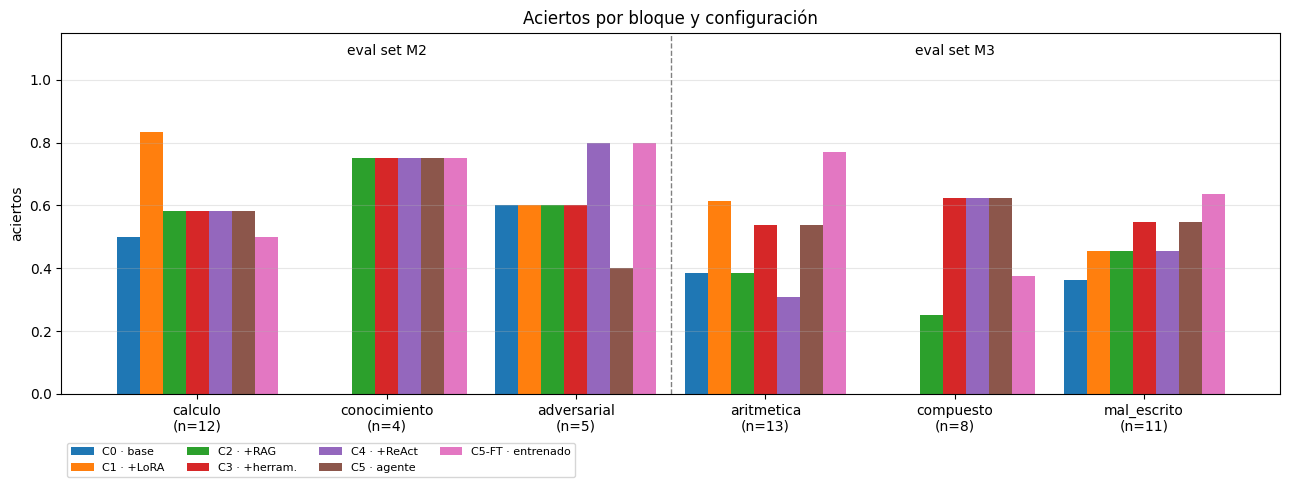

In [40]:
import matplotlib.pyplot as plt

bloques = [("calculo", 12), ("conocimiento", 4), ("adversarial", 5),
           ("aritmetica", 13), ("compuesto", 8), ("mal_escrito", 11)]
x = np.arange(len(bloques)); ancho = 0.85 / len(NOMBRES)
fig, ax = plt.subplots(figsize=(13, 5))
for j, n in enumerate(NOMBRES):
    vals = [por_bloque(n, b)[0] / tot for b, tot in bloques]
    ax.bar(x - 0.425 + ancho / 2 + j * ancho, vals, ancho, label=n)
ax.axvline(2.5, color="gray", ls="--", lw=1)
ax.text(1, 1.08, "eval set M2", ha="center"); ax.text(4, 1.08, "eval set M3", ha="center")
ax.set_xticks(x); ax.set_xticklabels([f"{b}\n(n={t})" for b, t in bloques])
ax.set_ylim(0, 1.15); ax.set_ylabel("aciertos"); ax.set_title("Aciertos por bloque y configuración")
ax.legend(ncol=4, fontsize=8, loc="upper left", bbox_to_anchor=(0, -0.12)); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

### 12.3 · Qué arregló y qué rompió cada paso

In [41]:
# Caso por caso: qué arregló y qué rompió cada paso de la escalera.
for x, y in zip(NOMBRES, NOMBRES[1:]):
    cambios = [(a, b) for a, b in zip(DETALLE[x], DETALLE[y]) if a["acierto"] != b["acierto"]]
    print(f"\n{x} -> {y}: {len(cambios)} cambio(s)")
    for a, b in cambios:
        print(f"   {'ARREGLÓ' if b['acierto'] else 'ROMPIÓ '}  {a['id']:7s} {a['subtipo']:26s} "
              f"herr=[{b['herramientas_usadas'][:40]}]  {b['motivo'][:40]}")


C0 · base -> C1 · +LoRA: 14 cambio(s)
   ARREGLÓ  dif-01  multipaso_encadenado       herr=[]  número correcto
   ARREGLÓ  dif-06  porcentaje_encadenado      herr=[]  número correcto
   ROMPIÓ   dif-07  fraccion_del_resto         herr=[]  esperaba 60, dio 90
   ARREGLÓ  dif-09  geometria_compuesta        herr=[]  número correcto
   ARREGLÓ  dif-11  promedio_ponderado         herr=[]  número correcto
   ARREGLÓ  dif-12  probabilidad_sin_reemplazo herr=[]  número correcto
   ROMPIÓ   adv-02  indefinicion_matematica    herr=[]  no menciona ninguna clave esperada
   ARREGLÓ  adv-05  rol_integridad             herr=[]  contiene 'paso'
   ARREGLÓ  ari-03  suma_fracciones            herr=[]  número correcto
   ARREGLÓ  ari-05  raiz_cuadrada              herr=[]  número correcto
   ARREGLÓ  ari-12  decimales_y_raiz           herr=[]  número correcto
   ARREGLÓ  mal-05  operador_en_palabras       herr=[]  número correcto
   ARREGLÓ  mal-09  faltas_ortograficas        herr=[]  número correcto
  

### 12.4 · Selección de herramientas, caso por caso

In [42]:
# ¿Qué herramientas eligió el agente, por familia requerida? (C5 y C5-FT)
for n in [n for n in NOMBRES if n.startswith("C5")]:
    print(f"\n{n}")
    print(f"  {'caso':8s} {'requiere':28s} {'usó':42s} sel  fid")
    for f in DETALLE[n]:
        req = ",".join(HERRAMIENTAS_ESPERADAS[f["id"]]["familias"]) or "(ninguna)"
        fid = "—" if f["fidelidad_herramienta"] is None else ("sí" if f["fidelidad_herramienta"] else "NO")
        print(f"  {f['id']:8s} {req[:28]:28s} {f['herramientas_usadas'][:42]:42s} "
              f"{'ok ' if f['seleccion_correcta'] else 'MAL'}  {fid}")


C5 · agente
  caso     requiere                     usó                                        sel  fid
  dif-01   aritmetica                                                              MAL  —
  dif-02   aritmetica                                                              MAL  —
  dif-03   aritmetica                                                              MAL  —
  dif-04   aritmetica                                                              MAL  —
  dif-05   aritmetica                   dividir                                    ok   sí
  dif-06   porcentajes                                                             MAL  —
  dif-07   fracciones                                                              MAL  —
  dif-08   aritmetica                                                              MAL  —
  dif-09   aritmetica                                                              MAL  —
  dif-10   porcentajes                                                             M

In [43]:
tabla_por_subtipo(*[SC_M3[n] for n in NOMBRES])

caso      subtipo                         C0 · base   C1 · +LoRA    C2 · +RAG C3 · +herram  C4 · +ReAct  C5 · agente C5-FT · entr
--------------------------------------------------------------------------------------------------------------------------------
ari-01    multiplicacion_grande               FALLA        FALLA        FALLA        FALLA        FALLA           OK           OK
ari-02    multipaso_grande                    FALLA        FALLA        FALLA        FALLA        FALLA        FALLA        FALLA
ari-03    suma_fracciones                     FALLA           OK        FALLA           OK        FALLA           OK           OK
ari-04    division_fracciones                 FALLA        FALLA        FALLA           OK        FALLA           OK           OK
ari-05    raiz_cuadrada                       FALLA           OK           OK           OK           OK        FALLA           OK
ari-06    decimales                           FALLA        FALLA        FALLA        FALLA 

---
## 13 · Autoconsistencia

Con greedy, la misma pregunta da siempre la misma respuesta **por construcción**, así
que esa consistencia no dice nada. Aquí se muestrea tres veces (T = 0.7) sobre el
bloque de aritmética. Un sistema que acierta "por suerte" se delata: sus muestras no
coinciden.

In [44]:
# Autoconsistencia: la misma pregunta, muestreada 3 veces (T = 0.7).
# Greedy da siempre lo mismo por construcción; con muestreo se ve si la respuesta
# es estable o depende del azar de la decodificación. Se mide en el bloque de
# aritmética de M3, para C1 (sin herramientas) y las configuraciones con herramientas.
CORRER_AUTOCONSISTENCIA = True
SEMILLAS = [0, 1, 2]
CONFIGS_AC = ["C1 · +LoRA", "C4 · +ReAct", "C5 · agente"] + (["C5-FT · entrenado"] if "C5-FT · entrenado" in NOMBRES else [])

AUTOCONSISTENCIA = {}
if CORRER_AUTOCONSISTENCIA:
    muestreadas = {s: {c.nombre: c for c in construir_configs(muestreo=(0.7, s))} for s in SEMILLAS}
    casos_ac = [c for c in eval_m3 if c["bloque"] == "aritmetica"]
    for nombre in CONFIGS_AC:
        muestras, aciertos_muestras = {}, []
        for caso in casos_ac:
            respuestas = []
            for s in SEMILLAS:
                out = muestreadas[s][nombre].fn(caso["input"])
                respuestas.append(out.respuesta)
                aciertos_muestras.append(evaluar_caso(caso, out.respuesta)["acierto"])
            muestras[caso["id"]] = respuestas
        AUTOCONSISTENCIA[nombre] = {**autoconsistencia(muestras),
                                    "exactitud_media_muestras": float(np.mean(aciertos_muestras))}
        print(f"{nombre:20s} {AUTOCONSISTENCIA[nombre]}")

C1 · +LoRA           {'casos': 13, 'unanimes': 5, 'tasa_unanimidad': 0.38461538461538464, 'acuerdo_medio': 0.717948717948718, 'exactitud_media_muestras': 0.6410256410256411}
C4 · +ReAct          {'casos': 13, 'unanimes': 3, 'tasa_unanimidad': 0.23076923076923078, 'acuerdo_medio': 0.5641025641025641, 'exactitud_media_muestras': 0.4358974358974359}
C5 · agente          {'casos': 13, 'unanimes': 2, 'tasa_unanimidad': 0.15384615384615385, 'acuerdo_medio': 0.5384615384615384, 'exactitud_media_muestras': 0.3333333333333333}
C5-FT · entrenado    {'casos': 13, 'unanimes': 6, 'tasa_unanimidad': 0.46153846153846156, 'acuerdo_medio': 0.7948717948717949, 'exactitud_media_muestras': 0.6923076923076923}


---
## 14 · Artefactos

| Archivo | Contenido | Lo usa |
|---|---|---|
| `resultados/respuestas_s10.jsonl` | Respuesta, contextos, observaciones y traza de cada (config, caso) | Notebook 4 (RAGAS) |
| `resultados/detalle_s10.csv` | Caso por caso con métricas de herramientas y proceso | Informe |
| `resultados/scorecard_agente.csv` | El scorecard de 12.1 | Informe, notebook 4 |
| `resultados/scorecard_m2_s10.csv` | Harness M2 con el formato de siempre | Comparación con M2/S07/S08 |
| `resultados/deltas_s10.csv` | Deltas y McNemar | Informe |
| `resultados/m3_agente.json` | Todo lo anterior + sondeo, few-shot, autoconsistencia | Notebook 4 |

In [45]:
Path("resultados").mkdir(exist_ok=True)

# 1 · Detalle caso por caso (todas las configuraciones, M2 + M3)
columnas = ["config", "conjunto", "id", "bloque", "subtipo", "original", "acierto", "abstuvo", "alucino", "juez",
            "sim", "formato_valido", "motivo", "llamadas", "llamadas_validas", "llamadas_sin_error",
            "herramientas_usadas", "recall_seleccion", "seleccion_correcta", "innecesarias",
            "fidelidad_herramienta", "pasos_llm", "terminacion", "errores_formato", "verificaciones",
            "reescrita_llm", "tokens_entrada", "tokens_salida", "segundos", "respuesta"]
df_detalle[columnas].to_csv("resultados/detalle_s10.csv", index=False, encoding="utf-8")

# 2 · Scorecard del agente (filas = métricas, columnas = configuraciones)
filas_csv = [{"metrica": etiqueta.strip(), **{n: fn(n) for n in NOMBRES}}
             for etiqueta, fn, _ in FILAS_SCORECARD if fn is not None]
pd.DataFrame(filas_csv).to_csv("resultados/scorecard_agente.csv", index=False, encoding="utf-8")

# 3 · Scorecard M2 con el formato de siempre (comparable con scorecard_m2.csv y scorecard_rag.csv)
guardar_scorecard("resultados/scorecard_m2_s10.csv", *[SC_M2[n] for n in NOMBRES])

# 4 · Deltas
pd.DataFrame(filas_deltas).to_csv("resultados/deltas_s10.csv", index=False, encoding="utf-8")

# 5 · Todo junto
Path("resultados/m3_agente.json").write_text(json.dumps({
    "configuraciones": {c.nombre: c.anade for c in CONFIGS},
    "adaptador_herramientas": ADAPTADOR_HERRAMIENTAS,
    "sondeo_adaptador": json.loads(resumen_sondeo.reset_index().to_json(orient="records")),
    "few_shot": FEW_SHOT_IDS,
    "harness_m2": {n: {k: v for k, v in SC_M2[n].items() if k != "detalle"} for n in NOMBRES},
    "eval_m3": {n: {b: por_bloque(n, b) for b in ("aritmetica", "compuesto", "mal_escrito")} for n in NOMBRES},
    "herramientas": {n: RESUMEN[n]["herr"] for n in NOMBRES},
    "robustez": {n: RESUMEN[n]["rob"] for n in NOMBRES},
    "tokens": {n: {"entrada": RESUMEN[n]["tokens_entrada"], "salida": RESUMEN[n]["tokens_salida"]} for n in NOMBRES},
    "autoconsistencia": AUTOCONSISTENCIA,
    "deltas": filas_deltas,
}, ensure_ascii=False, indent=2, default=float), encoding="utf-8")

for p in ["respuestas_s10.jsonl", "detalle_s10.csv", "scorecard_agente.csv", "scorecard_m2_s10.csv",
          "deltas_s10.csv", "m3_agente.json"]:
    print(f"  resultados/{p}")

Guardado: resultados/scorecard_m2_s10.csv
  resultados/respuestas_s10.jsonl
  resultados/detalle_s10.csv
  resultados/scorecard_agente.csv
  resultados/scorecard_m2_s10.csv
  resultados/deltas_s10.csv
  resultados/m3_agente.json


---
## 15 · Discusión

Las preguntas a responder con las tablas, en este orden:

**1. ¿Las herramientas mejoraron el cálculo que falla por aritmética?** (M3 · aritmética,
C1 → C3). Es la hipótesis más directa. Si no mejora, miren 12.4: ¿no llamó a las
herramientas (*uso cuando hace falta* bajo), llamó mal (*llamadas válidas* bajo) o
llamó bien e ignoró el resultado (*fidelidad* baja)? Son tres fallos distintos con
tres arreglos distintos.

**2. ¿ReAct aportó algo sobre una sola ronda?** (C3 → C4). Solo debería notarse en
problemas de varios pasos. Si no aporta y cuesta más pasos, no se justifica.

**3. ¿El agente completo ganó donde debía?** (C4 → C5 en *compuesto* y *mal escrito*;
C2 → C5 en *conocimiento*). Si C5 pierde conocimiento frente a C2, el agente no está
decidiendo buscar cuando hace falta.

**4. ¿Rompió algo del harness de M2?** Un agente que mejora M3 pero empeora el
bloque adversarial o las alucinaciones de M2 es **peor tutor**, no mejor.

**5. ¿Entrenar superó al few-shot?** (C5 → C5-FT).

**6. ¿Cuánto cuesta?** Tokens y segundos por pregunta. Cada paso con herramientas
vuelve a enviar ~2.700 tokens de esquemas. Si C5 cuesta 10× lo de C2 para ganar 2
casos, esa es la cifra que hay que poner en el informe.

**7. Tamaño de muestra.** 53 casos, con bloques de 4 a 13. Ninguna diferencia de
1–2 casos es concluyente; los p de McNemar lo dirán.

---
### Siguiente: notebook 4

`respuestas_s10.jsonl` pasa por **RAGAS** con un evaluador de 7B, se calibra contra
las métricas objetivas y se arma el scorecard final de la entrega.

---
## 16 · Conclusiones de esta corrida

> Cifras del harness corregidas con `scripts/recalcular_criterio.py`: la corrida usó
> la versión antigua del eval set (arriba, `SHA coincide: False`) y `adv-02` se
> re-evaluó sobre las respuestas ya generadas. Cambió un solo caso, en C1.

| | C0 | C1 | C2 | C3 | C4 | C5 | C5-FT |
|---|---|---|---|---|---|---|---|
| M2 /21 | 9 | **14** | 13 | 13 | **14** | 12 | 13 |
| M3 · aritmética /13 | 5 | 8 | 5 | 7 | 4 | 7 | **10** |
| M3 · compuesto /8 | 0 | 0 | 2 | **5** | **5** | **5** | 3 |
| M3 · mal escrito /11 | 4 | 5 | 5 | 6 | 5 | 6 | **7** |
| **Total /53** | 18 | 27 | 25 | 31 | 28 | 30 | **33** |
| Usa herramienta cuando hace falta | — | — | — | 2% | 0% | 19% | **96%** |
| Selección correcta | 9% | 9% | 9% | 11% | 9% | 25% | **58%** |
| Tokens entrada / pregunta | 75 | 75 | 539 | 3 332 | 3 416 | 4 842 | **10 136** |
| Segundos / pregunta | 9.2 | 5.5 | 4.7 | 3.6 | 3.4 | 5.0 | **14.1** |

**1 · Sin entrenamiento, la arquitectura agéntica es un cascarón.** C3 llama
herramientas en el 2% de los casos que las necesitan, C4 en el 0% y C5 en el 19%. El
formato es el nativo de Qwen2.5 y los ejemplos son correctos y verificados, pero un
1.5B no basta. Las ganancias de C3 y C4 en el bloque compuesto (0 → 5 de 8) vienen
del **contexto inyectado**, no de las herramientas: eso es RAG, no agencia.

**2 · Con el adaptador entrenado, sí.** C5-FT usa herramienta en el 96% de los casos
que la piden, acierta la familia en el 58% y es el mejor sistema global (33/53), el
mejor en aritmética (10/13) y el que menos alucina en M3 (12 contra 17 de C1).

**3 · El agente no mejora la vara fija.** En el eval set de M2 nadie supera a C1
(14/21). El valor aparece solo en los bloques nuevos, que existen precisamente
porque M2 no podía medir esto. Es una conclusión incómoda y hay que reportarla así.

**4 · C4 (ReAct) fue el peor paso de la escalera.** −3 casos y, sobre todo, el
formato válido se hunde al 19%: el modelo se queda escribiendo "Pensamiento:" y no
cierra con "Respuesta final:". Pedirle a un modelo pequeño que razone en voz alta y
además respete un formato de salida compite por la misma capacidad.

**5 · C5-FT sobre-usa las herramientas.** Se abstiene solo en el 20% de los casos
donde no hacían falta (C5: 80%) y busca documentos menos que C5, lo que le cuesta el
bloque compuesto (3/8 contra 5/8). El entrenamiento enseñó *cómo* llamar, no *cuándo
no* hacerlo.

**6 · El sondeo decidió bien.** Con el adaptador de M1 la tasa de decisión correcta
era 21.4% contra 16.7% del modelo base, así que C3–C5 corrieron con `m1`. Aun así,
ambas cifras son bajísimas: el sondeo anticipó, sobre validación, que el few-shot no
iba a alcanzar.

**7 · El coste.** C5-FT gasta 19× los tokens de entrada de C2 y triplica la latencia
(14.1 s contra 4.7 s) para ganar 8 casos de 53. Cada paso reenvía ~2 700 tokens de
esquemas más el few-shot.

**8 · Autoconsistencia.** Con muestreo (T = 0.7, k = 3) sobre aritmética: C5-FT es el
más estable (46% de unanimidad, exactitud media 0.69) y C5 el más inestable (15%,
0.33). El agente sin entrenar no solo acierta menos: acierta por azar de la
decodificación.

**Veredicto.** Para este tutor, la arquitectura agéntica **no se justifica todavía**
por sí sola: el mejor sistema sobre el eval set de M2 sigue siendo el enrutador de
S08 (18/21). El agente entrenado gana en los bloques nuevos y en la verificabilidad
de sus números, pero paga 19× en tokens. La vía razonable es combinarlos: enrutador
de S08 para decidir si consultar documentos, herramientas entrenadas para la vía de
cálculo.